In [1]:
# ------------- 标准库 -------------
import os
import glob
import re
import json
from datetime import datetime
from pathlib import Path
import itertools
# ------------- 数据分析核心库 -------------
import pandas as pd
import numpy as np
# ------------- 科学计算/统计分析库 -------------
from scipy.optimize import minimize
from scipy.stats import ttest_1samp, binomtest, ttest_ind
import statsmodels.api as sm
# ------------- 可视化库 -------------
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

In [2]:
# 设置程序中文字体
def _set_mpl_chinese_font(force_rebuild_cache=False):

    # 清理 matplotlib 字体缓存
    if force_rebuild_cache:
        cache_dir = matplotlib.get_cachedir()
        for fp in glob.glob(os.path.join(cache_dir, "fontlist-v*.json")):
            try:
                os.remove(fp)
            except Exception:
                pass

    # 先从已注册字体里找
    preferred_names = ["Microsoft YaHei", "SimSun"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in preferred_names:
        if name in available:
            chosen_font_name = name
            break


    # 如果已注册字体中找不到，从Windows本地路径找
    if not chosen_font_name:
        win_font_candidates = [
            r"C:\Users\Galax\AppData\Local\Microsoft\Windows\Fonts\方正小标宋简.TTF"
            r"C:\Users\Galax\AppData\Local\Microsoft\Windows\Fonts\大标宋简.ttf",
        ]

        chosen_font_name = ""

        # 3) 如果文件存在，就 addfont，让 matplotlib 一定“认识它”
        for fpath in win_font_candidates:
            if os.path.exists(fpath):
                try:
                    fm.fontManager.addfont(fpath)
                    # 取字体名（关键：rcParams 用字体名，不是文件名）
                    prop = fm.FontProperties(fname=fpath)
                    chosen_font_name = prop.get_name()
                    break
                except Exception:
                    continue

    # 5) 强制设置 matplotlib 使用中文字体
    if chosen_font_name:
        plt.rcParams["font.sans-serif"] = [chosen_font_name]
        plt.rcParams["font.family"] = "sans-serif"
    else:
        print("⚠️ 未找到可用中文字体。请安装：微软雅黑/黑体/思源黑体(Noto Sans CJK)。")

    # 6) 负号正常显示
    plt.rcParams["axes.unicode_minus"] = False

    return chosen_font_name

font_used = _set_mpl_chinese_font(force_rebuild_cache=True)
print(font_used)

Microsoft YaHei


In [3]:
np.random.seed(42)  # 保证置换检验结果可复现

# 可选：设置整体画图的风格和清晰度
plt.rcParams['figure.dpi'] = 120  # 提高 Jupyter 中出图的清晰度

# 2. 一次性加载全量数据到内存
print("正在加载数据到内存，请稍候...")
macro_df_all = pd.read_csv("macro_df_v1.csv", parse_dates=["release_date"])
asset_df_all = pd.read_excel("ALL_ASSETS.xlsx")
n=12 #一年内 观察horizon的最长期限

# 生成时间戳及对应的文件夹名称
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
res_dir = f"Results_{timestamp}"
final_res_dir = f"Final_Results_{timestamp}"

os.makedirs(final_res_dir, exist_ok=True)

# 定义文件路径变量，避免后续代码硬编码
events_tmp = f"{final_res_dir}/Events_Temp.xlsx"
trades_oos_tmp = f"{final_res_dir}/Trades_Temp.xlsx"
trades_ins_tmp = f"{final_res_dir}/Trades_INS_Temp.xlsx"

# 确保日期格式正确
if not pd.api.types.is_datetime64_any_dtype(asset_df_all["Trddt"]):
    asset_df_all["Trddt"] = pd.to_datetime(asset_df_all["Trddt"], errors="raise")

# 获取要循环的所有宏观指标和资产列表
macro_cols = macro_df_all["factor_name"].dropna().unique().tolist()
asset_cols = asset_df_all["Indexcd"].dropna().astype(str).unique().tolist()
print(f"数据加载完成！共有 {len(macro_cols)} 个宏观指标，{len(asset_cols)} 个大类资产待回测。")

正在加载数据到内存，请稍候...
数据加载完成！共有 11 个宏观指标，6 个大类资产待回测。


In [4]:
# =========================
# 分样本设置（按 trade_date）
# =========================
INS_START = pd.Timestamp("2007-01-01")
INS_END   = pd.Timestamp("2022-12-31")

OOS_START = pd.Timestamp("2023-01-01")
OOS_END   = pd.Timestamp("2026-01-31")

# horizons 里最大持有期（用于计算 future_* / 以及卖点日期生成）
MAX_H = 36

# 卖点对齐规则：backfill（>= target 的下一交易日）
SELL_ALIGN_METHOD = "backfill"

In [5]:
# =========================
# 工具函数：统一交易日历 & 对齐规则
# =========================
def get_trading_index_from_asset_df(asset_df: pd.DataFrame) -> pd.DatetimeIndex:
    """
    从 asset_df 得到交易日历 DatetimeIndex（升序去重）
    适配口径：DatetimeIndex / Trddt / trade_date
    """
    if isinstance(asset_df.index, pd.DatetimeIndex):
        idx = asset_df.index
    elif "Trddt" in asset_df.columns:
        idx = pd.to_datetime(asset_df["Trddt"])
    elif "trade_date" in asset_df.columns:
        idx = pd.to_datetime(asset_df["trade_date"])
    else:
        raise ValueError("asset_df 无法识别交易日字段（需要 DatetimeIndex / Trddt / trade_date 之一）")
    idx = pd.DatetimeIndex(idx).dropna().unique().sort_values()
    return idx

def align_release_to_trade_date(release_dates: pd.Series, trading_index: pd.DatetimeIndex) -> pd.Series:
    """
    release_date -> trade_date：
    - 先 release + 1 day
    - 再 backfill 到 >= target 的下一交易日
    """
    target = (pd.to_datetime(release_dates) + pd.Timedelta(days=1)).values.astype("datetime64[ns]")
    td = trading_index.values.astype("datetime64[ns]")
    pos = np.searchsorted(td, target, side="left")  # backfill
    out = pd.Series(pd.NaT, index=release_dates.index)
    valid = pos < len(td)
    out.loc[valid] = pd.to_datetime(td[pos[valid]])
    return out

def align_sell_backfill(target_dates: pd.Series, trading_index: pd.DatetimeIndex) -> pd.Series:
    """
    卖点目标日（buy + h months） -> 卖点 trade_date：backfill 到 >= target 的交易日
    """
    td = trading_index.values.astype("datetime64[ns]")
    target = pd.to_datetime(target_dates).values.astype("datetime64[ns]")
    pos = np.searchsorted(td, target, side="left")  # backfill
    out = pd.Series(pd.NaT, index=target_dates.index)
    valid = pos < len(td)
    out.loc[valid] = pd.to_datetime(td[pos[valid]])
    return out

def build_tests_all(referred: pd.DataFrame, target_col: str):
    """
    ✅ 单一入口：保证 INS / OOS 生成 trades 时 label 文案完全一致
    """
    tests = []
    tests += build_tests_zero_cross(referred["value"], target_col, eps=0.0)
    tests += build_tests_continuous(referred, "value", target_col)
    tests += build_tests_continuous_neg(referred, "value", target_col)
    tests += build_tests_local_turning_points(referred["value"], target_col)
    tests += build_tests_long_turning_points(referred["value"], target_col)
    tests += build_tests_record_high_low(referred["value"], target_col)
    tests += build_tests_ma_cross(referred["value"], target_col)
    return tests

def generate_trades_from_param(referred: pd.DataFrame, best_param: dict, trading_index: pd.DatetimeIndex, tag: str):
    """
    用同一套规则生成 trades（INS/OOS 都用它），输出列名严格对齐原 df_trades_all
    """
    if referred is None or referred.empty or (best_param is None) or (len(best_param) == 0):
        return pd.DataFrame()

    cond = best_param.get("事件名称", None)
    direction = best_param.get("方向", None)  # "long" / "short"
    h = int(best_param.get("持有月数", 0) or 0)

    if (cond is None) or (direction not in ["long", "short"]) or (h <= 0):
        return pd.DataFrame()

    tests_list = build_tests_all(referred, best_param.get("宏观因子", ""))
    label_to_mask = {lab: m for m, lab in tests_list}
    mask = label_to_mask.get(cond, None)
    if mask is None:
        return pd.DataFrame()

    buy_dates = pd.to_datetime(referred.loc[mask, "trade_date"], errors="coerce").dropna()
    if buy_dates.empty:
        return pd.DataFrame()

    sell_target = buy_dates + pd.DateOffset(months=h)
    sell_dates = align_sell_backfill(pd.Series(sell_target.values, index=buy_dates.index), trading_index)
    sell_dates = pd.to_datetime(sell_dates, errors="coerce")

    # short 复刻：买卖翻转
    if direction == "long":
        t_buy, t_sell = buy_dates, sell_dates
    else:
        t_buy, t_sell = sell_dates, buy_dates

    n_events = best_param.get("样本数", np.nan)
    win_rate = best_param.get("胜率", np.nan)
    p_value = best_param.get("P值", np.nan)

    trades_buy = pd.DataFrame({
        "日期": pd.to_datetime(t_buy, errors="coerce").dt.date,
        "买卖": "BUY",
        "事件名称": cond,
        "样本数": n_events,
        "胜率": win_rate,
        "P值": p_value,
        "被解释资产": best_param.get("被解释资产", None),
        "持有月数": h,
        "样本段": tag,
    })
    trades_sell = pd.DataFrame({
        "日期": pd.to_datetime(t_sell, errors="coerce").dt.date,
        "买卖": "SELL",
        "事件名称": cond,
        "样本数": n_events,
        "胜率": win_rate,
        "P值": p_value,
        "被解释资产": best_param.get("被解释资产", None),
        "持有月数": h,
        "样本段": tag,
    })

    df_trades = pd.concat([trades_buy, trades_sell], ignore_index=True)
    df_trades = df_trades.dropna(subset=["日期"]).sort_values(["日期","买卖"]).reset_index(drop=True)
    return df_trades

def _safe_filename(s: str) -> str:
    return str(s).replace("/", "_").replace("\\", "_").replace(":", "_").replace("*", "_").replace("?", "_").replace('"', "_").replace("<", "_").replace(">", "_").replace("|", "_")


def save_backtest_figure(plot_df: pd.DataFrame,
                         buy_df: pd.DataFrame,
                         sell_df: pd.DataFrame,
                         explained_asset: str,
                         cond: str,
                         h_best: int,
                         out_dir=None,
                         fig_prefix=""):
    """
    plot_df: index=交易日, 含 Clsidx
    buy_df : 至少含 trade_date, trade_price
    sell_df: 至少含 Date, Price
    """
    import matplotlib.pyplot as plt
    from pathlib import Path

    if plot_df is None or plot_df.empty:
        return None

    plt.figure(figsize=(15, 6))
    plt.plot(plot_df.index, plot_df["Clsidx"], alpha=0.5, label=f"{explained_asset} 净值")

    if buy_df is not None and (not buy_df.empty):
        plt.scatter(buy_df["trade_date"], buy_df["trade_price"], label="买点", s=20, zorder=5, c="red")
    if sell_df is not None and (not sell_df.empty):
        plt.scatter(sell_df["Date"], sell_df["Price"], label="卖点", s=20, zorder=5, c="green")

    plt.title(f"策略回测：{cond}（持有 {h_best} 个月）")
    plt.legend()

    saved_fig_path = None
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

        safe_name = _safe_filename(cond)
        saved_fig_path = out_dir / f"{fig_prefix}{safe_name}.png"
        plt.savefig(saved_fig_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()
    return saved_fig_path

# 模型输入
输入数据应为日频，模型采用对数收益率；月末调仓，从月末的后一个交易日开始计算收益率；

考虑到各资产存在可交易日期不同的情况，部分资产缺少收益率的日期中，将收益率中的NA填为0。

## 信号检验法 前置流程

In [6]:
# 把未来收益从 1 个周期扩大到未来 n 个周期，并额外算 [12,18,24,30,36]
# 你给的函数是 rolling(horizon).sum().shift(-horizon+1)
# =========================
def calc_future_return(ret, horizon):
    # 对“未来 horizon 期”的累积收益：用 rolling(horizon).sum() 先得到长度为 horizon 的窗口和
    # 再 shift(-horizon+1) 把该窗口和对齐到“买入时点”
    return ret.rolling(horizon).sum().shift(-horizon + 1)

In [7]:
def _pl_ratio(x: pd.Series):
    """盈亏比 = 平均盈利 / 平均亏损的绝对值（若无盈利或无亏损则 NaN）"""
    x = x.dropna()
    pos = x[x > 0]
    neg = x[x < 0]
    if len(pos) == 0 or len(neg) == 0:
        return np.nan, np.nan, np.nan
    avg_gain = pos.mean()
    avg_loss = abs(neg.mean())
    ratio = avg_gain / avg_loss if avg_loss > 0 else np.nan
    return float(avg_gain), float(avg_loss), float(ratio)

def test_under_condition_multi_horizon(
    df_tested,
    condition,
    label,
    col_name,
    horizons=None,
    p0=0.5,
    side1="long",   # 新增：'long' 或 'short'（short 会对收益取负）
):
    """
    事件检验（多期限），支持做空策略评估：
    - side1='long' ：使用 x
    - side1='short'：使用 -x 作为“策略收益”进行胜率/赔率/显著性等计算

    注意：为保持字段名不变，*_ls_* 字段不再计算，统一返回 NaN。
    """
    if horizons is None:
        local_n = n if 'n' in globals() else 12
        horizons = sorted(list(set(list(range(1, local_n + 1)) + [12, 18, 24, 30, 36])))

    side1 = str(side1).lower()
    if side1 not in ("long", "short"):
        raise ValueError("side must be 'long' or 'short'")

    # signal 组：满足 condition 的样本（你希望 short 时就是这组做空）
    sub_sig_all = df_tested.loc[condition].copy()
    count = len(sub_sig_all)

    result = {"条件": label, "样本数": count, "side": side1}

    # 没有 signal 样本
    if count == 0:
        # 当前周期
        result.update({
            f"{col_name}_mean": np.nan,
            f"{col_name}_t_p": np.nan,
            f"{col_name}_win_rate": np.nan,
            f"{col_name}_pos_p": np.nan,
            f"{col_name}_avg_gain": np.nan,
            f"{col_name}_avg_loss": np.nan,
            f"{col_name}_pl_ratio": np.nan,
            f"{col_name}_ls_mean_long": np.nan,
            f"{col_name}_ls_mean_short": np.nan,
            f"{col_name}_ls_diff": np.nan,
            f"{col_name}_ls_p": np.nan,
        })
        for h in horizons:
            f_col = f"future_{h}m_{col_name}"
            result.update({
                f"{f_col}_mean": np.nan,
                f"{f_col}_t_p": np.nan,
                f"{f_col}_win_rate": np.nan,
                f"{f_col}_pos_p": np.nan,
                f"{f_col}_avg_gain": np.nan,
                f"{f_col}_avg_loss": np.nan,
                f"{f_col}_pl_ratio": np.nan,
                f"{f_col}_ls_mean_long": np.nan,
                f"{f_col}_ls_mean_short": np.nan,
                f"{f_col}_ls_diff": np.nan,
                f"{f_col}_ls_p": np.nan,
            })
        return result

    # ========== 当前周期（col_name） ==========
    x_raw = sub_sig_all[col_name]
    x = (-x_raw) if side1 == "short" else x_raw  # 做空策略收益

    rt_pos = int((x > 0).sum())
    avg_gain, avg_loss, plr = _pl_ratio(x)

    result.update({
        f"{col_name}_mean": x.mean(),  # 注意：这里已经是“策略收益”的均值（short 为 -x_raw 的均值）
        f"{col_name}_t_p": ttest_1samp(x.dropna(), 0).pvalue if x.dropna().shape[0] >= 2 else np.nan,
        f"{col_name}_pos": rt_pos,
        f"{col_name}_win_rate": rt_pos / count,
        f"{col_name}_pos_p": winrate_p_value_one_sided(rt_pos, count, p0=p0),
        f"{col_name}_avg_gain": avg_gain,
        f"{col_name}_avg_loss": avg_loss,
        f"{col_name}_pl_ratio": plr,
        f"{col_name}_ls_mean_long": np.nan,
        f"{col_name}_ls_mean_short": np.nan,
        f"{col_name}_ls_diff": np.nan,
        f"{col_name}_ls_p": np.nan,
    })

    # ========== 不同期限 future ==========
    for h in horizons:
        f_col = f"future_{h}m_{col_name}"
        if f_col not in df_tested.columns:
            continue

        sub_sig = sub_sig_all.dropna(subset=[f_col])
        n_h = len(sub_sig)
        result[f"{h}m_n"] = n_h

        if n_h == 0:
            result.update({
                f"{f_col}_mean": np.nan,
                f"{f_col}_t_p": np.nan,
                f"{f_col}_win_rate": np.nan,
                f"{f_col}_pos_p": np.nan,
                f"{f_col}_avg_gain": np.nan,
                f"{f_col}_avg_loss": np.nan,
                f"{f_col}_pl_ratio": np.nan,
                f"{f_col}_ls_mean_long": np.nan,
                f"{f_col}_ls_mean_short": np.nan,
                f"{f_col}_ls_diff": np.nan,
                f"{f_col}_ls_p": np.nan,
            })
            continue

        xL_raw = sub_sig[f_col]
        xL = (-xL_raw) if side1 == "short" else xL_raw  # 做空策略收益

        f_pos = int((xL > 0).sum())
        avg_gain, avg_loss, plr = _pl_ratio(xL)
        # =======================================================
        # ✅【核心新增】：500次随机置换检验 (极致矩阵化加速版)
        # =======================================================
        pool_raw = df_tested[f_col].dropna()
        pool = (-pool_raw) if side1 == "short" else pool_raw 
        
        # 优化：利用 argsort 在矩阵层面一次性完成 500 次无放回抽样
        M = len(pool)
        if M > 0 and n_h > 0:
            random_idx = np.argsort(np.random.rand(500, M), axis=1)[:, :n_h]
            random_means = pool.values[random_idx].mean(axis=1)
            random_p = np.mean(random_means >= xL.mean()) 
        else:
            random_p = np.nan
        # =======================================================

        result.update({
            f"{f_col}_mean": xL.mean(),
            f"{f_col}_t_p": ttest_1samp(xL.dropna(), 0).pvalue if xL.dropna().shape[0] >= 2 else np.nan,
            f"{f_col}_pos": f_pos,
            f"{f_col}_win_rate": f_pos / n_h,
            f"{f_col}_pos_p": winrate_p_value_one_sided(f_pos, n_h, p0=p0),
            f"{f_col}_random_p": random_p, # ✅ 把这个超级P值存进结果里
            f"{f_col}_avg_gain": avg_gain,
            f"{f_col}_avg_loss": avg_loss,
            f"{f_col}_pl_ratio": plr,
            # ✅ 删除 long-short 功能，但不改字段名：统一 NaN
            f"{f_col}_ls_mean_long": np.nan,
            f"{f_col}_ls_mean_short": np.nan,
            f"{f_col}_ls_diff": np.nan,
            f"{f_col}_ls_p": np.nan,
        })

    return result

# 信号事件生成器

In [8]:
# -----------------------------
# 统一：事件生成器（输出 tests）
# -----------------------------
def build_tests_zero_cross(series: pd.Series, target_col: str, eps: float = 0.0):
    """
    信号检验法1：零轴穿越
    输入：series（宏观指标值序列），target_col（用于label），eps（缓冲区）
    输出：tests = [(mask, label), ...]
    """
    pos_to_neg, neg_to_pos = sign_flip(series, eps=eps)
    tests = [
        (pos_to_neg, f"{target_col}转负"),
        (neg_to_pos, f"{target_col}转正"),
    ]
    return tests

def build_tests_continuous(df: pd.DataFrame, col: str, target_col: str, m_list=range(2, 13)):
    """
    信号检验法2：连续 m 个月为正
    输入：df（事件表 referred），col（宏观值列名），target_col（用于label），m_list（连续窗口列表）
    输出：tests = [(mask, label), ...]
    """
    tests = []
    for m in m_list:
        mask = get_continuous_pos_mask(df, col, m)
        tests.append((mask, f"{target_col}连续{m}个月为正"))
    return tests

def build_tests_continuous_neg(df: pd.DataFrame, col: str, target_col: str, m_list=range(2, 13)):
    """
    信号检验法3：连续 m 个月为负
    输入：df（事件表 referred），col（宏观值列名），target_col（用于label），m_list（连续窗口列表）
    输出：tests = [(mask, label), ...]
    """
    tests = []
    for m in m_list:
        mask = get_continuous_neg_mask(df, col, m)
        tests.append((mask, f"{target_col}连续{m}个月为负"))
    return tests

def build_tests_local_turning_points(series: pd.Series, target_col: str, k=1):
    """
    信号检验法4：局部转折点（事后确认版）
    - 峰值/谷值的信号标记在确认它的下一个时间点
    """
    cond_h13_peak, cond_h13_trough = local_turning_points(series, k=k)

    # 在首个增势转跌/跌势转涨的月份，识别 local turning points并标记
    cond_h13_peak_delayed = (
        cond_h13_peak.shift(1)
        .astype("boolean")
        .fillna(False)
        .astype(bool)
    )
    cond_h13_trough_delayed = (
        cond_h13_trough.shift(1)
        .astype("boolean")
        .fillna(False)
        .astype(bool)
    )

    tests = [
        (cond_h13_peak_delayed, f"{target_col}达到短期峰值"),
        (cond_h13_trough_delayed, f"{target_col}达到短期谷值"),
    ]
    return tests

def build_tests_long_turning_points(series: pd.Series, target_col: str, k_list=(6, 9, 12)):
    """
    信号构建5：长期拐点识别（事后确认版）
    - 拐点发生在 t，但需要看到 t+1 才确认，因此信号打在 t+1（shift(1)）

    输入：
        series：宏观指标序列
        target_col：label 用
        k_list：长期窗口半径（例如 6 表示用 13 期窗口）
    输出：
        tests = [(mask, label), ...]
    """
    tests = []
    for k in k_list:
        peak, trough = long_turning_points(series, k=k)

        # 新增变量：peak_delayed, trough_delayed（确认日信号）
        peak_delayed = peak.shift(1).astype(bool).fillna(False)
        trough_delayed = trough.shift(1).astype(bool).fillna(False)

        tests.append((peak_delayed, f"{target_col}达到长期峰值(k={k})"))
        tests.append((trough_delayed, f"{target_col}达到长期谷值(k={k})"))
    return tests

def build_tests_record_high_low(series: pd.Series, target_col: str, lookback_list=(None, 12, 24, 36)):
    """
    信号构建6：创历史新高/新低
    - lookback=None 表示“历史以来”
    - lookback=12/24/36 表示“近 N 期窗口内”创新高/新低

    输出：tests = [(mask, label), ...]
    """
    tests = []
    for lb in lookback_list:
        new_high, new_low = record_high_low(series, lookback=lb)

        # 新增变量：tag（用于 label）
        tag = "历史以来" if lb is None else f"近{lb}期"
        tests.append((new_high, f"{target_col}{tag}创新高"))
        tests.append((new_low, f"{target_col}{tag}创新低"))
    return tests

def build_tests_ma_cross(series: pd.Series, target_col: str, windows=(5, 10, 20, 30), min_periods=None):
    """
    信号构建7：MA 金叉/死叉（短均线 vs 长均线）
    - 计算 MA(w)
    - 对所有 (short < long) 的组合产生：
        金叉：MA_short 上穿 MA_long
        死叉：MA_short 下穿 MA_long

    输入：
        series：宏观指标序列
        target_col：label 用
        windows：默认 (5,10,20,30)
        min_periods：rolling 的 min_periods；默认等于窗口 w（更严谨）
    输出：
        tests = [(mask, label), ...]
    """
    s = series.astype(float).copy()
    tests = []

    # 新增变量：ma_dict（保存不同窗口 MA）
    ma_dict = {}
    for w in windows:
        mp = w if (min_periods is None) else min_periods
        ma_dict[w] = s.rolling(window=w, min_periods=mp).mean()

    ws = sorted(windows)
    for i in range(len(ws)):
        for j in range(i + 1, len(ws)):
            short_w, long_w = ws[i], ws[j]
            ma_s, ma_l = ma_dict[short_w], ma_dict[long_w]

            gold = _cross_up(ma_s, ma_l)
            dead = _cross_down(ma_s, ma_l)

            tests.append((gold, f"{target_col} MA{short_w}上穿MA{long_w}(金叉)"))
            tests.append((dead, f"{target_col} MA{short_w}下穿MA{long_w}(死叉)"))

    return tests

# 结果整理

In [9]:
# -----------------------------------------
# 统一：从 df_result 中选“最佳策略参数”
# + 增加 K 门槛（最少事件数）
# -----------------------------------------
def select_best_strategies_from_results(
    df_res: pd.DataFrame,
    tests_list,
    col_name: str,
    win_rate_thr: float = 0.6,
    p_thr: float = 0.1,
    min_events: int = 20,
):
    """
    输入：
      - df_res：run_multi_horizon_tests 的输出
      - tests_list：[(mask, label), ...] 用于回溯买点
      - col_name：收益列名（EXPLAINED_RT_COL）
    输出：
      - df_best：满足筛选条件的策略列表（按 综合得分 排序）
    """
    best = []
    win_rate_cols = [c for c in df_res.columns if c.startswith("future_") and c.endswith("_win_rate") and col_name in c]

    # 建立 label->mask 映射，便于后面快速取买点
    label_to_mask = {lab: m for m, lab in tests_list}

    for _, row in df_res.iterrows():
        cond_label = row.get("条件", None)
        if cond_label is None:
            continue

        # 事件数门槛：df_res里的“样本数”是 condition 下的样本数（不是每个 horizon 的 n）
        base_n = row.get("样本数", np.nan)
        if pd.isna(base_n) or int(base_n) < min_events:
            continue

        for wr_col in win_rate_cols:
            p_col = wr_col.replace("win_rate", "pos_p")
            mean_col = wr_col.replace("win_rate", "mean")

            # 解析期限 h：future_{h}m_{col}_win_rate
            h = int(re.findall(r"future_(\d+)m_", wr_col)[0])

            wr = row.get(wr_col, np.nan)
            pv = row.get(p_col, np.nan)
            mu = row.get(mean_col, np.nan)
            rnd_p = row.get(f"future_{h}m_{col_name}_random_p", np.nan)

            if pd.isna(wr) or pd.isna(pv) or pd.isna(mu):
                continue

            if (wr > win_rate_thr) and (pv < p_thr):
                best.append({
                    "条件": cond_label,
                    "持有月数": h,
                    "样本数": int(base_n),
                    "胜率": float(wr),
                    "P值": float(pv),
                    "均值收益": float(mu),
                    "随机检验P值": float(rnd_p) if pd.notna(rnd_p) else np.nan, # ✅ 新增：存入字典
                })

    if not best:
        return pd.DataFrame(columns=["条件", "持有月数", "样本数", "胜率", "P值", "均值收益", "随机检验P值", "综合评分"])

    df_best_temp = pd.DataFrame(best)
    
    # ✅ 1. 处理空值：如果有随机P值算出来是空的，给它一个最差的惩罚(1.0)
    rnd_p_filled = df_best_temp["随机检验P值"].fillna(1.0)
    
    # ✅ 2. 计算你的“专属阿尔法综合评分”
    df_best_temp["综合评分"] = df_best_temp["胜率"] - 60 * rnd_p_filled
    df_best_temp["基础骨架"] = df_best_temp["条件"].apply(lambda x: re.sub(r'\d+', '', str(x)))
    # ✅ 3. 按综合评分排第一优先级，胜率排第二优先级
    df_best = (
        df_best_temp
        .sort_values(["综合评分", "胜率"], ascending=[False, False])
        .groupby("基础骨架").head(1)   # <--- 按脱水后的骨架去重！
        .drop(columns=["基础骨架"])     # <--- 选完之后把这列删掉，保持表格干净
        .reset_index(drop=True)
    )
    return df_best


# ------------------------------------------------
# 统一：给定 df_best 的 top 策略 -> 买卖点 + 绘图
# ------------------------------------------------
def analyze_and_plot_best_v2(
    referred,
    asset_df,
    df_res,
    tests_list,
    explained_asset,
    col_name,
    win_rate_thr=0.6,
    p_thr=0.1,
    min_events=20,
    neg=True,

    out_dir=None,
    fig_prefix="",
    df_events=None,
    df_trades_all=None,
    export_excel=False,
    events_excel_name=None,
    trades_excel_name=None,
):

    """
    输入：
      - referred：事件表（含 trade_date, trade_price, 以及 future_* 列）
      - asset_df：资产日频价格表（含 Trddt, Clsidx）
      - df_res：run_multi_horizon_tests 的结果表
      - tests_list：[(mask, label), ...]
      - explained_asset：资产名（用于画图label）
      - col_name：收益列名（EXPLAINED_RT_COL）
    输出：
      - buy_table, sell_table, df_best
      - （✅新增：如果传入 df_events / df_trades_all，会在函数内追加并返回更新后的表）
    """
    # ========= 你原来的代码（保留） =========
    df_best = select_best_strategies_from_results(
        df_res, tests_list,
        col_name=col_name,
        win_rate_thr=win_rate_thr,
        p_thr=p_thr,
        min_events=min_events,
    )
    if df_best.empty:
        print(f"未找到满足 (胜率 >{win_rate_thr:.0%}, P <{p_thr}) 且 样本数≥{min_events} 的策略。 ")
        if df_events is None: df_events = pd.DataFrame()
        if df_trades_all is None: df_trades_all = pd.DataFrame()
        return df_best, df_events, df_trades_all
   
    for _, top in df_best.iterrows():
        cond = top["条件"]
        h_best = int(top["持有月数"])
        print(f"最佳策略：{cond}，持有 {h_best} 个月；样本数={top['样本数']}，胜率={top['胜率']:.2%}，P={top['P值']:.3f} ")

        # label -> mask 回溯
        label_to_mask = {lab: m for m, lab in tests_list}
        target_mask = label_to_mask.get(cond, None)
        if target_mask is None:
            raise KeyError(f"在 tests_list 中找不到条件：{cond} ")

        buy_signals = referred.loc[target_mask, ["trade_date", "trade_price"]].copy()

        # 卖出点计算
        plot_df = asset_df.set_index("Trddt").sort_index()
        sell_points = []
        for bd in buy_signals["trade_date"]:
            target_sd = bd + pd.DateOffset(months=h_best)
            idx_loc = plot_df.index.get_indexer([target_sd], method="nearest")[0]
            sell_points.append({
                "Date": plot_df.index[idx_loc],
                "Price": plot_df.iloc[idx_loc]["Clsidx"]
            })
        sell_df = pd.DataFrame(sell_points)

        # 生成结构化记录 (best_summary)
        best_summary = pd.DataFrame([{
            "事件名称": cond,
            "持有月数": h_best,
            "样本数": int(top["样本数"]) if pd.notna(top["样本数"]) else np.nan,
            "胜率": float(top["胜率"]) if pd.notna(top["胜率"]) else np.nan,
            "P值": float(top["P值"]) if pd.notna(top["P值"]) else np.nan,             # <--- 删掉空格
            "均值收益": float(top["均值收益"]) if pd.notna(top["均值收益"]) else np.nan,
            "随机检验P值": float(top["随机检验P值"]) if pd.notna(top["随机检验P值"]) else np.nan,  # <--- 删掉空格
            "综合评分": float(top["综合评分"]) if pd.notna(top["综合评分"]) else np.nan,
            "被解释资产": explained_asset,
            "收益列": col_name,
        }])

        # 生成买卖点明细 (df_trades)
        n_events = int(top["样本数"]) if pd.notna(top["样本数"]) else np.nan
        win_rate = float(top["胜率"]) if pd.notna(top["胜率"]) else np.nan
        p_value = float(top["P值"]) if pd.notna(top["P值"]) else np.nan              # <--- 删掉空格

        buy_dates = pd.to_datetime(buy_signals["trade_date"], errors="coerce")
        sell_dates = pd.to_datetime(sell_df["Date"], errors="coerce")

        if neg:
            trades_buy = pd.DataFrame({
                "日期": buy_dates.dt.date, "买卖": "BUY", "事件名称": cond,
                "样本数": n_events, "胜率": win_rate, "P值": p_value,                 
                "被解释资产": explained_asset, "持有月数": h_best,
            })
            trades_sell = pd.DataFrame({
                "日期": sell_dates.dt.date, "买卖": "SELL", "事件名称": cond,
                "样本数": n_events, "胜率": win_rate, "P值": p_value,                 
                "被解释资产": explained_asset, "持有月数": h_best,
            })
        else:
            trades_buy = pd.DataFrame({
                "日期": sell_dates.dt.date, "买卖": "BUY", "事件名称": cond,
                "样本数": n_events, "胜率": win_rate, "P值": p_value,                
                "被解释资产": explained_asset, "持有月数": h_best,
            })
            trades_sell = pd.DataFrame({
                "日期": buy_dates.dt.date, "买卖": "SELL", "事件名称": cond,
                "样本数": n_events, "胜率": win_rate, "P值": p_value,                 # <--- 删掉空格
                "被解释资产": explained_asset, "持有月数": h_best,
            })

        df_trades = pd.concat([trades_buy, trades_sell], ignore_index=True)

        # ✅ 【修改点】直接追加，不需要列表累积
        if df_events is not None:
            df_events = pd.concat([df_events, best_summary], ignore_index=True)
        if df_trades_all is not None:
            df_trades_all = pd.concat([df_trades_all, df_trades], ignore_index=True)


        saved_fig_path = None  # ✅ 新增：记录保存路径
        if neg:
            buy_color = "red"
            sell_color = "green"

            plt.figure(figsize=(15, 6))
            plt.plot(plot_df.index, plot_df["Clsidx"], alpha=0.5, label=f"{explained_asset} 净值")

            # ✅ 买点红色
            plt.scatter(
                buy_signals["trade_date"], buy_signals["trade_price"],
                label="买点", s=20, zorder=5, c=buy_color
            )
            # ✅ 卖点绿色
            plt.scatter(
                sell_df["Date"], sell_df["Price"],
                label="卖点", s=20, zorder=5, c=sell_color
            )

            # ✅ 标题中文
            plt.title(f"策略回测：{cond}（持有 {h_best} 个月）")
            plt.legend()

            # ✅ 新增：保存图片到 out_dir（若提供）
            if out_dir is not None:
                out_dir = Path(out_dir)
                out_dir.mkdir(parents=True, exist_ok=True)

                safe_name = str(cond).replace("/", "_").replace("\\", "_").replace(":", "_")
                saved_fig_path = out_dir / f"{fig_prefix}{safe_name}.png"
                plt.savefig(saved_fig_path, dpi=200, bbox_inches="tight")

            # ✅ 新增：避免批量运行内存累积（不影响 show）
            plt.close()

        else:
            buy_color = "red"
            sell_color = "green"

            plt.figure(figsize=(15, 6))
            plt.plot(plot_df.index, plot_df["Clsidx"], alpha=0.5, label=f"{explained_asset} 净值")

            # ✅ 买点红色（按你原逻辑：sell_df 被标为买点）
            plt.scatter(
                sell_df["Date"], sell_df["Price"],
                label="买点", s=20, zorder=5, c=buy_color
            )
            # ✅ 卖点绿色（按你原逻辑：buy_signals 被标为卖点）
            plt.scatter(
                buy_signals["trade_date"], buy_signals["trade_price"],
                label="卖点", s=20, zorder=5, c=sell_color
            )

            # ✅ 标题中文
            plt.title(f"策略回测：{cond}（持有 {h_best} 个月）")
            plt.legend()

            # ✅ 新增：保存图片到 out_dir（若提供）
            if out_dir is not None:
                out_dir = Path(out_dir)
                out_dir.mkdir(parents=True, exist_ok=True)

                safe_name = str(cond).replace("/", "_").replace("\\", "_").replace(":", "_")
                saved_fig_path = out_dir / f"{fig_prefix}{safe_name}.png"
                plt.savefig(saved_fig_path, dpi=200, bbox_inches="tight")

            plt.close()
    # 返回值
    if df_events is None and df_trades_all is None:
        return df_best
    else:
        return df_best, df_events, df_trades_all

In [10]:
def sign_flip(series, eps=0.1):
    """
    基于“状态机”的零轴穿越识别（推荐版本）

    定义：
    - 先将序列离散为 +1 / -1 / 0（缓冲区）
    - 用最近一次非 0 状态作为“有效上期状态”
    - 只要从正区最终进入负区，就记一次 pos→neg（反之亦然）

    eps:
        容忍区间，用于定义 0 附近的缓冲区

    返回：
        (pos_to_neg, neg_to_pos) 两个 Boolean Series
    """

    s = series.copy()

    # 1) 离散化为状态
    state = pd.Series(
        np.where(s > eps, 1, np.where(s < -eps, -1, 0)),
        index=s.index
    )

    # 2) 最近一次非 0 状态（跨越 0 缓冲区用）
    last_nonzero = state.replace(0, np.nan).ffill()

    # 3) 状态翻转识别
    pos_to_neg = (last_nonzero.shift(1) == 1) & (state == -1)
    neg_to_pos = (last_nonzero.shift(1) == -1) & (state == 1)

    return pos_to_neg.fillna(False), neg_to_pos.fillna(False)

In [11]:
def get_continuous_pos_mask(df, col, m):
    """利用滚动窗口快速判断连续m个月满足条件"""
    return (df[col].rolling(window=m).min() > 0).fillna(False)

def get_continuous_neg_mask(df, col, m):
    """利用滚动窗口快速判断连续m个月满足条件"""
    return (df[col].rolling(window=m).min() < 0).fillna(False)

In [12]:
def local_turning_points(series, k=1):
    """
    局部高点/低点：
    - peak: series[i] > max(series[i-k:i]) 且 > max(series[i+1:i+k+1])
    - trough: series[i] < min(series[i-k:i]) 且 < min(series[i+1:i+k+1])
    返回：peak_mask, trough_mask (Boolean Series)
    """
    peak = pd.Series(False, index=series.index)
    trough = pd.Series(False, index=series.index)

    for i in range(k, len(series) - k):
        left = series.iloc[i-k:i]
        right = series.iloc[i+1:i+k+1]
        cur = series.iloc[i]

        if pd.notna(cur) and (cur > left.max()) and (cur > right.max()):
            peak.iloc[i] = True
        if pd.notna(cur) and (cur < left.min()) and (cur < right.min()):
            trough.iloc[i] = True

    return peak, trough

In [13]:
# =========================
# (A) 长期拐点识别：长期峰/谷（事后确认版）
# =========================
def long_turning_points(series: pd.Series, k: int = 6):
    """
    长期拐点识别（峰/谷），使用 +/-k 期窗口做局部极值判断
    - peak: s[t] == window.max()
    - trough: s[t] == window.min()

    返回：
        (peak_mask, trough_mask)  —— 注意：这是“拐点发生在 t”的标记（未延迟）
    """
    s = series.astype(float).copy()

    # 新增变量：roll_max, roll_min（中心窗口极值）
    roll_max = s.rolling(window=2 * k + 1, center=True, min_periods=2 * k + 1).max()
    roll_min = s.rolling(window=2 * k + 1, center=True, min_periods=2 * k + 1).min()

    peak = (s == roll_max)
    trough = (s == roll_min)

    # 边界处 rolling 会是 NaN -> False
    return peak.fillna(False), trough.fillna(False)

In [14]:
# =========================
# (B) 创历史新高/新低：expanding 或 rolling lookback
# =========================
def record_high_low(series: pd.Series, lookback: int | None = None):
    """
    创新高/新低识别
    - lookback=None：历史以来（expanding）
    - lookback=int：滚动 lookback 窗口内创新高/新低（rolling）

    返回：
        (new_high, new_low) —— 信号发生在当期
    """
    s = series.astype(float).copy()

    if lookback is None:
        # 新增变量：prev_max, prev_min（截至上期的历史极值）
        prev_max = s.expanding(min_periods=1).max().shift(1)
        prev_min = s.expanding(min_periods=1).min().shift(1)
    else:
        prev_max = s.rolling(window=lookback, min_periods=lookback).max().shift(1)
        prev_min = s.rolling(window=lookback, min_periods=lookback).min().shift(1)

    new_high = (s > prev_max)
    new_low = (s < prev_min)

    return new_high.fillna(False), new_low.fillna(False)

In [15]:
# =========================
# (C) MA(5/10/20/30) 金叉/死叉（两两上穿/下穿）
# =========================
def _cross_up(a: pd.Series, b: pd.Series) -> pd.Series:
    """a 上穿 b：t-1 a<=b 且 t a>b"""
    return ((a.shift(1) <= b.shift(1)) & (a > b)).fillna(False)


def _cross_down(a: pd.Series, b: pd.Series) -> pd.Series:
    """a 下穿 b：t-1 a>=b 且 t a<b"""
    return ((a.shift(1) >= b.shift(1)) & (a < b)).fillna(False)

In [16]:
def run_multi_horizon_tests(
    df_tested,
    tests,
    col_name, # 必须传入列名
    horizons=None,
    p0=0.5,
    side="long",
):
    rows = [
        test_under_condition_multi_horizon(
            df_tested,
            condition=cond,
            label=lab,
            col_name=col_name, # 传递列名
            horizons=horizons,
            p0=p0,
            side1=side,
        )
        for cond, lab in tests
    ]
    return pd.DataFrame(rows)

def winrate_p_value_one_sided(k, n, p0=0.5):
    """
    单边二项检验：
    H0: 胜率 = p0
    H1: 胜率 > p0
    """
    if n == 0:
        return np.nan
    return binomtest(k, n, p=p0, alternative="greater").pvalue


# 进行事件测试

In [17]:
# ==========================================
# Cell 3: 核心回测流水线函数
# ==========================================
def run_single_backtest(TARGET_COL, EXPLAINED_ASSET, macro_df_all, asset_df_all, n=12, out_dir=None):

    # 1. 提取当前组合的数据
    macro_df = macro_df_all.loc[macro_df_all["factor_name"] == TARGET_COL].copy()
    macro_df = macro_df.sort_values("release_date").reset_index(drop=True)

    asset_df = asset_df_all.loc[asset_df_all["Indexcd"] == EXPLAINED_ASSET].copy()
    asset_df = asset_df.sort_values("Trddt").reset_index(drop=True)

    if macro_df.empty or asset_df.empty:
        return None, pd.DataFrame(), pd.DataFrame()

    # 2. ✅ 统一交易日历 & release->trade_date（release+1 + backfill）
    trading_index = get_trading_index_from_asset_df(asset_df)
    referred_all = macro_df.copy()
    referred_all["trade_date"] = align_release_to_trade_date(referred_all["release_date"], trading_index)
    referred_all = referred_all.dropna(subset=["trade_date"]).sort_values("trade_date").reset_index(drop=True)

    if referred_all.empty:
        return None, pd.DataFrame(), pd.DataFrame()

    # 3. trade_price / 交易点收益率（保留你原本的定义方式）
    plot_df = asset_df.set_index("Trddt").sort_index()
    referred_all["trade_price"] = plot_df.reindex(pd.to_datetime(referred_all["trade_date"]))["Clsidx"].to_numpy()

    EXPLAINED_RT_COL = f"{EXPLAINED_ASSET}_rt"
    referred_all[EXPLAINED_RT_COL] = -np.log(referred_all["trade_price"]).diff(-1)

    referred_all = referred_all[["factor_name", "release_date", "value", EXPLAINED_RT_COL, "trade_date", "trade_price"]].dropna().reset_index(drop=True)

    if referred_all.empty:
        return None, pd.DataFrame(), pd.DataFrame()

    # 4. 未来收益列：建议全量算（INS 用 dropna 过滤；OOS 生成交易点不依赖 future_*）
    horizons = sorted(set([h for h in (list(range(1, n + 1)) + [12, 18, 24, 30, 36, MAX_H]) if h <= MAX_H]))
    for h in horizons:
        referred_all[f"future_{h}m_{EXPLAINED_RT_COL}"] = calc_future_return(referred_all[EXPLAINED_RT_COL], h)

    # 5. 构造 INS / OOS（按 trade_date）
    ins_mask = (referred_all["trade_date"] >= INS_START) & (referred_all["trade_date"] <= INS_END)
    referred_ins = referred_all.loc[ins_mask].copy()

    # 为了不让末端 future NaN 干扰 INS 的统计，剔除未来收益缺失的行
    future_cols = [c for c in referred_ins.columns if c.startswith("future_") and f"_{EXPLAINED_RT_COL}" in c]
    if future_cols:
        referred_ins = referred_ins.dropna(subset=future_cols).reset_index(drop=True)

    oos_mask = (referred_all["trade_date"] >= OOS_START) & (referred_all["trade_date"] <= OOS_END)
    referred_oos = referred_all.loc[oos_mask].copy().reset_index(drop=True)

    if referred_ins.empty:
        return None, pd.DataFrame(), pd.DataFrame()

    # 6. ✅ tests 的生成：只在 INS 上生成（保证 mask index 对齐）
    tests = build_tests_all(referred_ins, TARGET_COL)

    # 7. 跑统计检验（INS 上跑 long / short）
    df_res_long = run_multi_horizon_tests(referred_ins, tests, col_name=EXPLAINED_RT_COL, horizons=horizons, side="long")
    df_res_short = run_multi_horizon_tests(referred_ins, tests, col_name=EXPLAINED_RT_COL, horizons=horizons, side="short")

    df_best_long = select_best_strategies_from_results(
        df_res_long, tests,
        col_name=EXPLAINED_RT_COL,
        win_rate_thr=0.6, p_thr=0.1, min_events=20,
    )
    if not df_best_long.empty:
        df_best_long = df_best_long.copy()
        df_best_long["方向"] = "long"

    df_best_short = select_best_strategies_from_results(
        df_res_short, tests,
        col_name=EXPLAINED_RT_COL,
        win_rate_thr=0.6, p_thr=0.1, min_events=20,
    )
    if not df_best_short.empty:
        df_best_short = df_best_short.copy()
        df_best_short["方向"] = "short"

    best_list = []
    if not df_best_long.empty:
        best_list.append(df_best_long)
    if not df_best_short.empty:
        best_list.append(df_best_short)
    df_best_all = pd.concat(best_list, ignore_index=True) if best_list else pd.DataFrame()

    if df_best_all.empty:
        return None, pd.DataFrame(), pd.DataFrame()

    # 8. ✅ 选出 INS 最优（综合评分最高）
    if "综合评分" in df_best_all.columns:
        top = df_best_all.sort_values("综合评分", ascending=False).iloc[0]
    else:
        top = df_best_all.iloc[0]

    best_param = {
        "宏观因子": TARGET_COL,
        "被解释资产": EXPLAINED_ASSET,
        "收益列": EXPLAINED_RT_COL,
        "事件名称": top.get("条件", None),
        "方向": top.get("方向", None),
        "持有月数": int(top.get("持有月数", np.nan)) if pd.notna(top.get("持有月数", np.nan)) else np.nan,
        "样本数": int(top.get("样本数", np.nan)) if pd.notna(top.get("样本数", np.nan)) else np.nan,
        "胜率": float(top.get("胜率", np.nan)) if pd.notna(top.get("胜率", np.nan)) else np.nan,
        "P值": float(top.get("P值", np.nan)) if pd.notna(top.get("P值", np.nan)) else np.nan,
        "均值收益": float(top.get("均值收益", np.nan)) if pd.notna(top.get("均值收益", np.nan)) else np.nan,
        "随机检验P值": float(top.get("随机检验P值", np.nan)) if pd.notna(top.get("随机检验P值", np.nan)) else np.nan,
        "综合评分": float(top.get("综合评分", np.nan)) if pd.notna(top.get("综合评分", np.nan)) else np.nan,
    }

    best_row = pd.DataFrame([best_param])

    # ---- best_param 已经选出之后 ----
    # 1) 用同一个 build_tests_all 复刻 mask（确保 label 一致）
    tests_ins = build_tests_all(referred_ins, TARGET_COL)
    label_to_mask = {lab: m for (m, lab) in tests_ins}
    mask = label_to_mask.get(best_param["事件名称"])

    if mask is not None and mask.any() and (out_dir is not None):
        # 2) 准备 plot_df（用你资产表那份，确保 index 是交易日）
        # 你原来 plot_df 里一般是 index=日期, 列=Clsidx
        plot_df = asset_df.copy()
        if not isinstance(plot_df.index, pd.DatetimeIndex):
            if "Trddt" in plot_df.columns:
                plot_df["Trddt"] = pd.to_datetime(plot_df["Trddt"])
                plot_df = plot_df.set_index("Trddt")
            elif "trade_date" in plot_df.columns:
                plot_df["trade_date"] = pd.to_datetime(plot_df["trade_date"])
                plot_df = plot_df.set_index("trade_date")
        plot_df = plot_df.sort_index()

        # 3) 买点日期（trade_date）
        buy_dates = pd.to_datetime(referred_ins.loc[mask, "trade_date"])
        if not buy_dates.empty:
            # 4) 卖点日期 backfill 对齐
            h_best = int(best_param["持有月数"])
            sell_target = buy_dates + pd.DateOffset(months=h_best)
            sell_dates = align_sell_backfill(sell_target, trading_index)

            # 5) 根据方向决定买卖（short 则翻转）
            if best_param["方向"] == "long":
                t_buy, t_sell = buy_dates, sell_dates
            else:
                t_buy, t_sell = sell_dates, buy_dates

            # 6) 从 plot_df 抽价格
            buy_df = pd.DataFrame({"trade_date": t_buy})
            buy_df["trade_price"] = plot_df.reindex(buy_df["trade_date"])["Clsidx"].values

            sell_df = pd.DataFrame({"Date": t_sell})
            sell_df["Price"] = plot_df.reindex(sell_df["Date"])["Clsidx"].values

            cond = f"{best_param['宏观因子']}__{best_param['事件名称']}__{best_param['方向']}"
            save_backtest_figure(
                plot_df=plot_df,
                buy_df=buy_df.dropna(subset=["trade_date", "trade_price"]),
                sell_df=sell_df.dropna(subset=["Date", "Price"]),
                explained_asset=EXPLAINED_ASSET,
                cond=cond,
                h_best=h_best,
                out_dir=out_dir,
                fig_prefix=""
            )


    # 9. ✅ 基于 best_param 生成 INS / OOS 交易明细（统一 backfill 卖点）
    df_trades_ins = generate_trades_from_param(referred_ins, best_param, trading_index, tag="INS")
    df_trades_oos = generate_trades_from_param(referred_oos, best_param, trading_index, tag="OOS")

    return best_row, df_trades_ins, df_trades_oos


宏观量化回测进度:   0%|          | 0/66 [00:00<?, ?it/s]

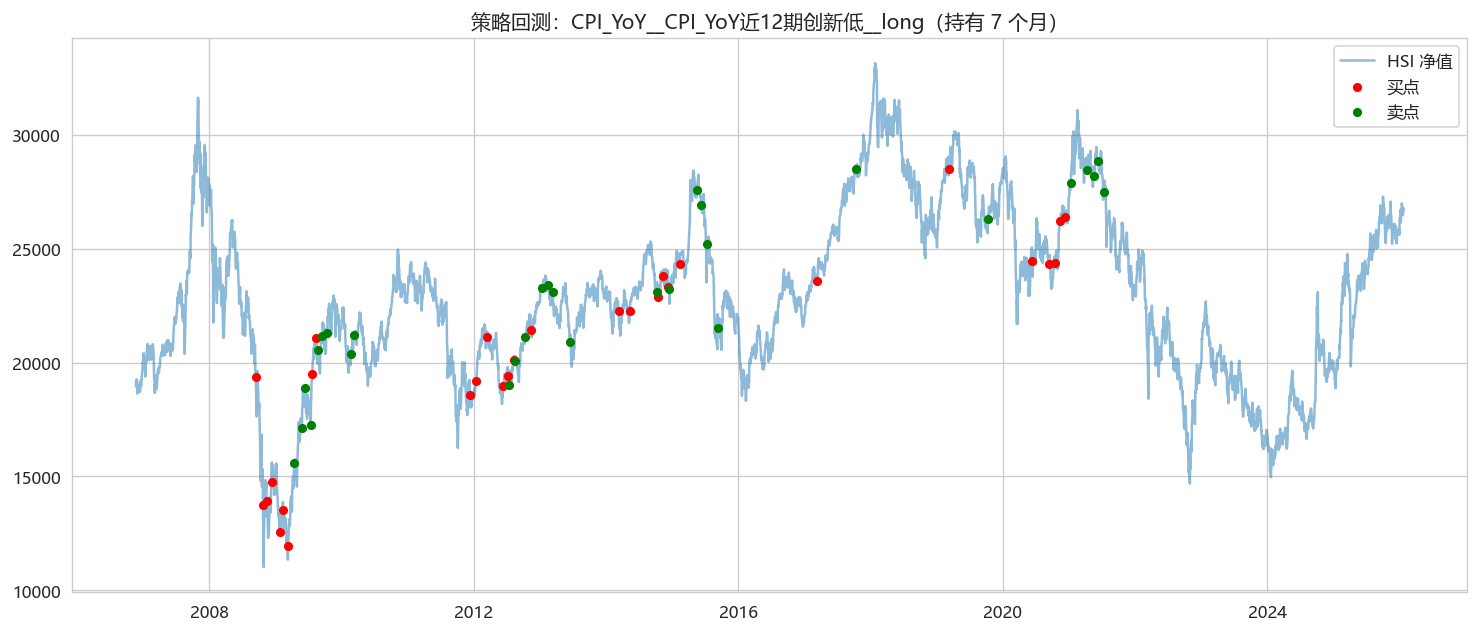

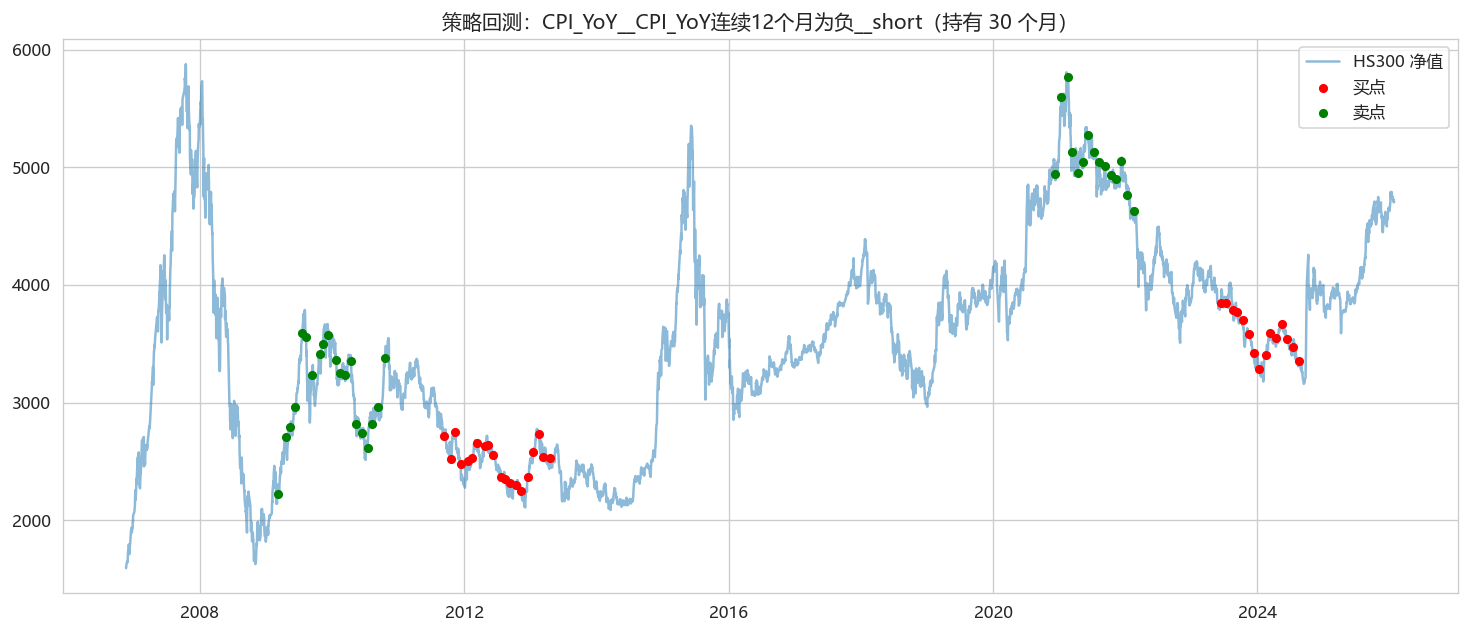

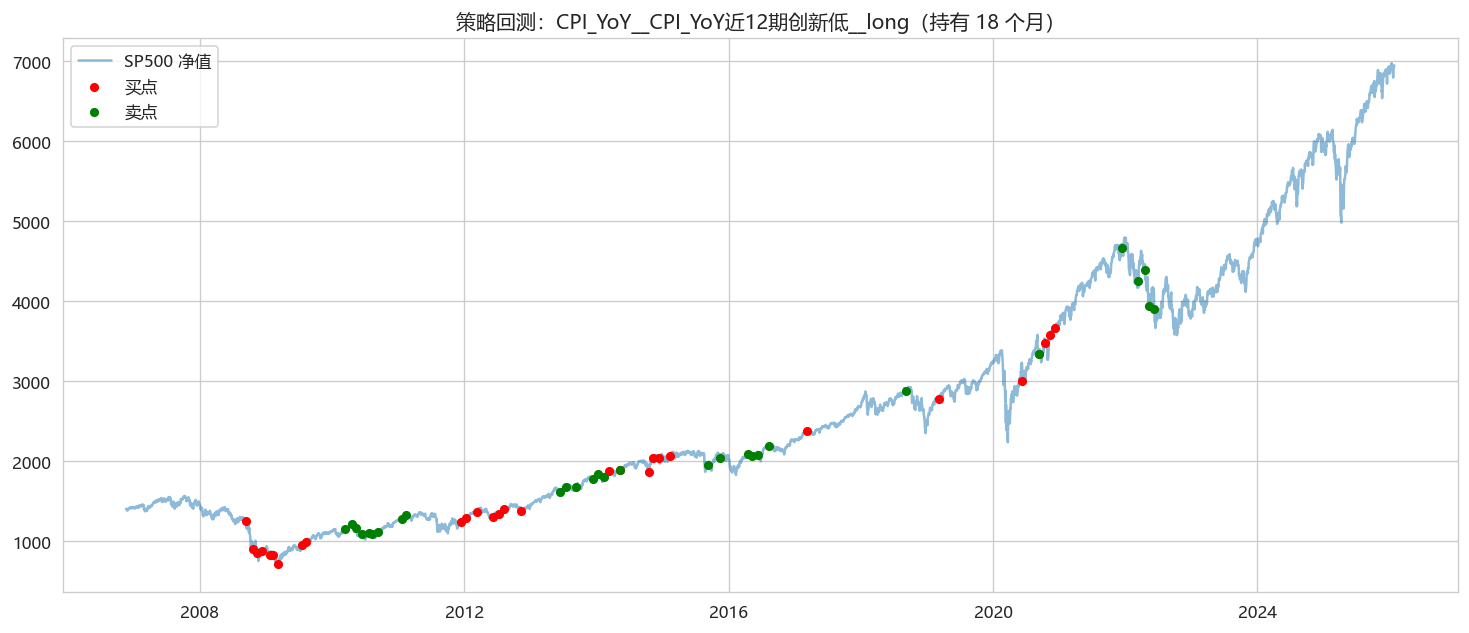

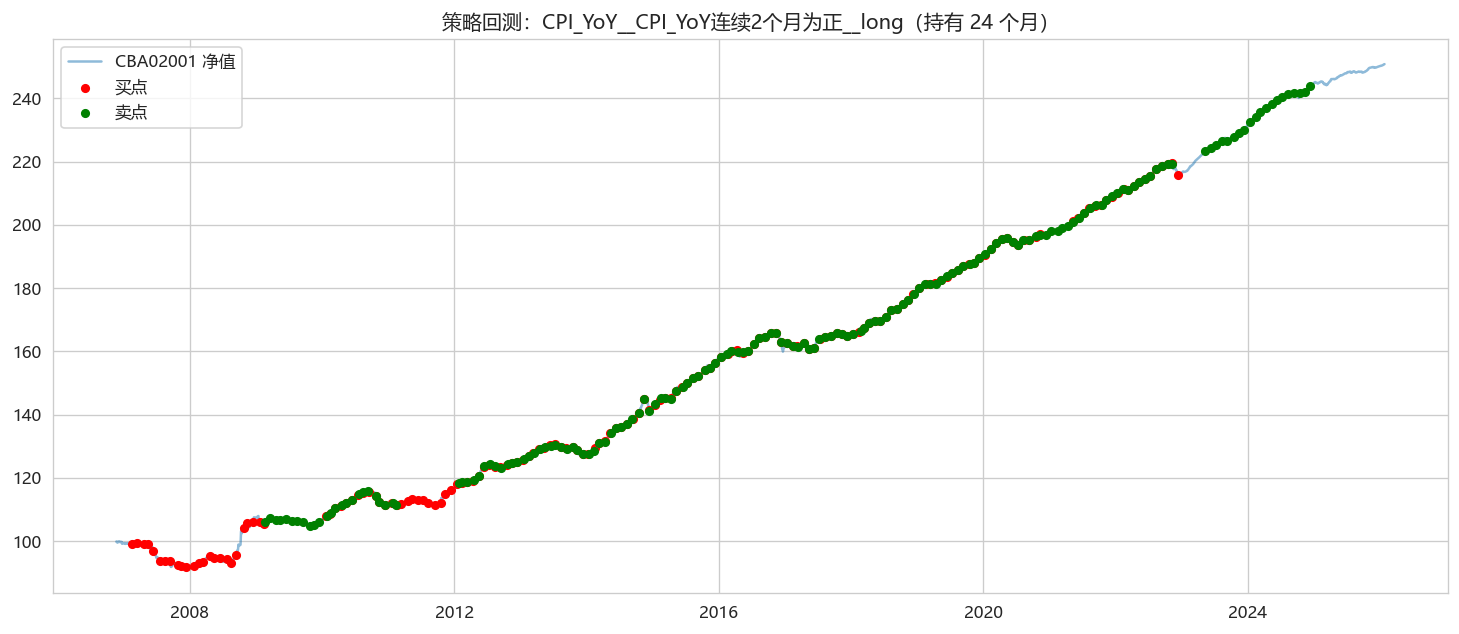

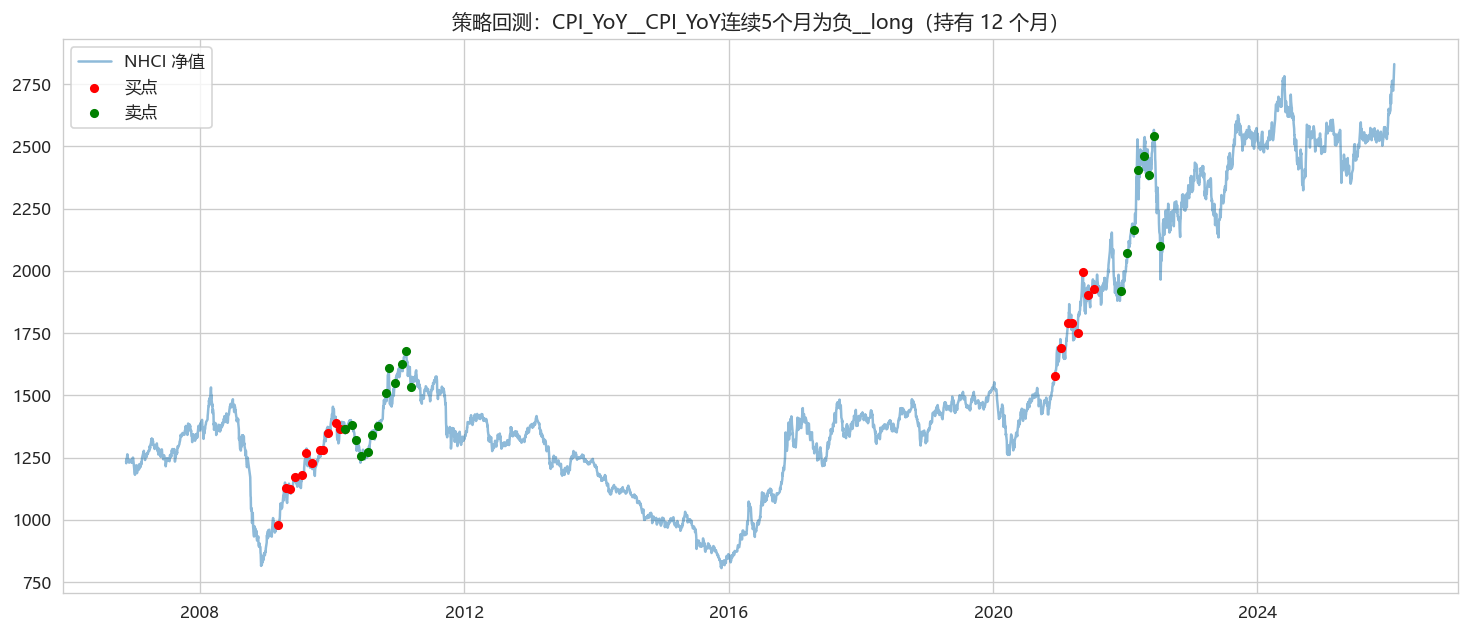

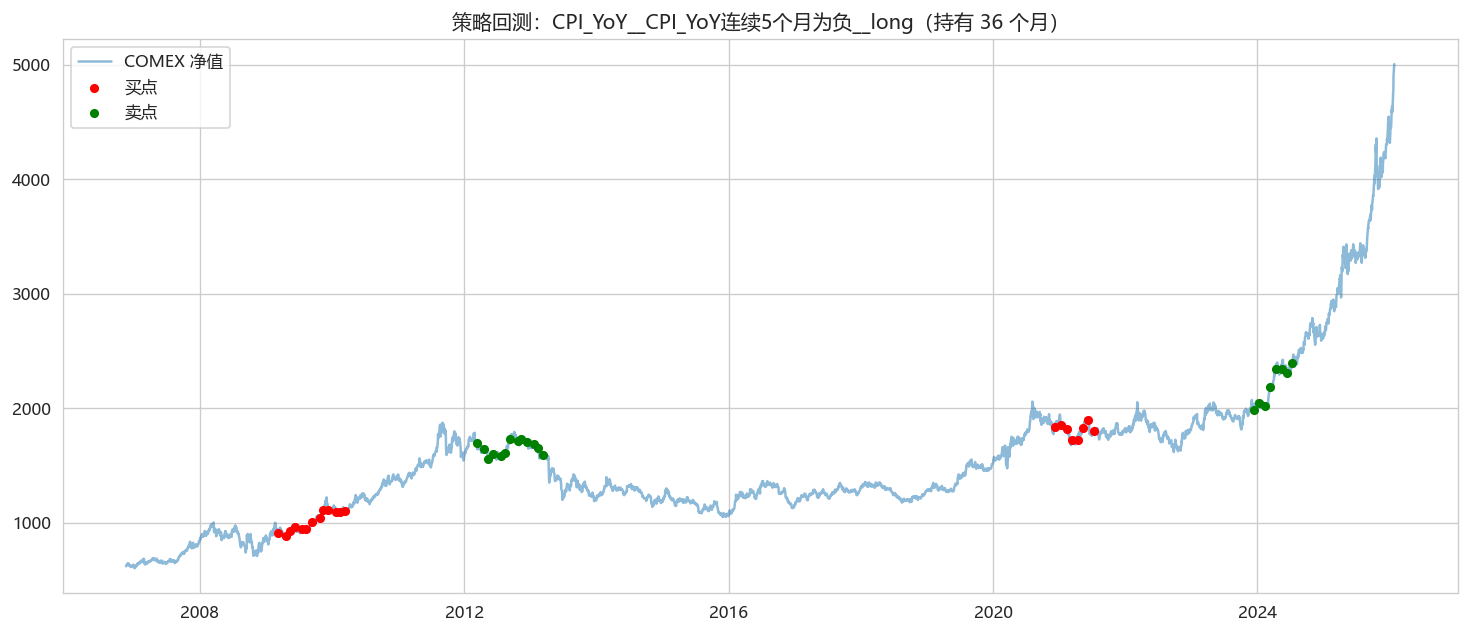

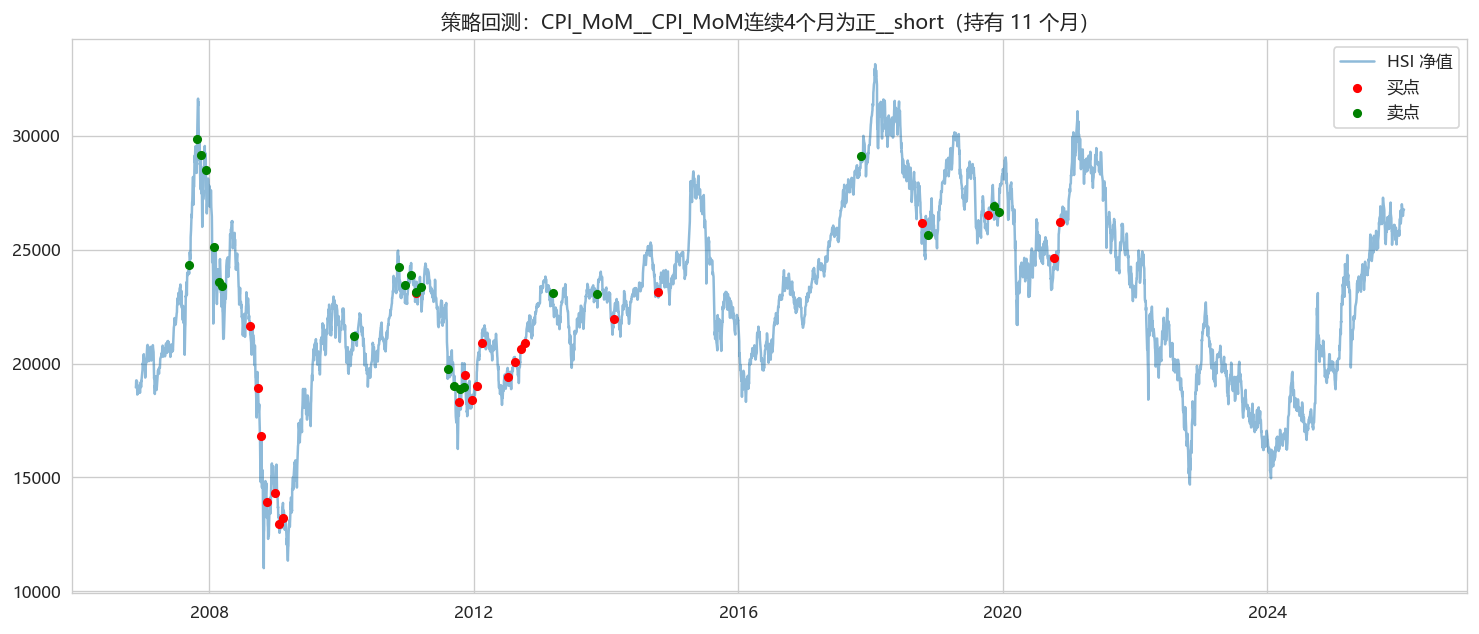

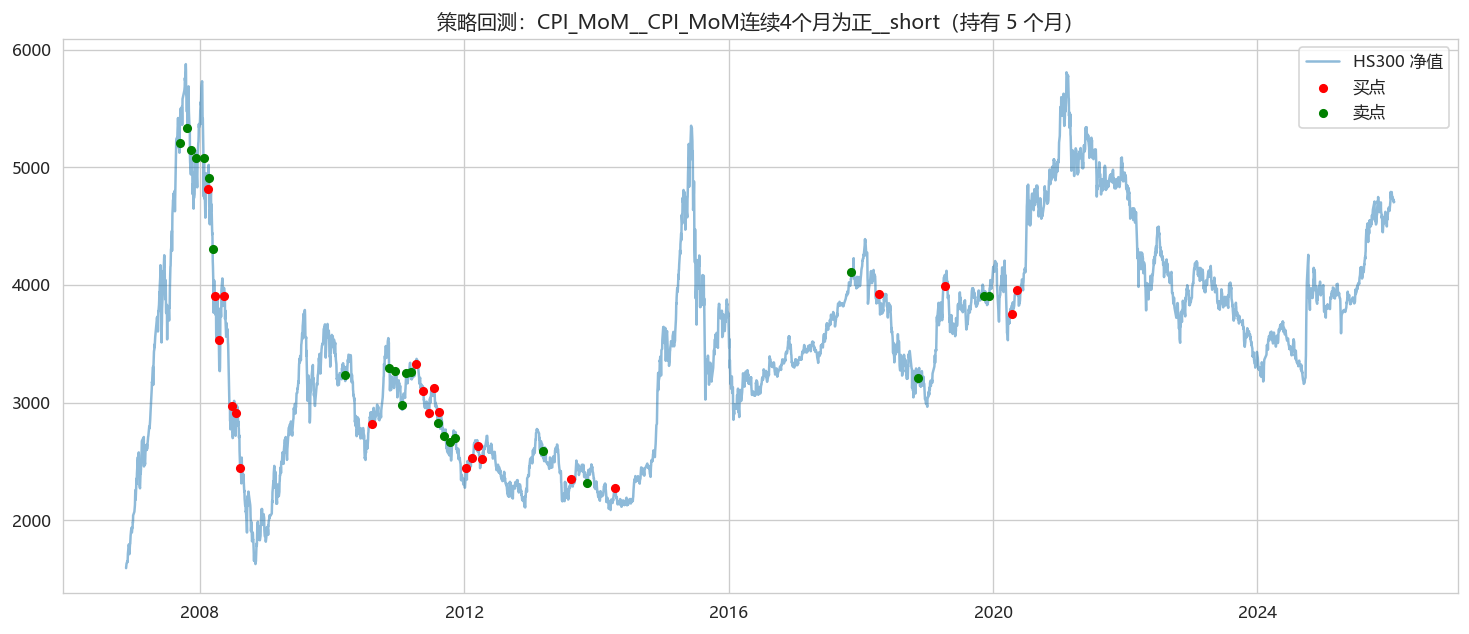

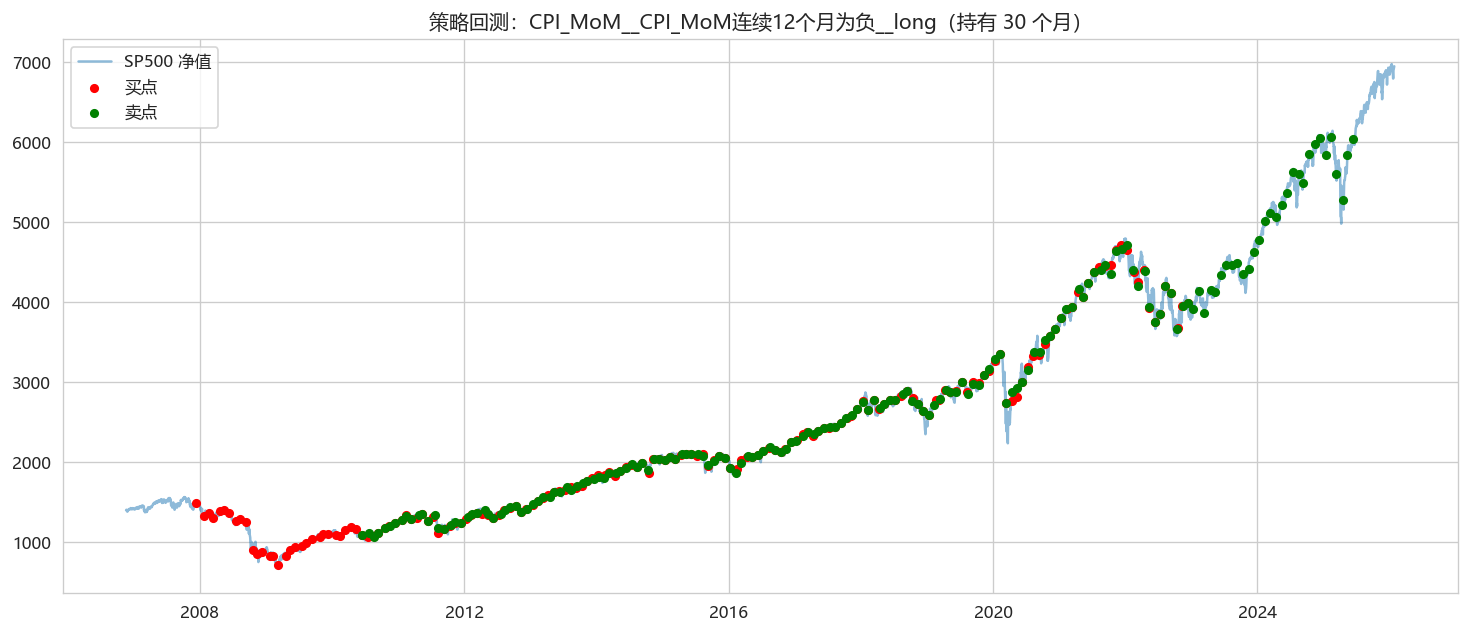

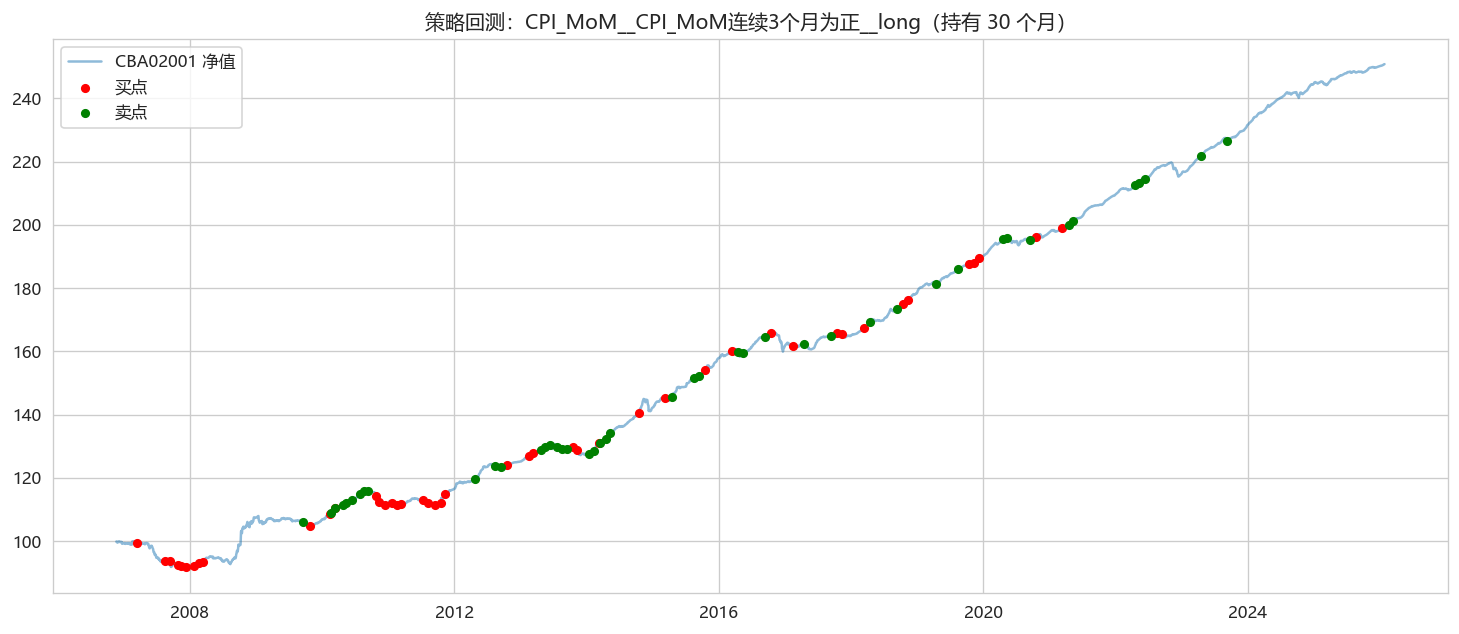

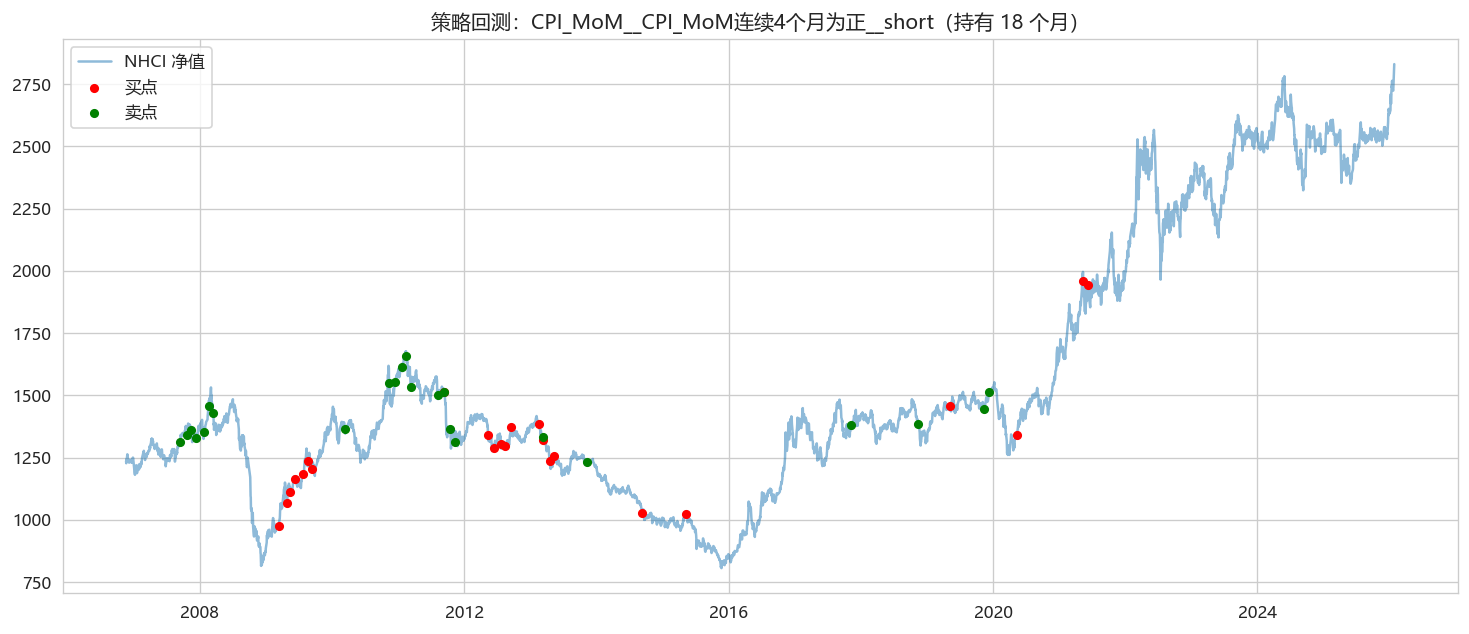

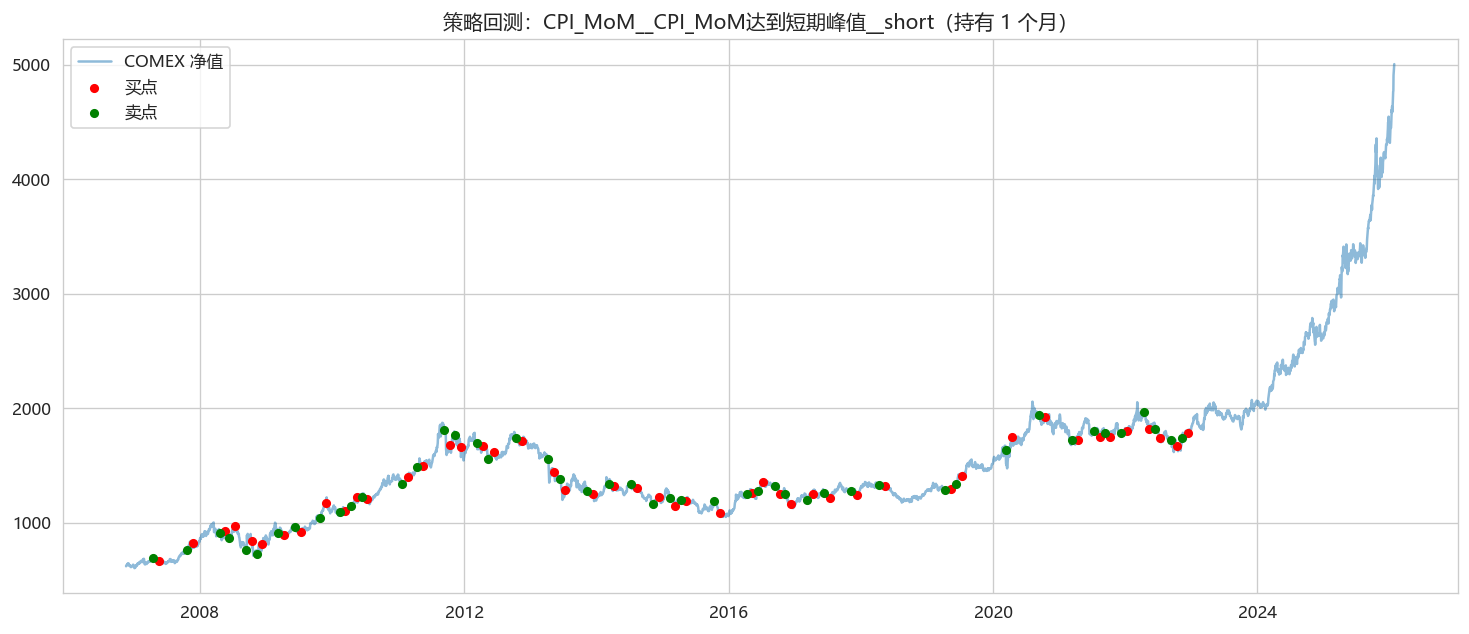

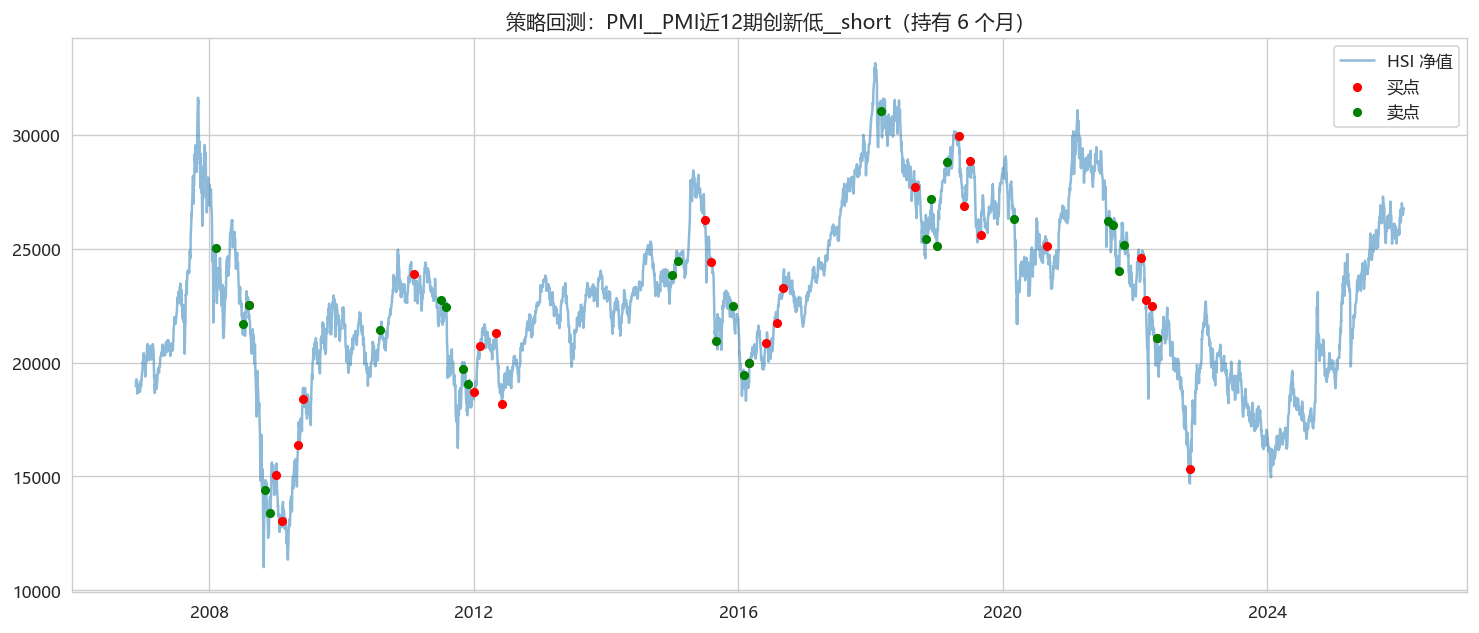

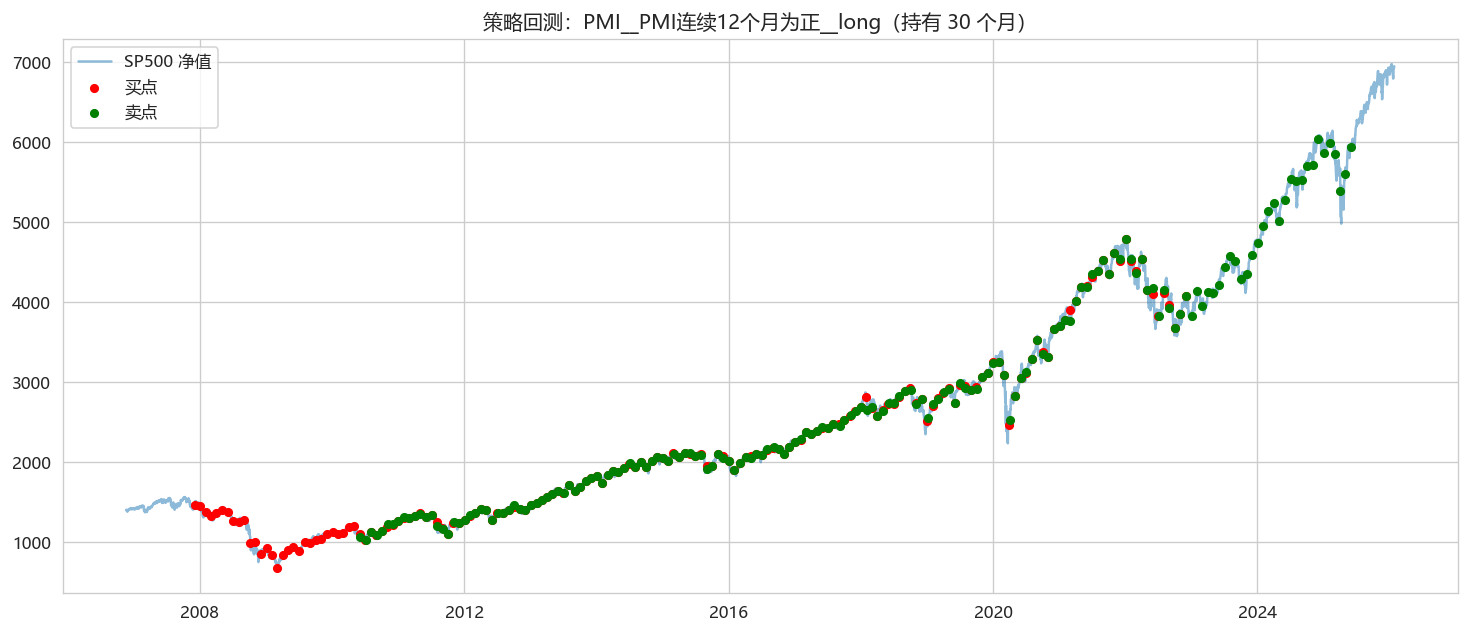

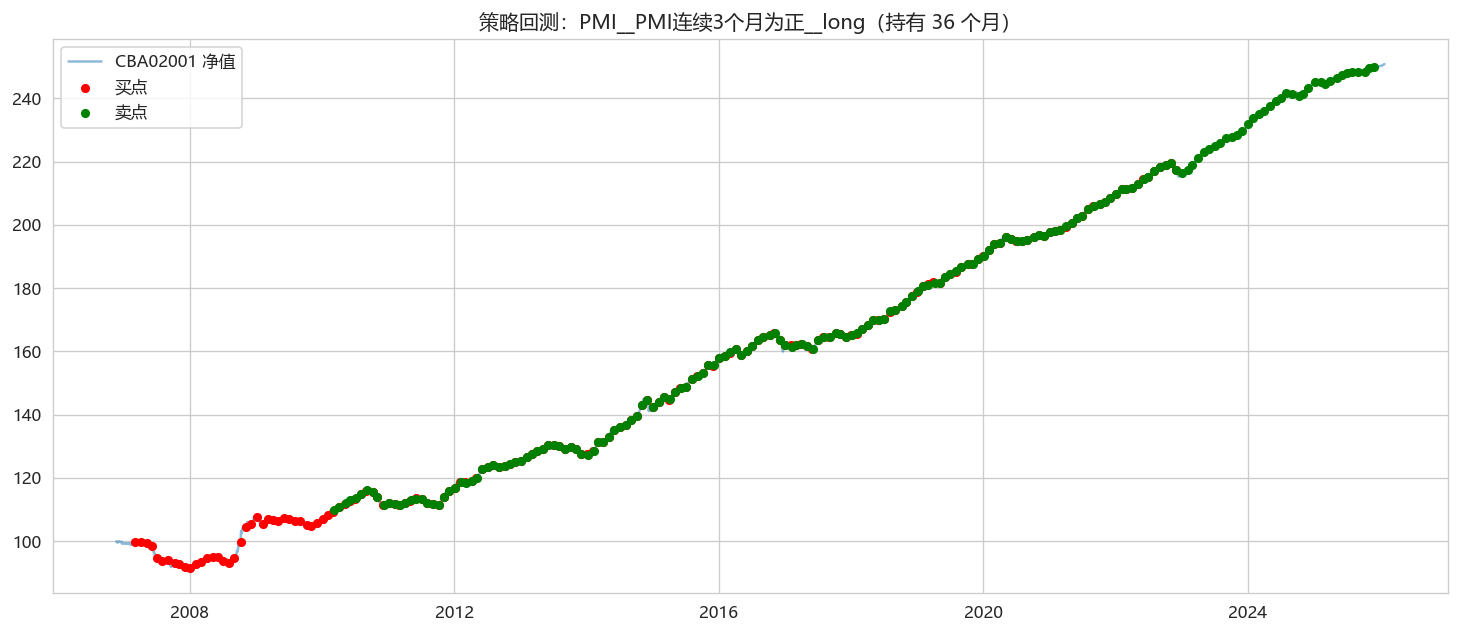

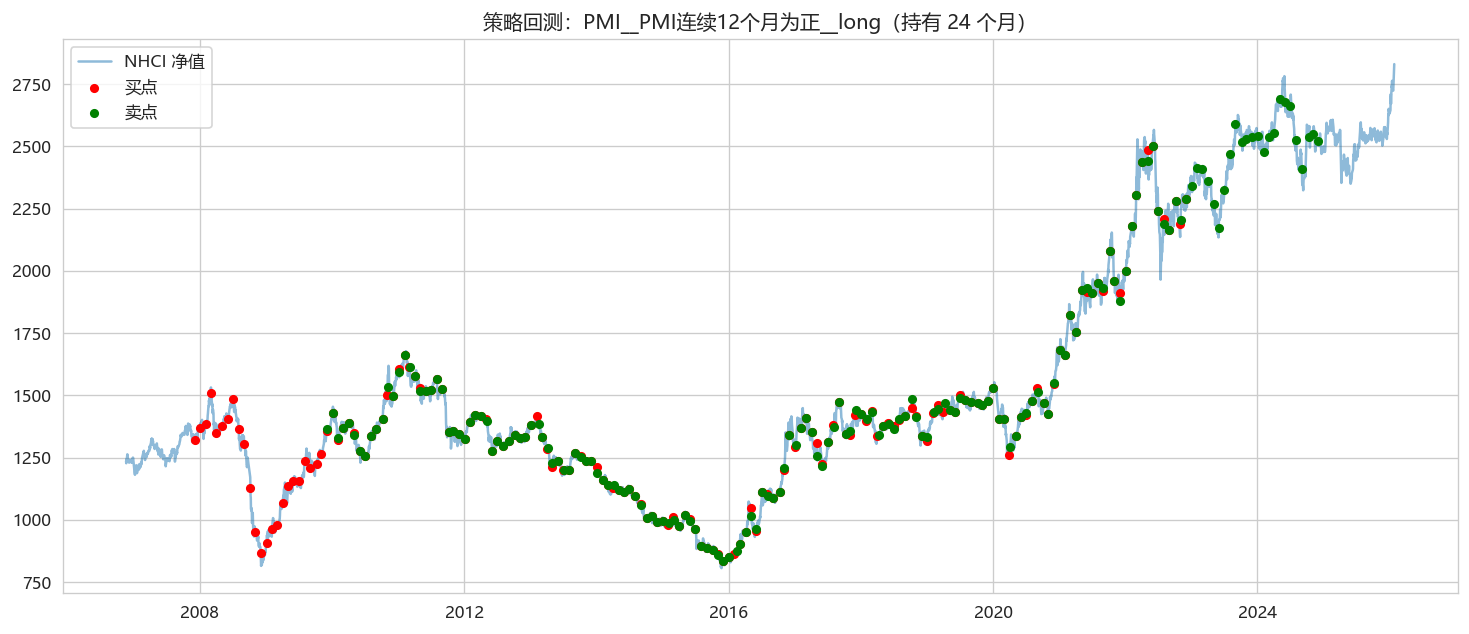

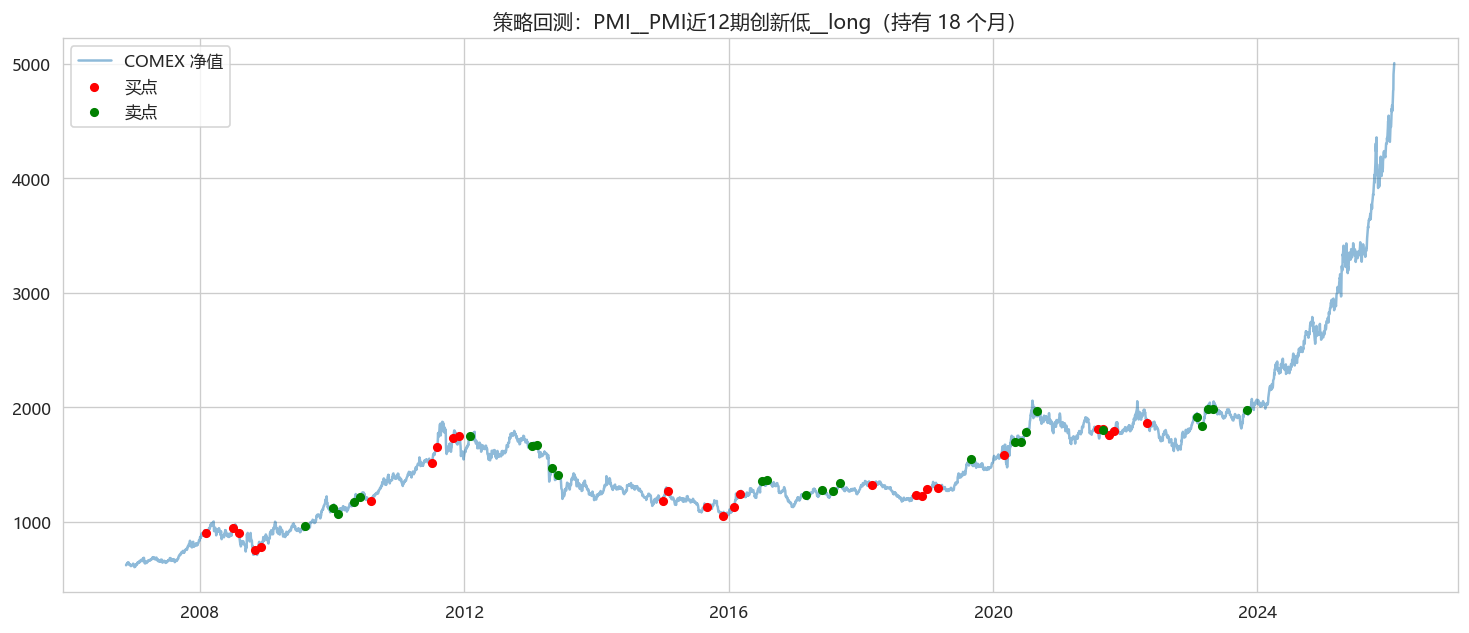

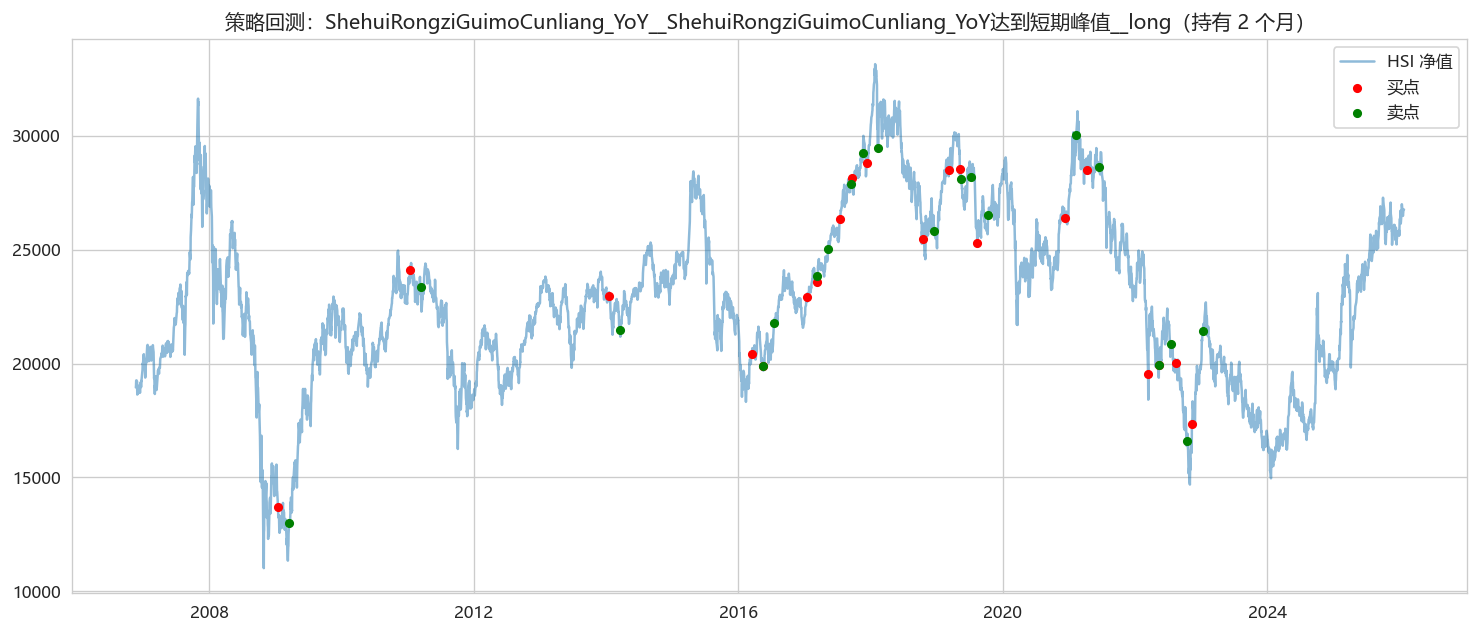

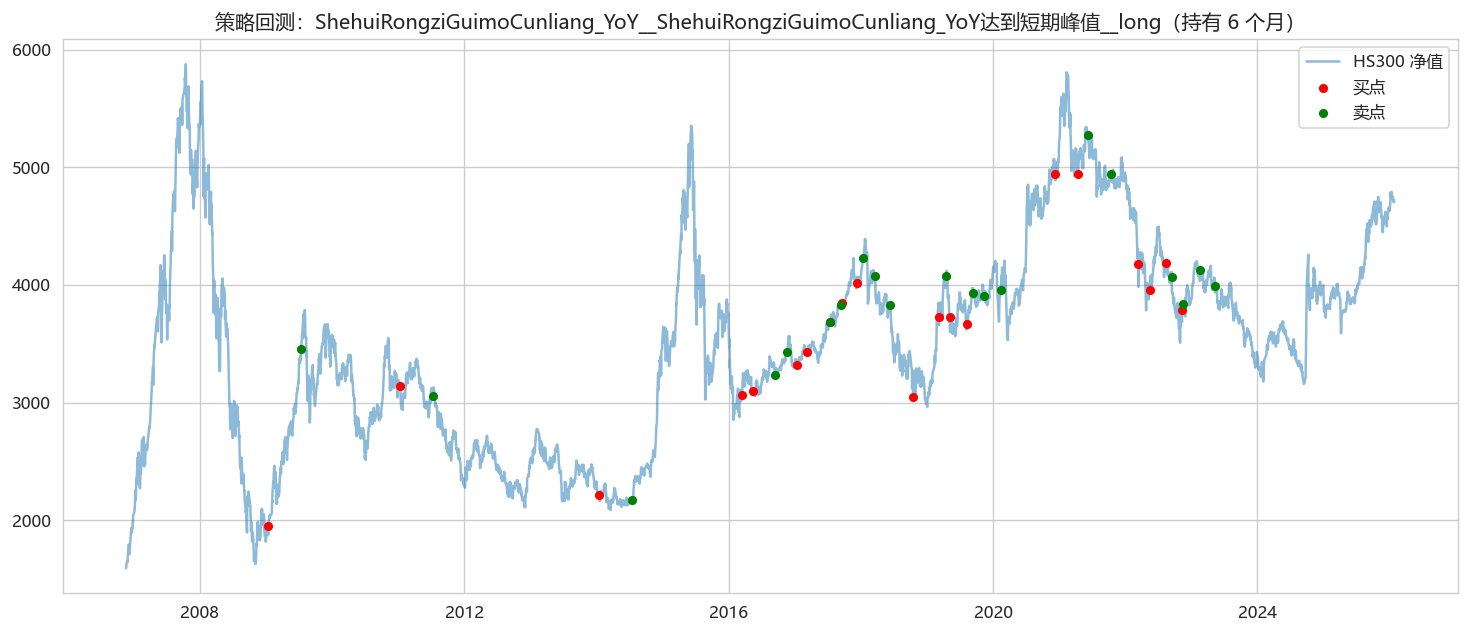

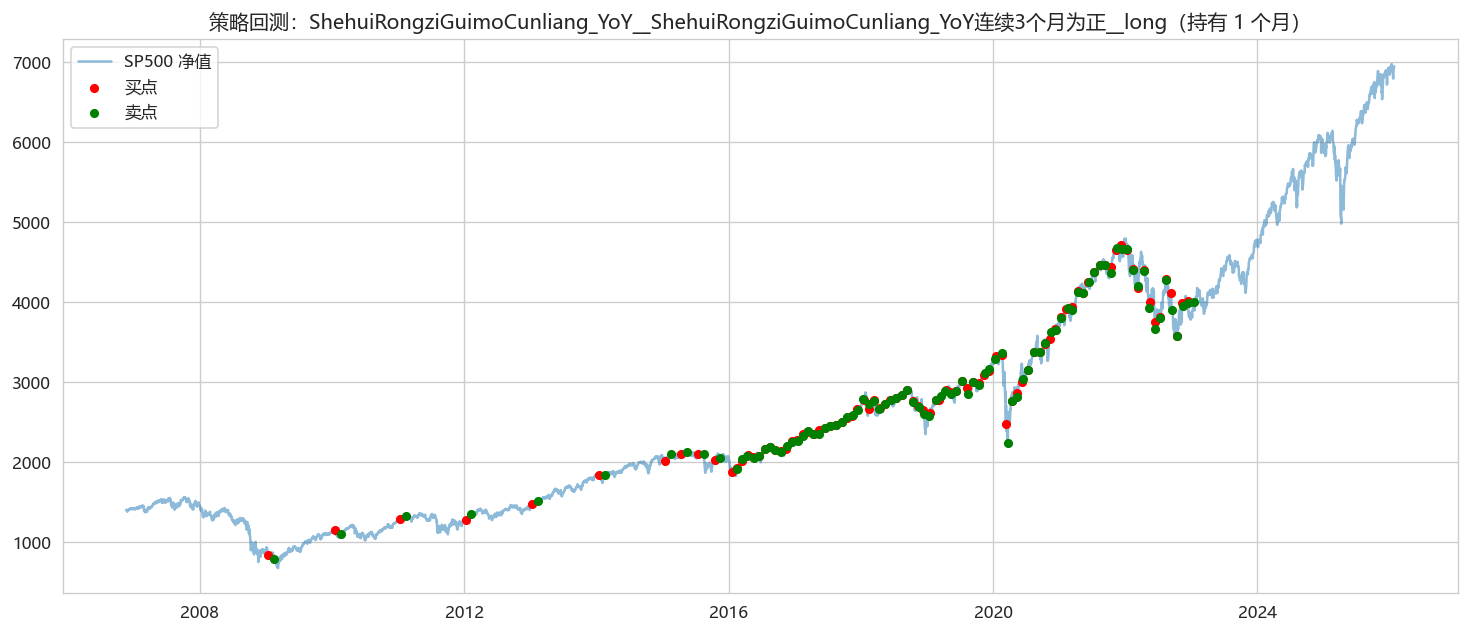

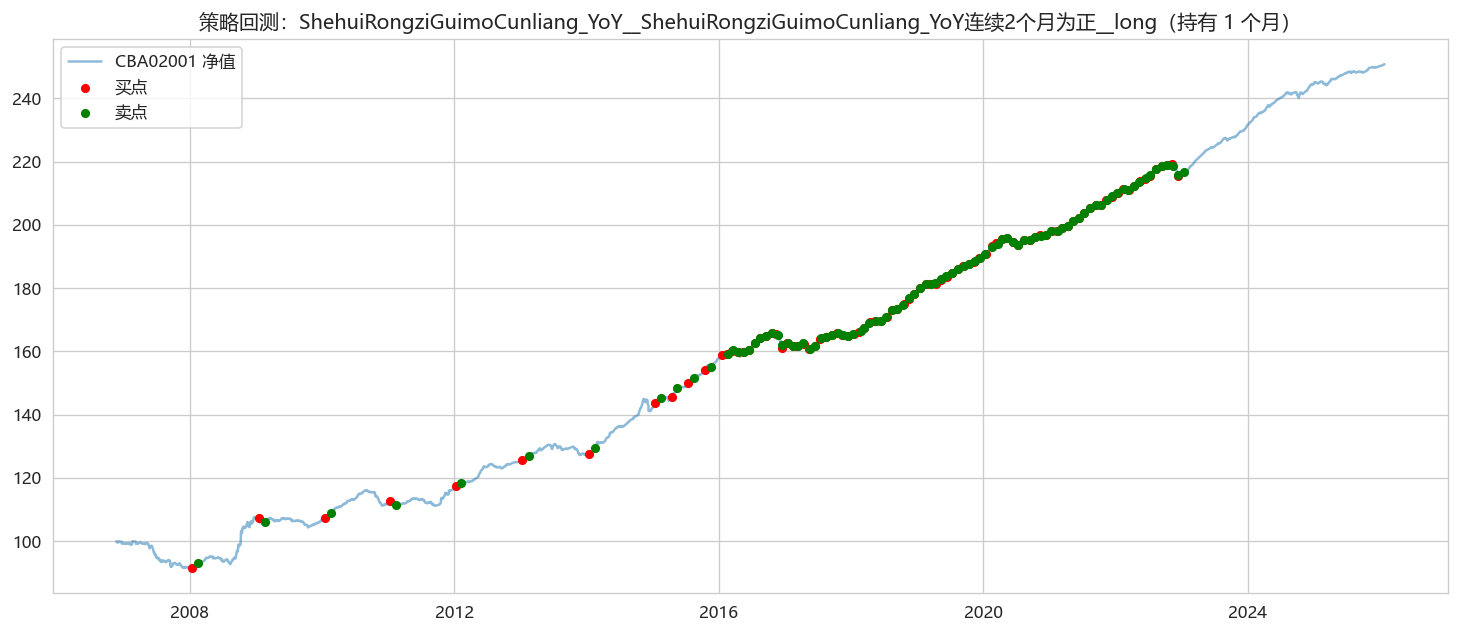

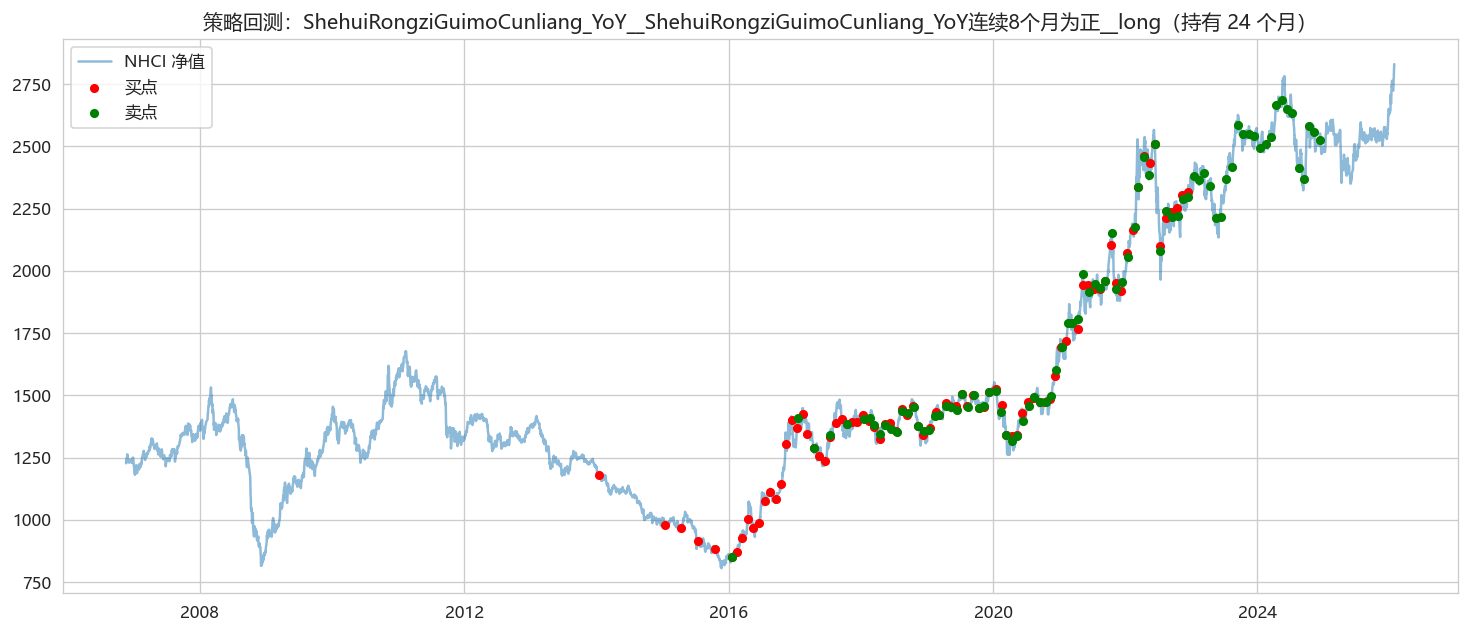

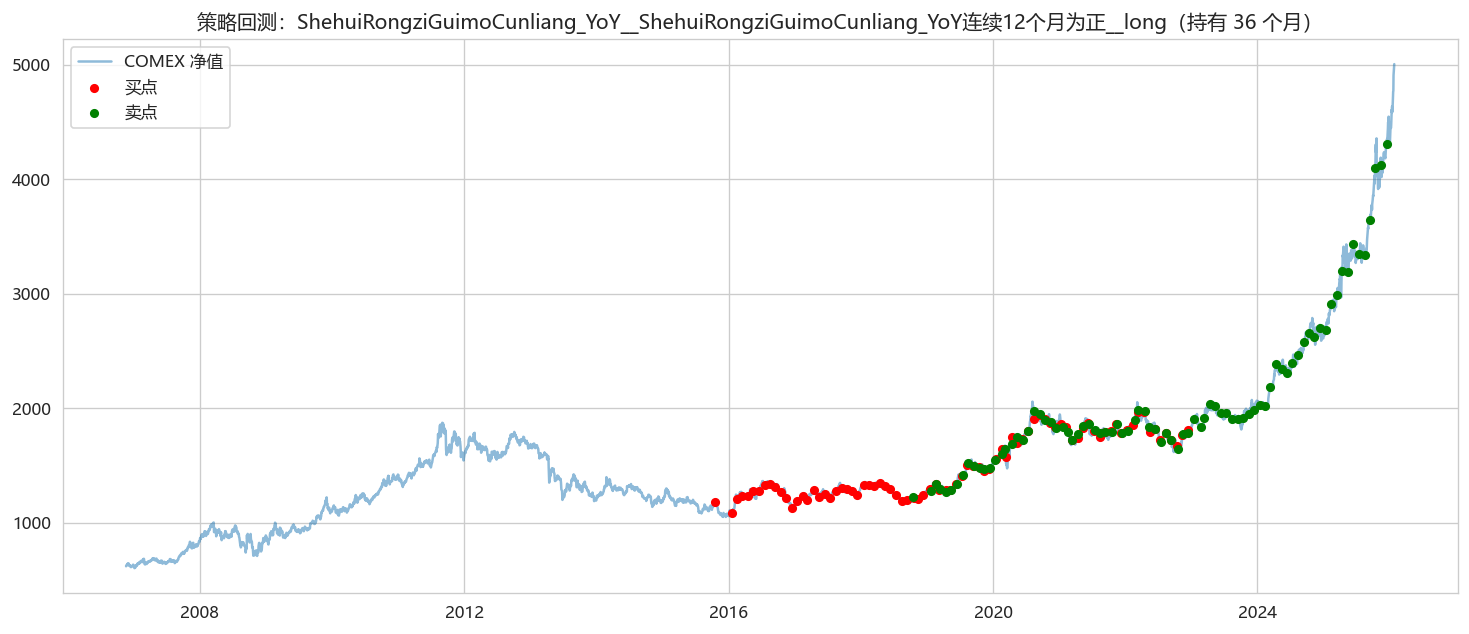

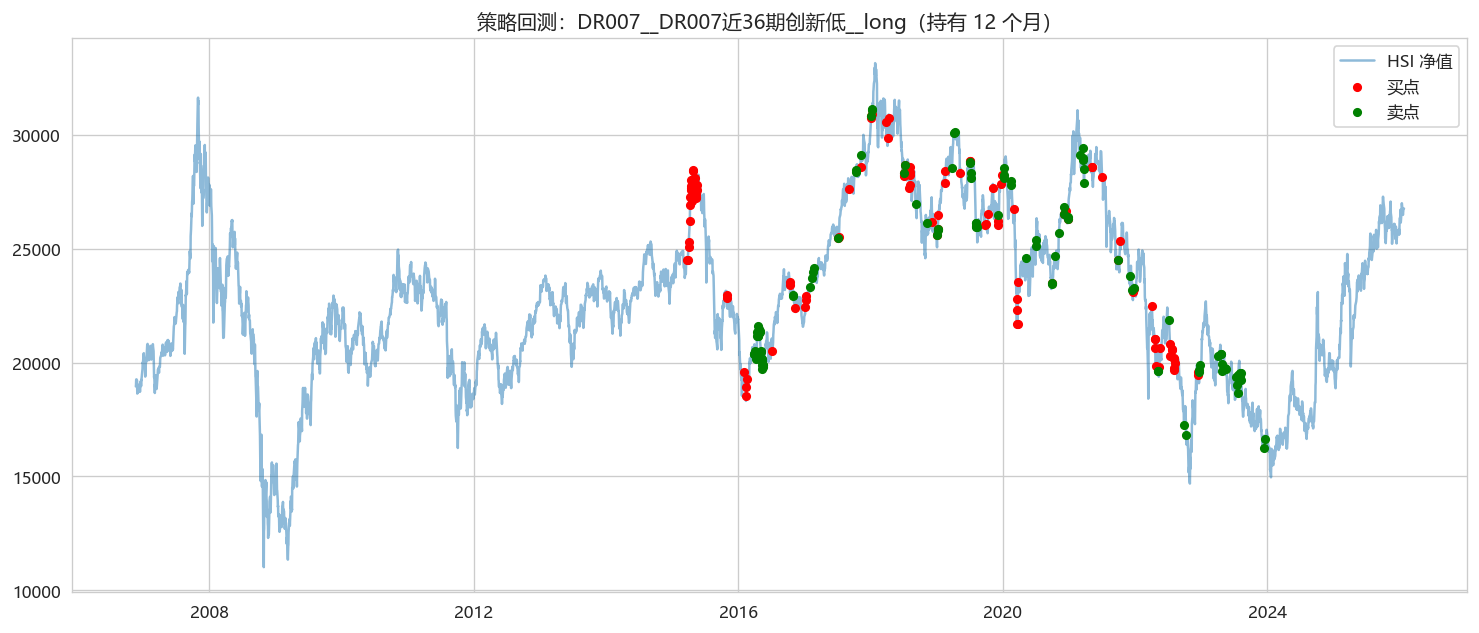

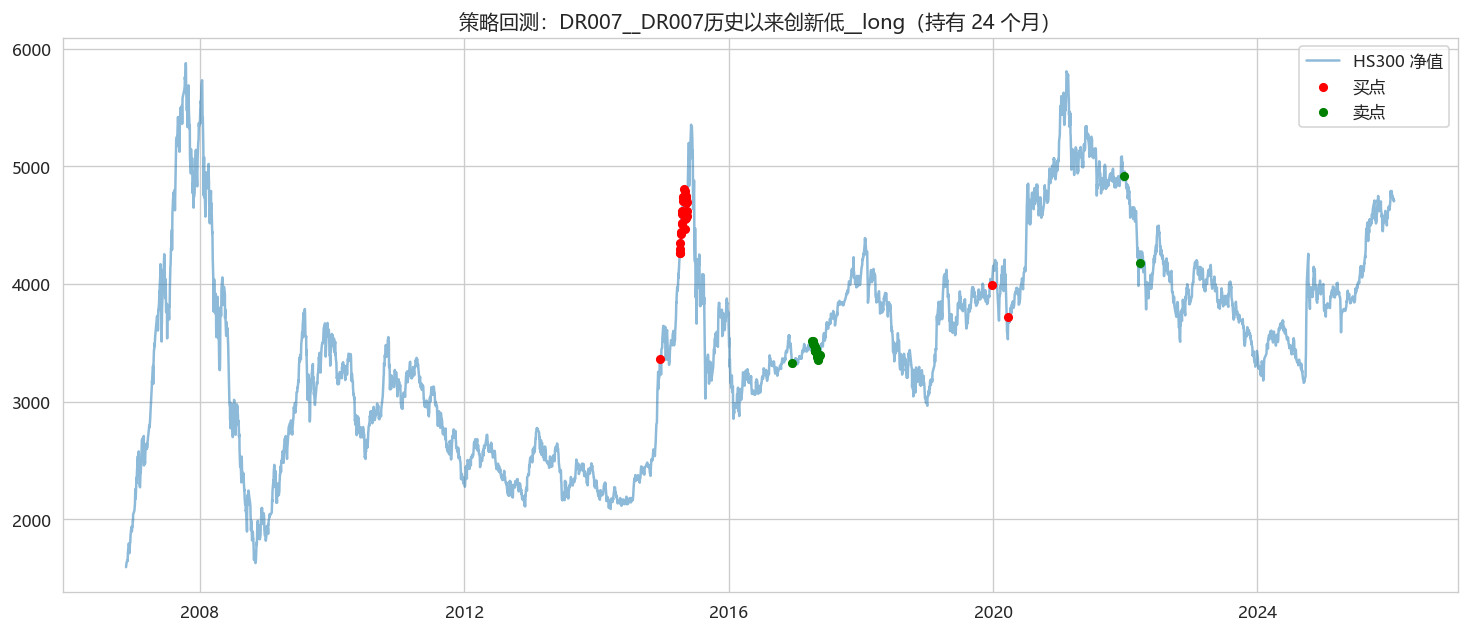

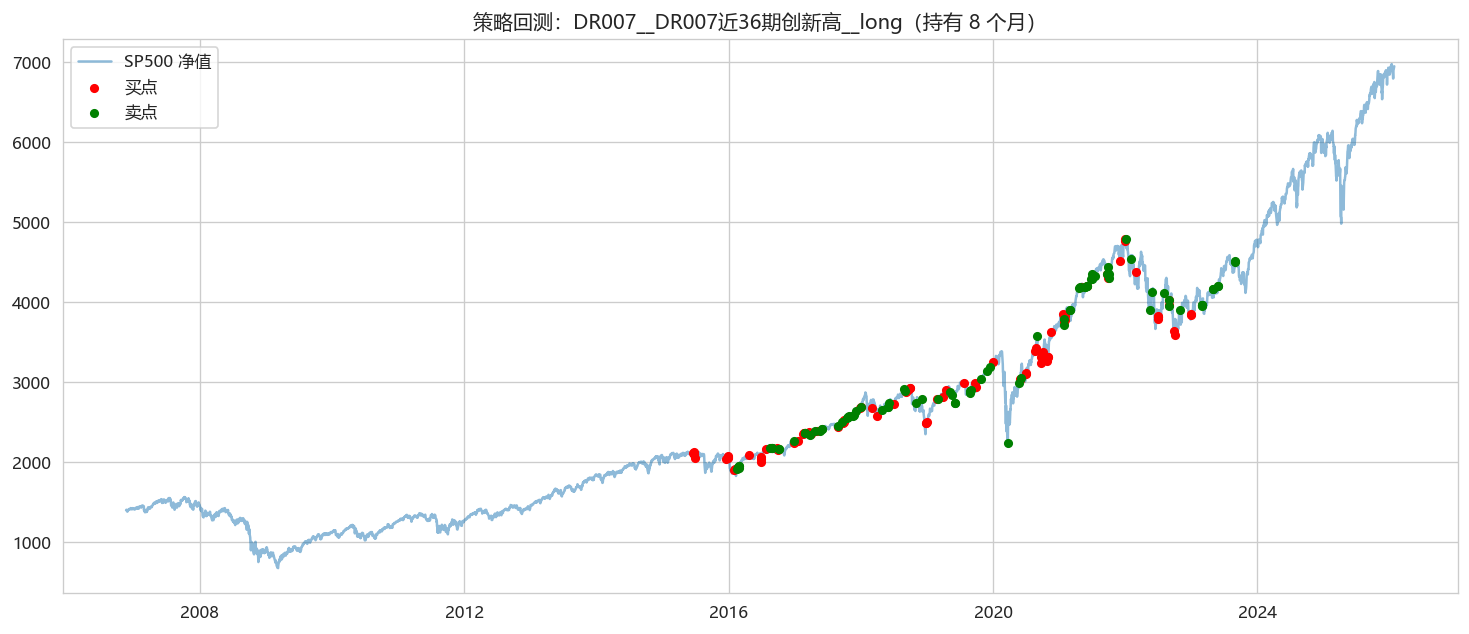

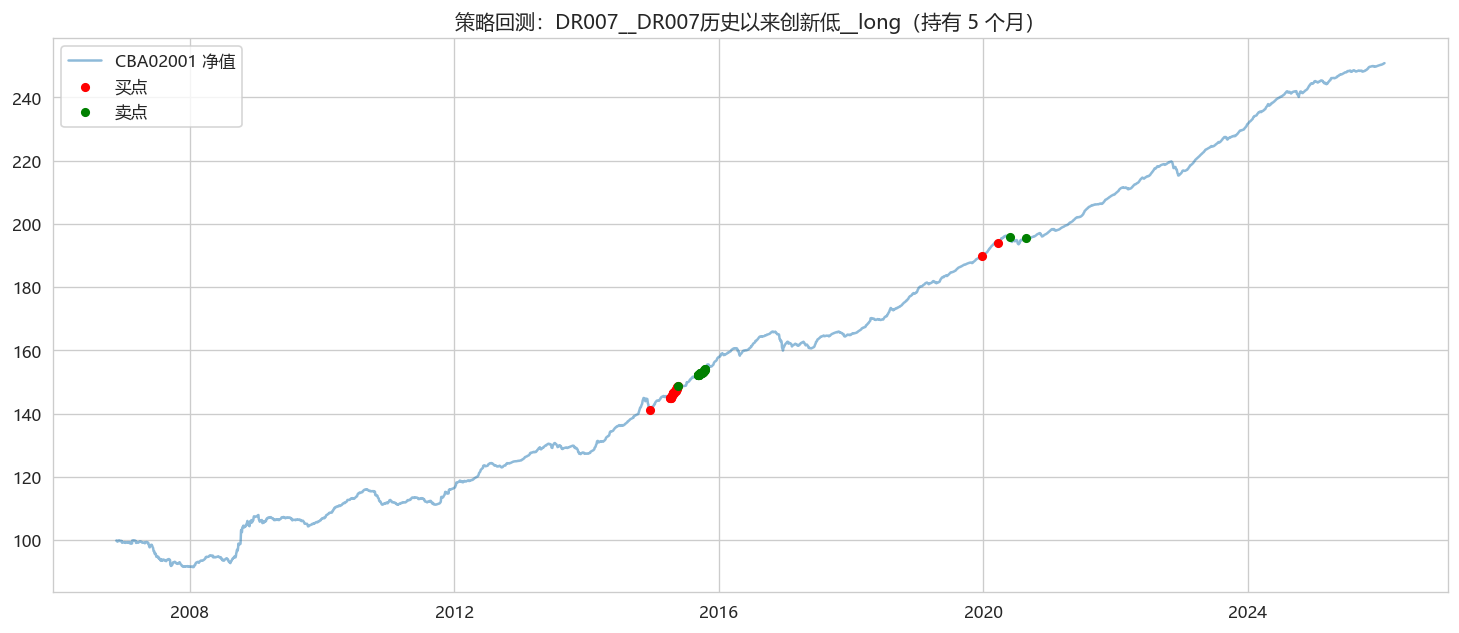

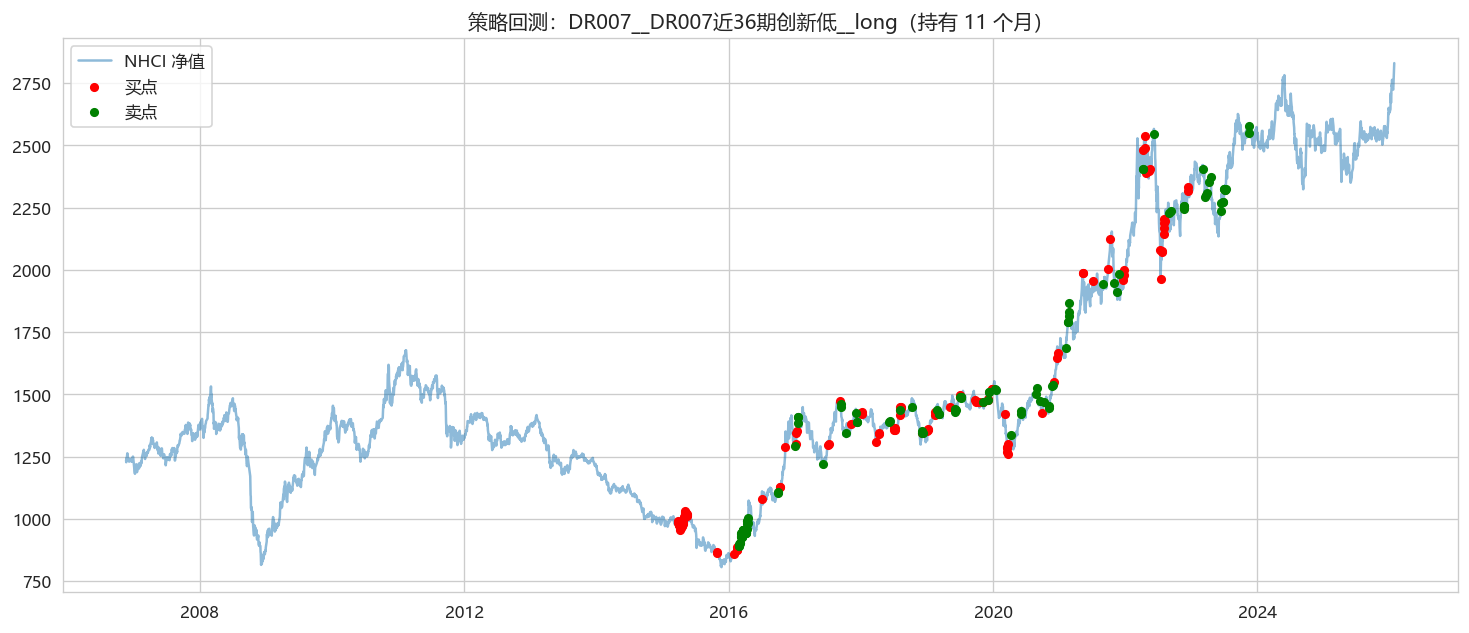

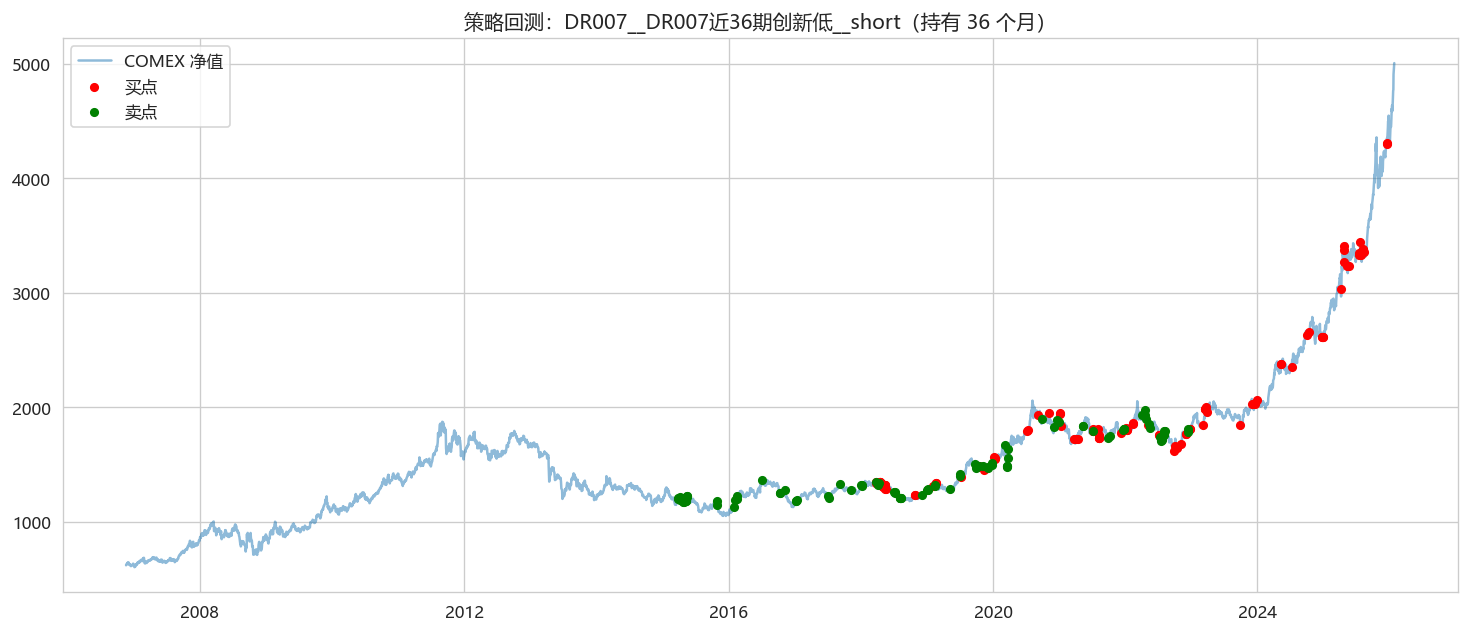

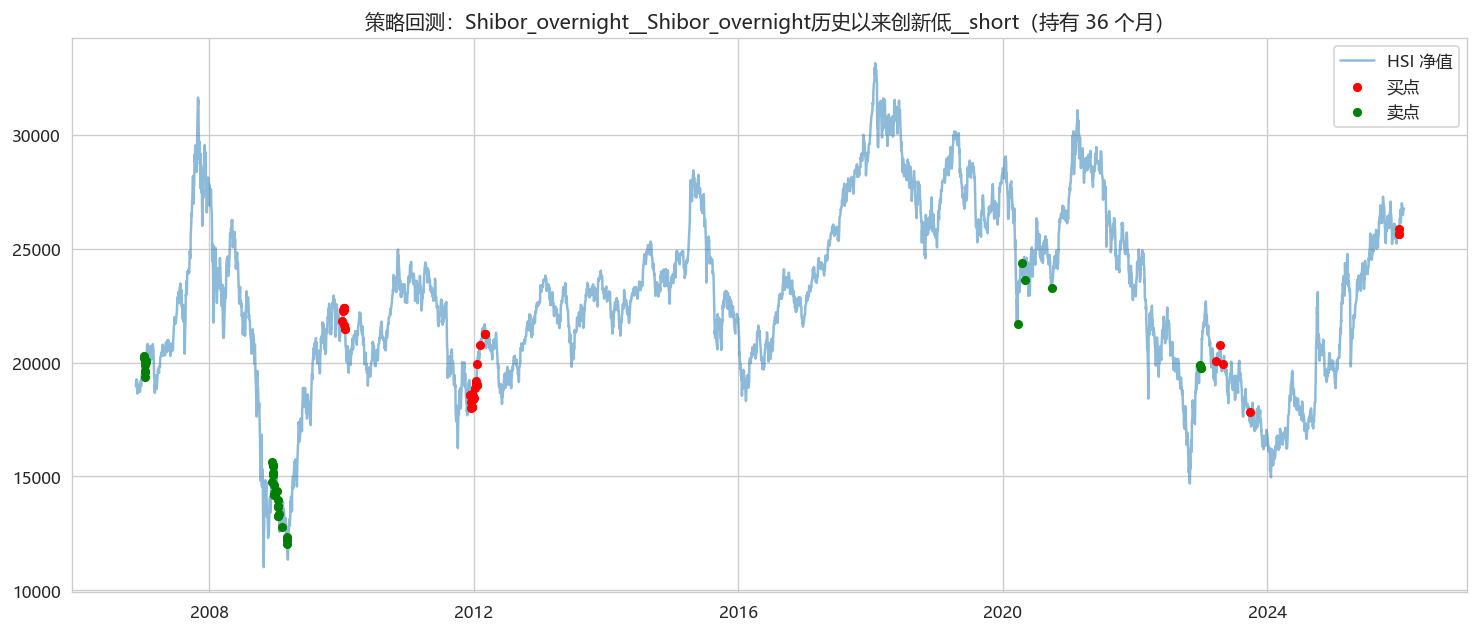

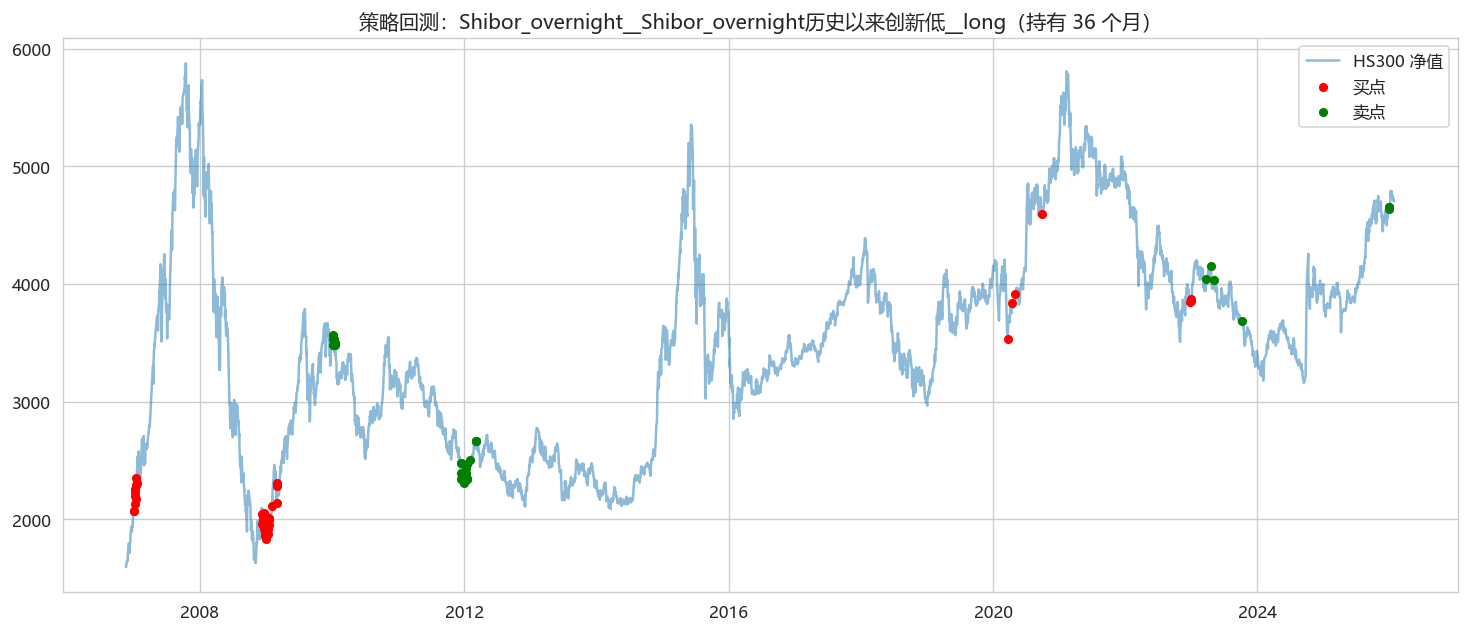

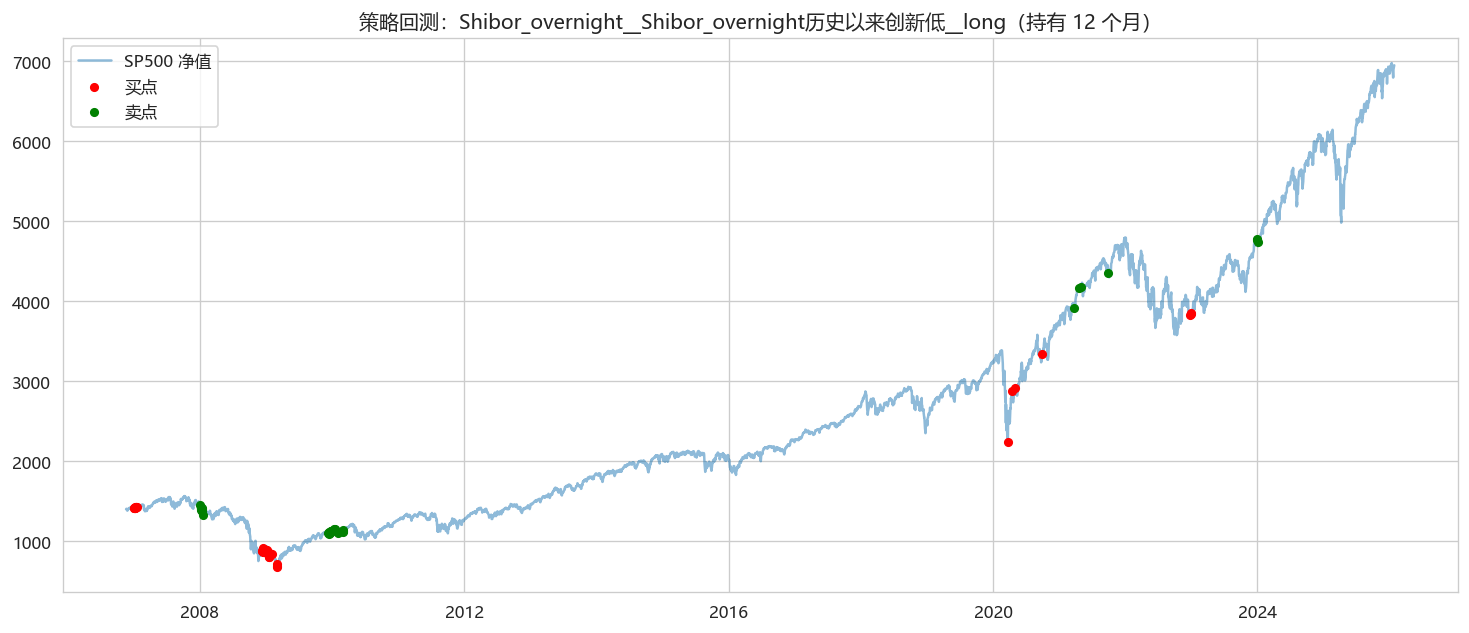

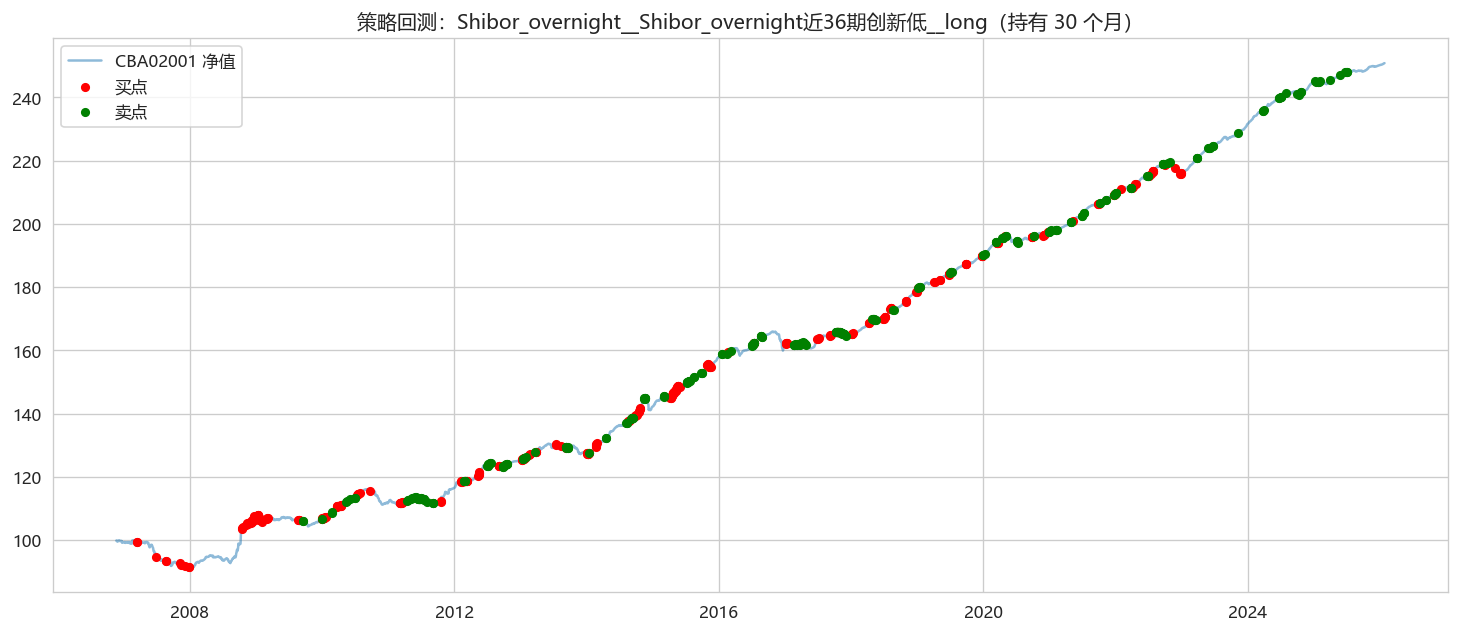

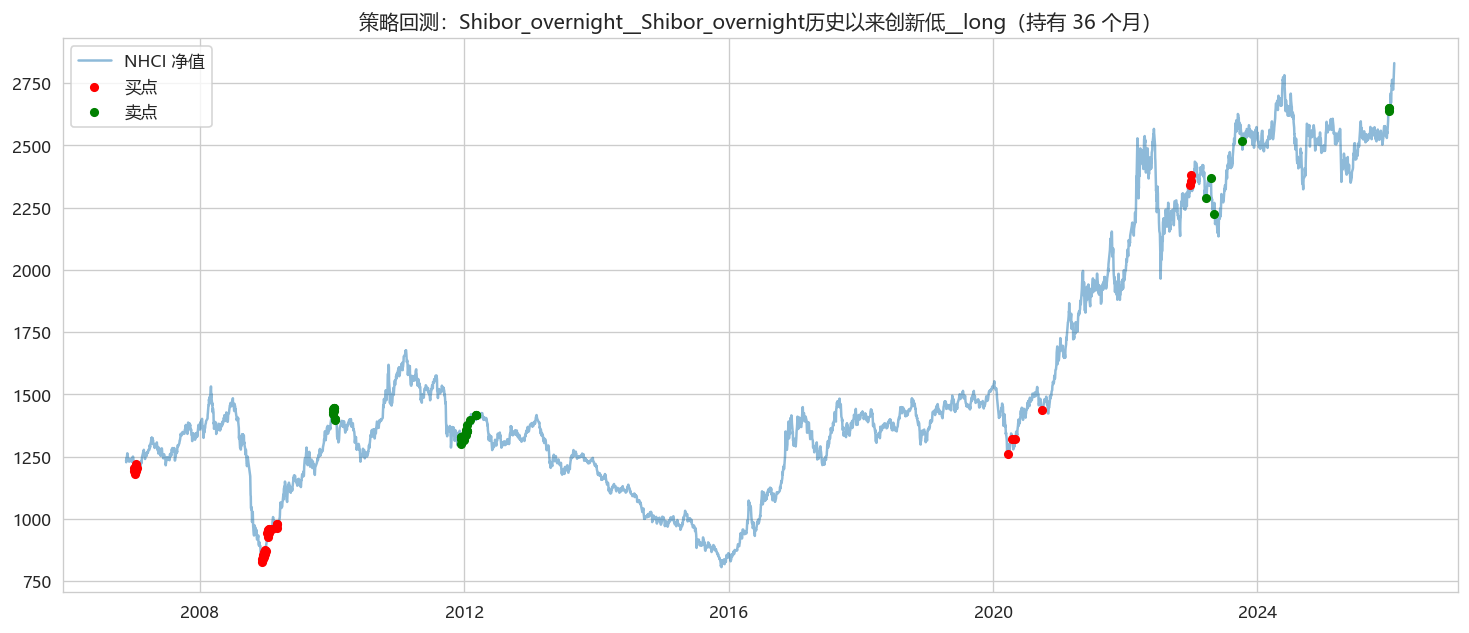

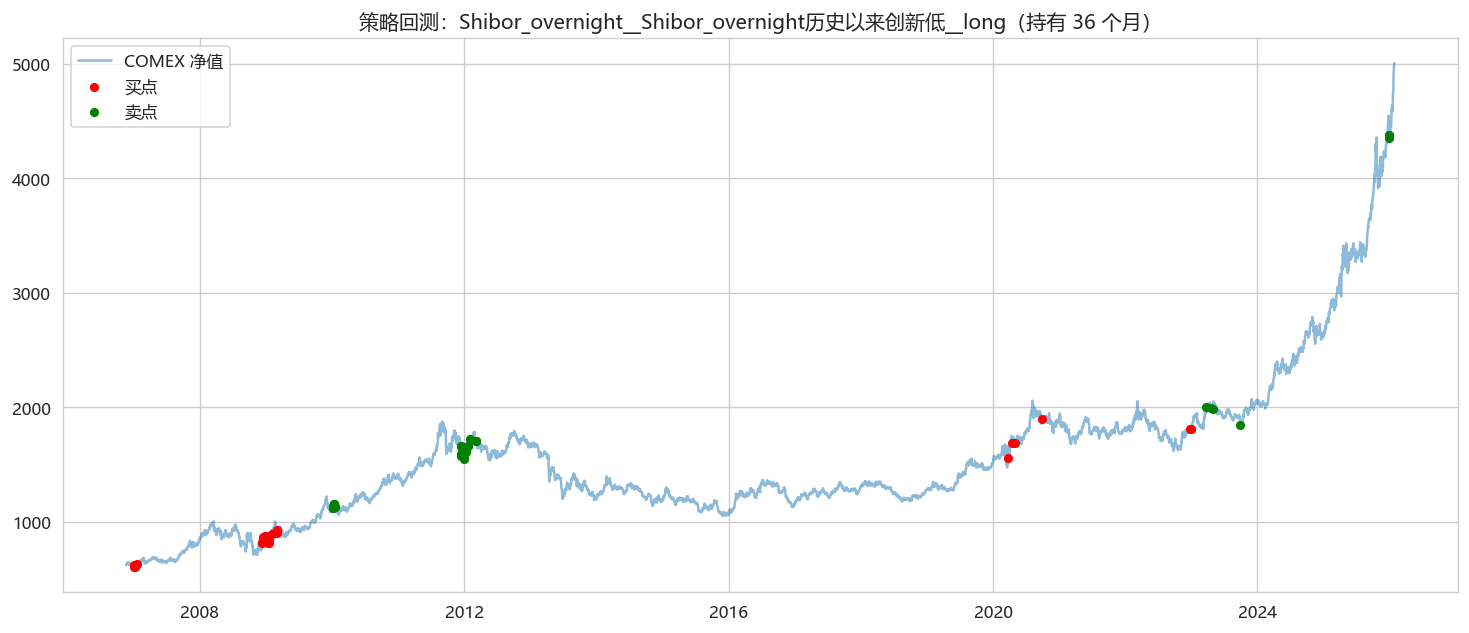

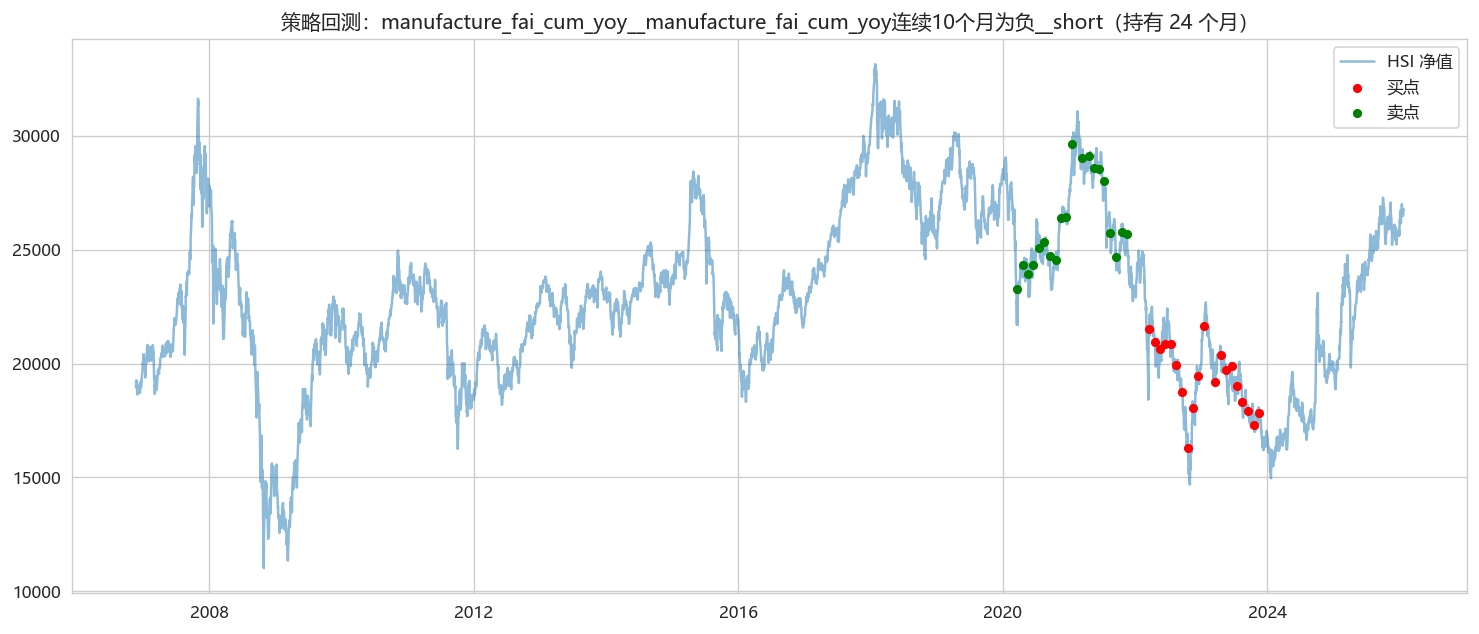

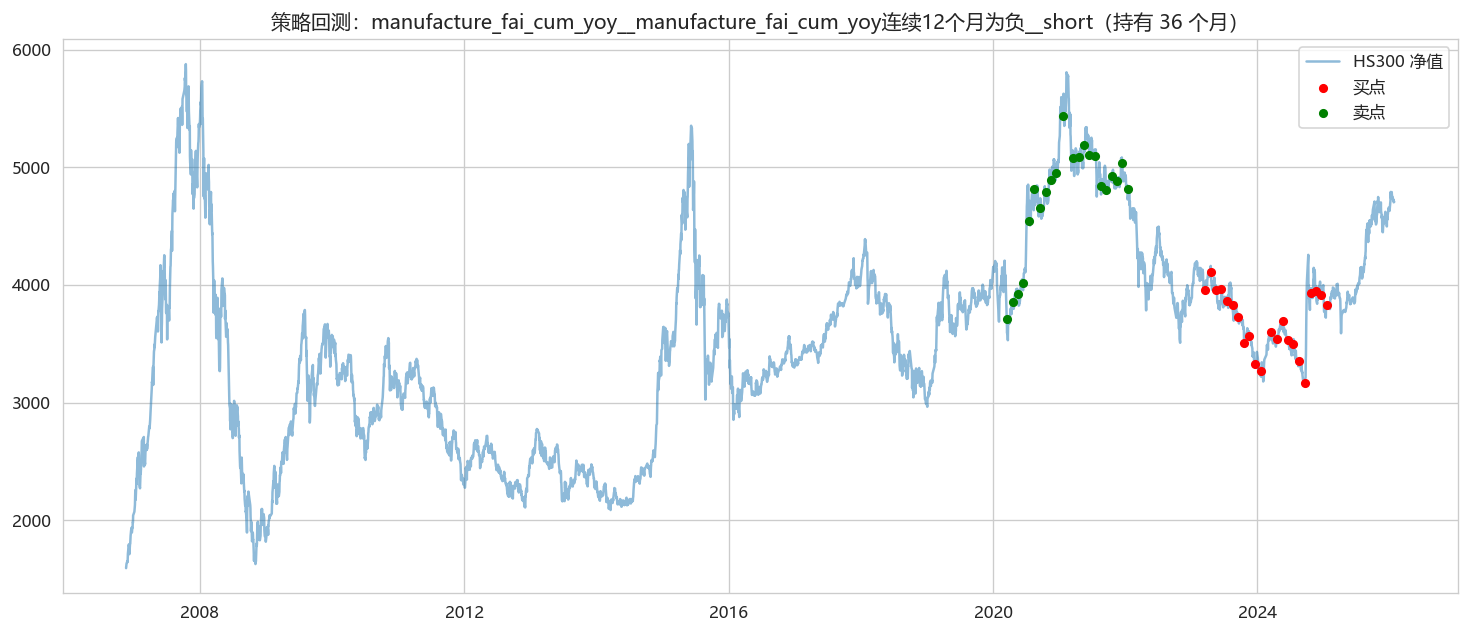

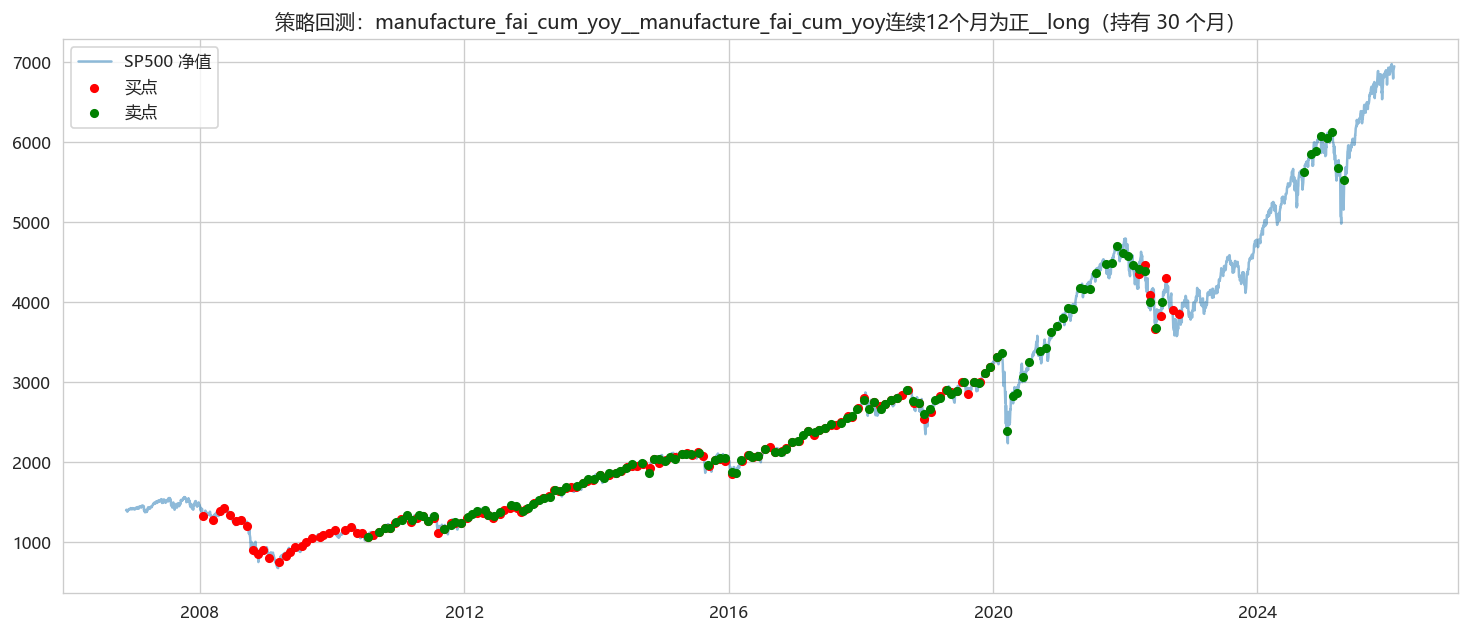

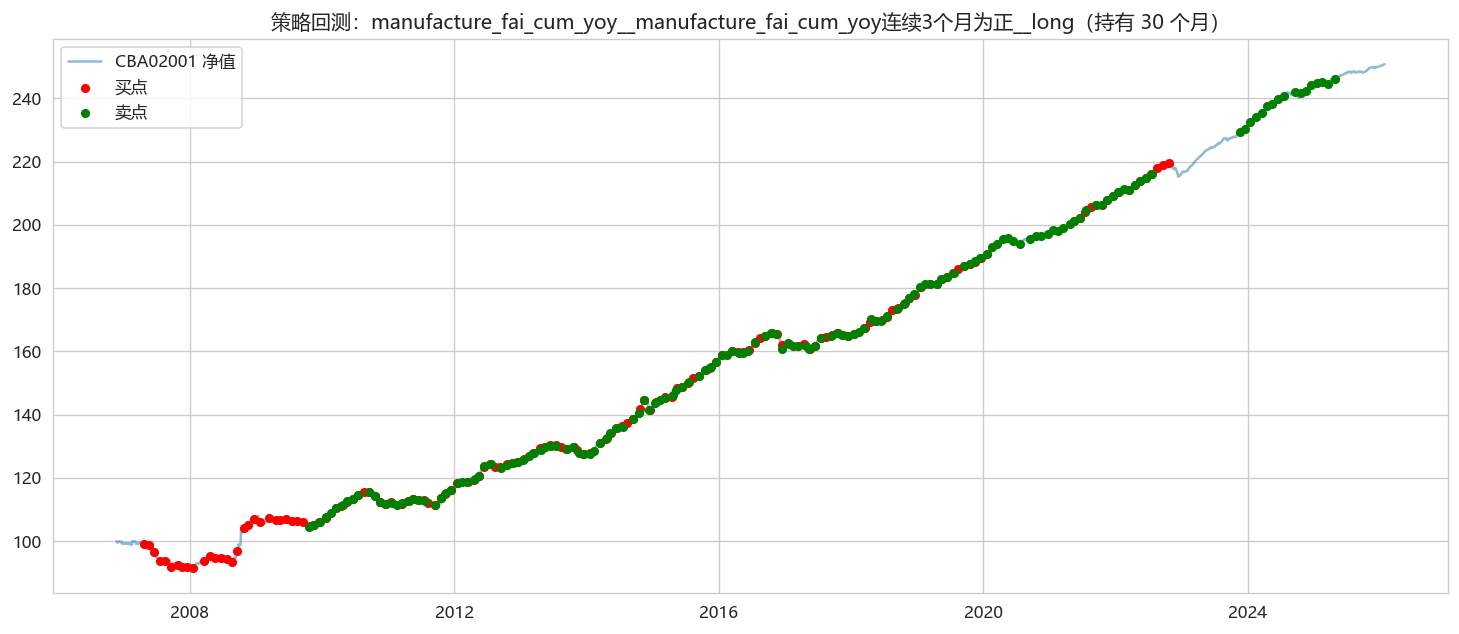

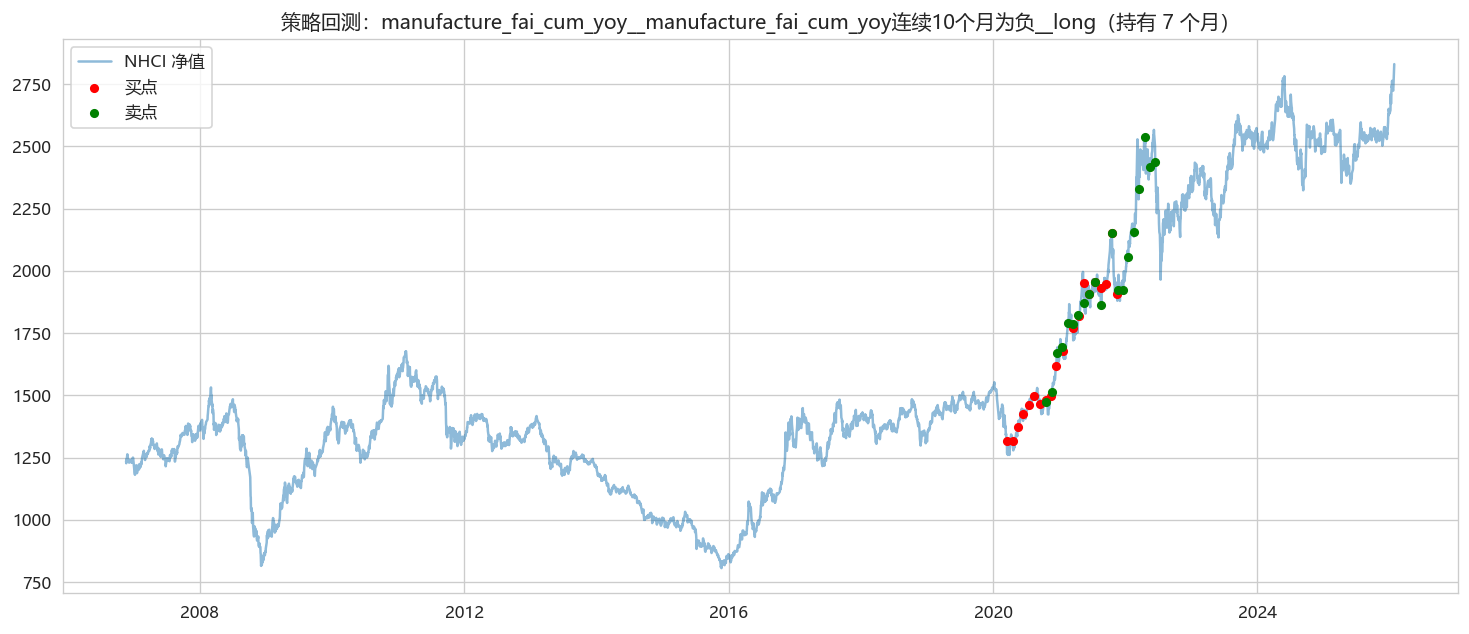

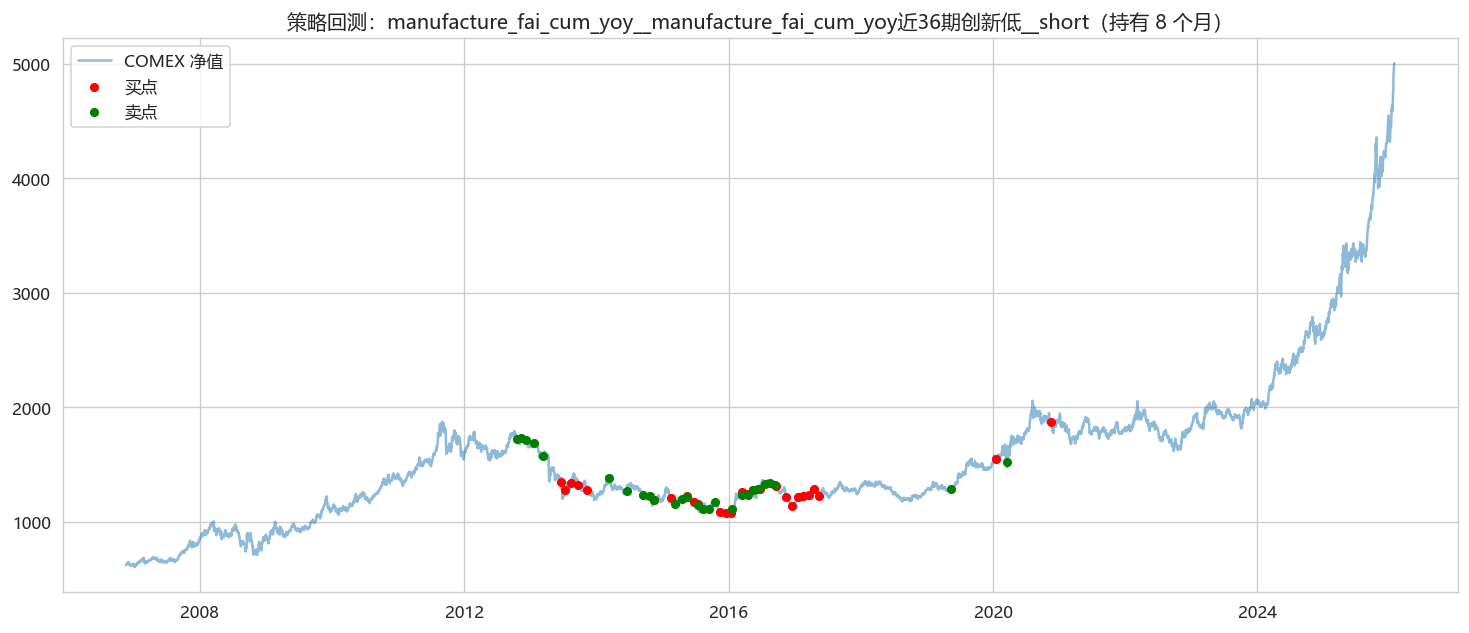

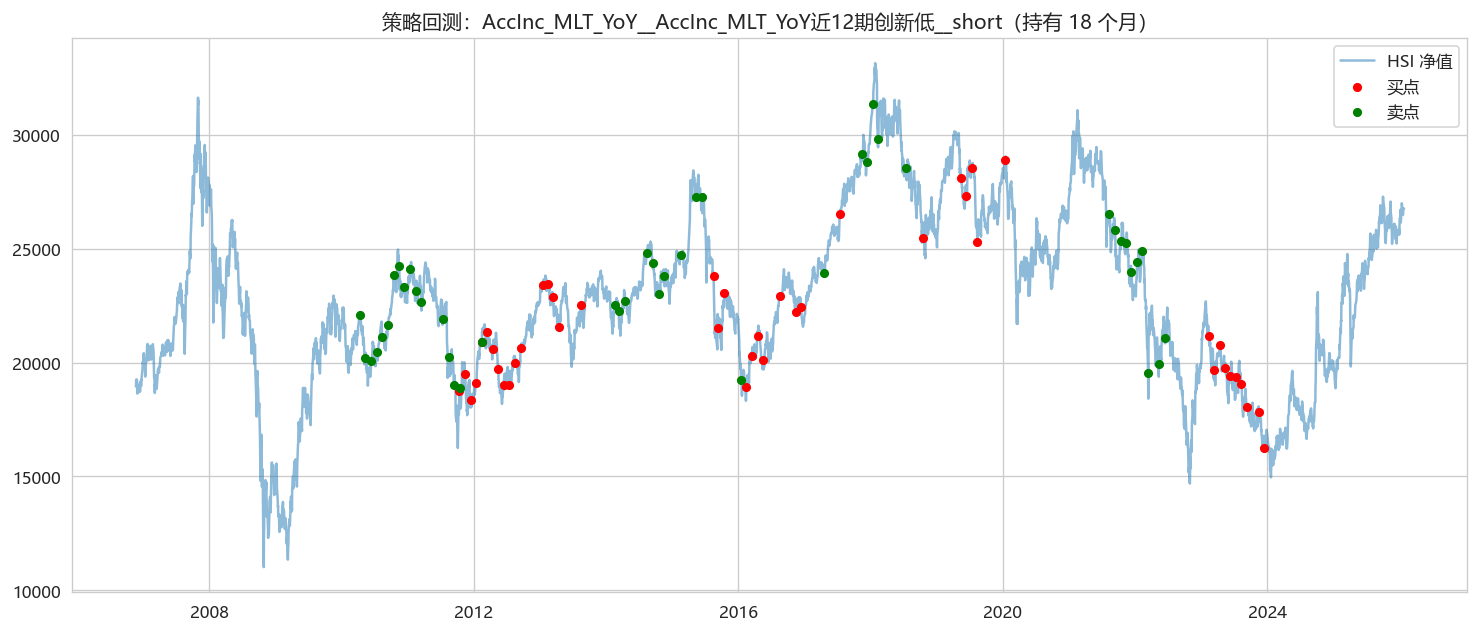

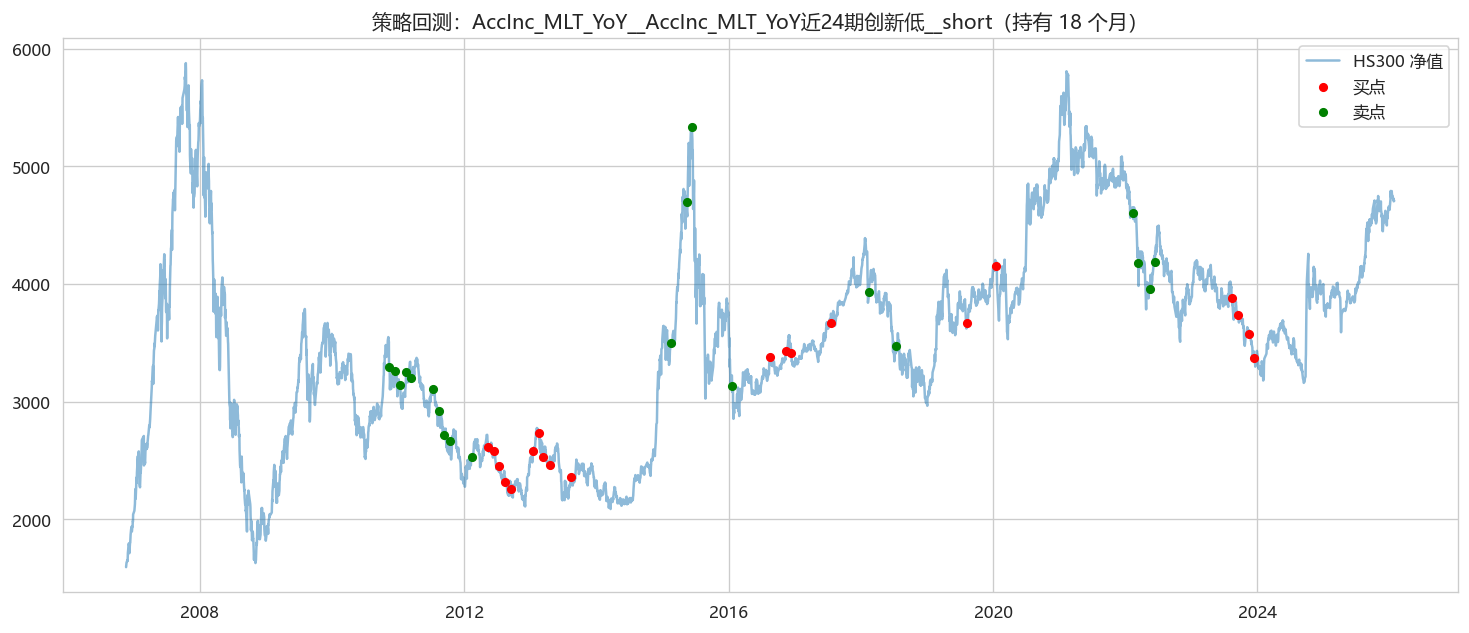

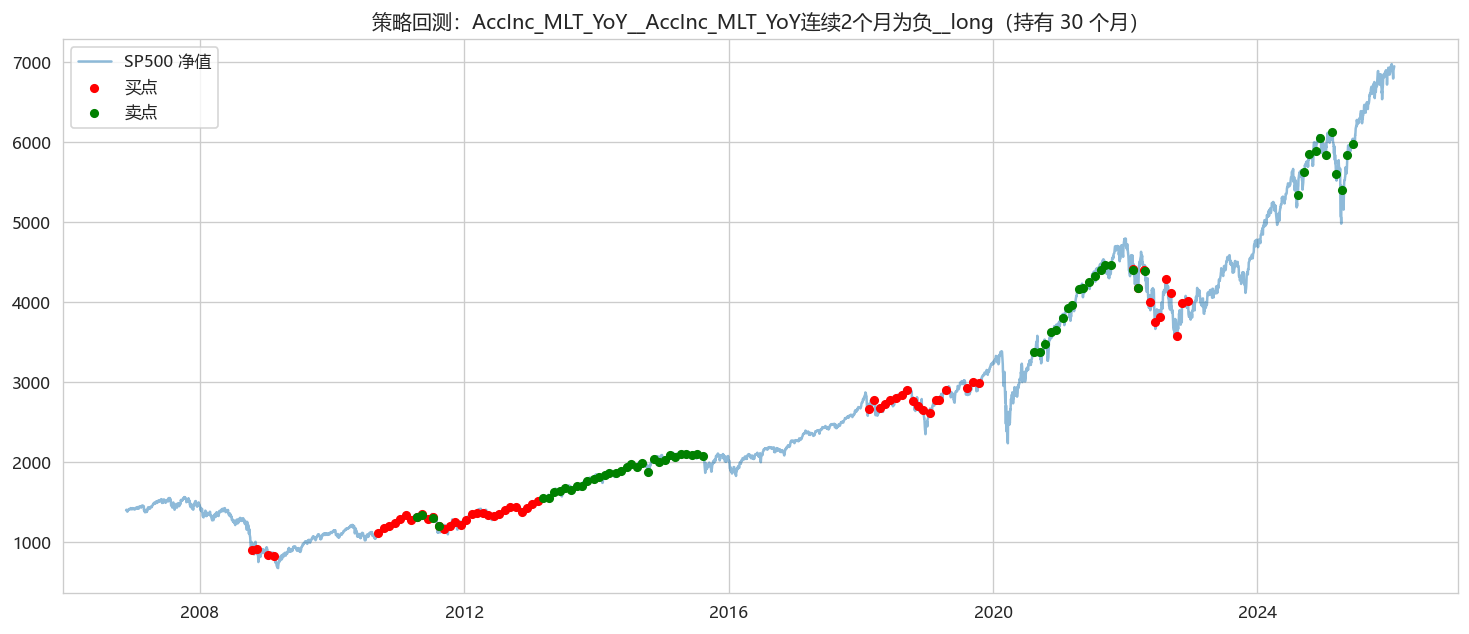

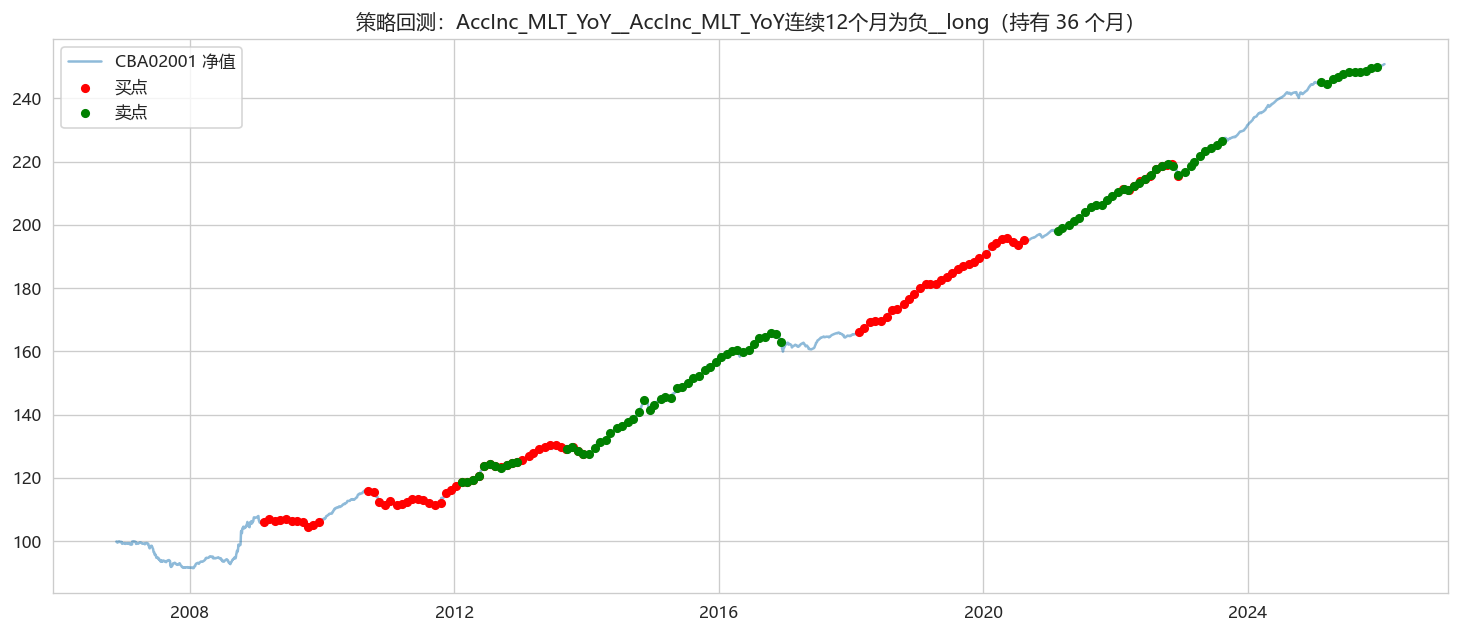

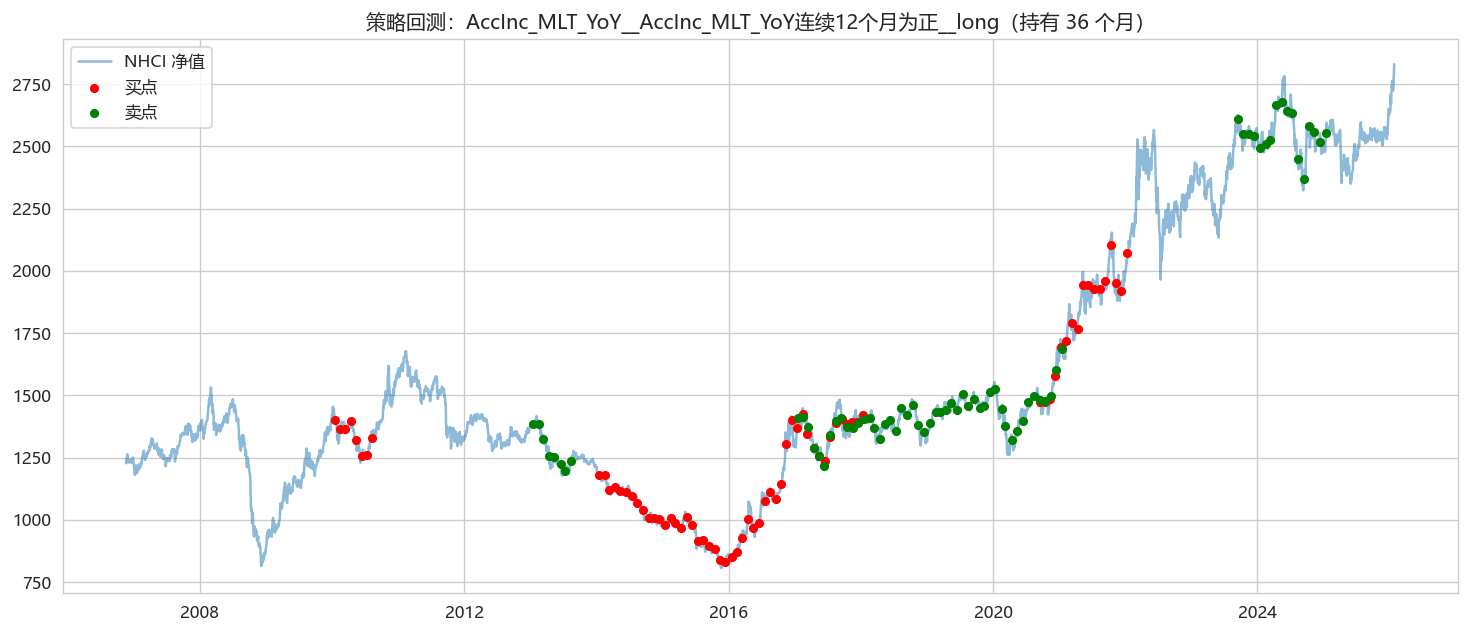

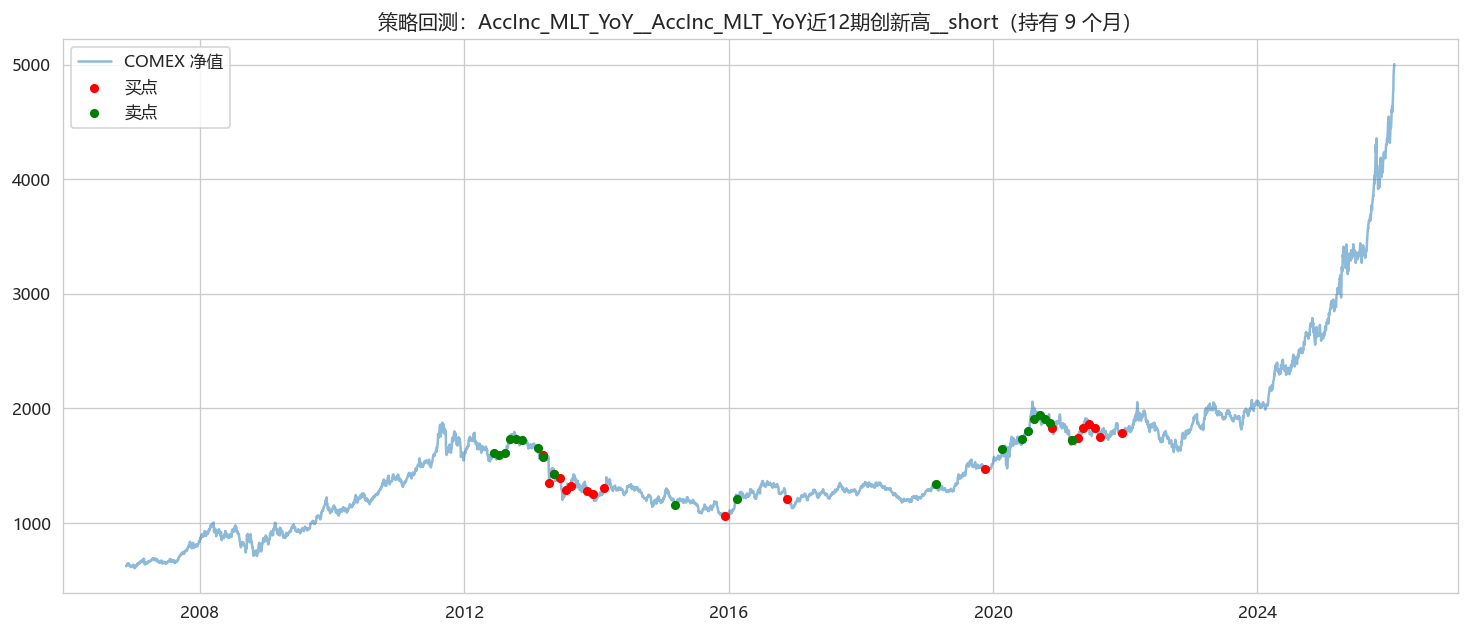

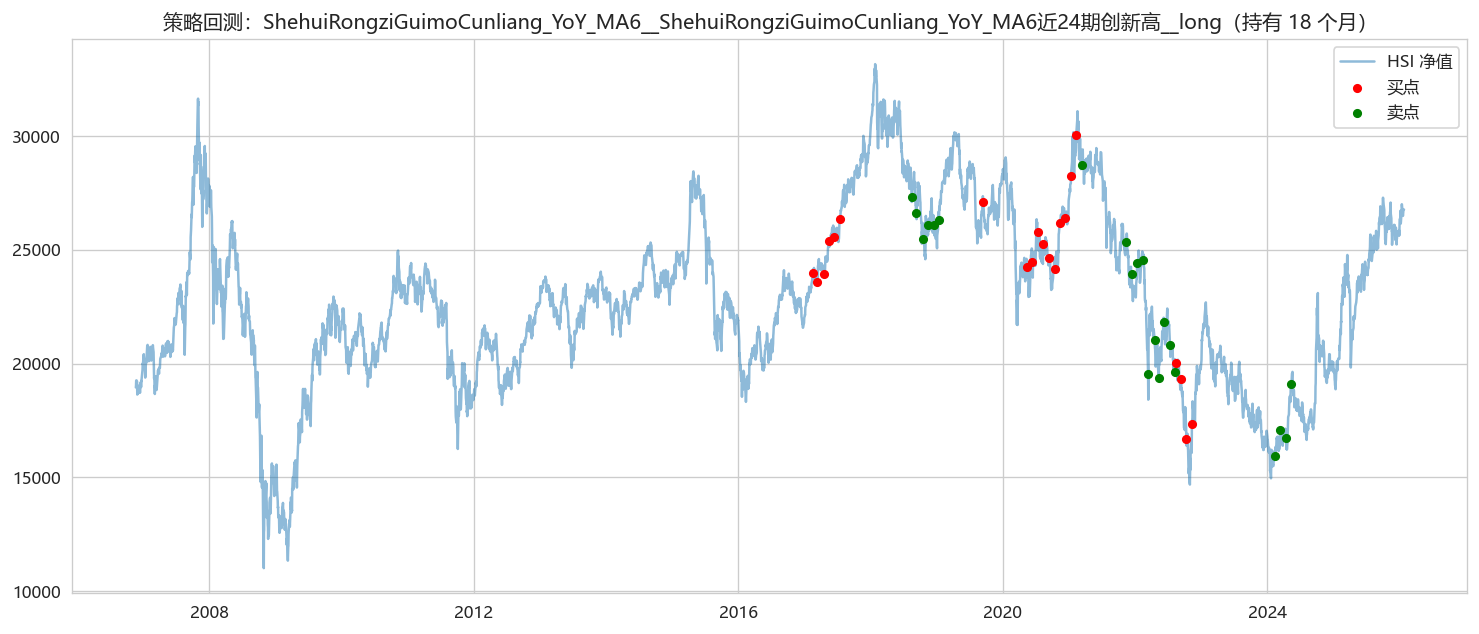

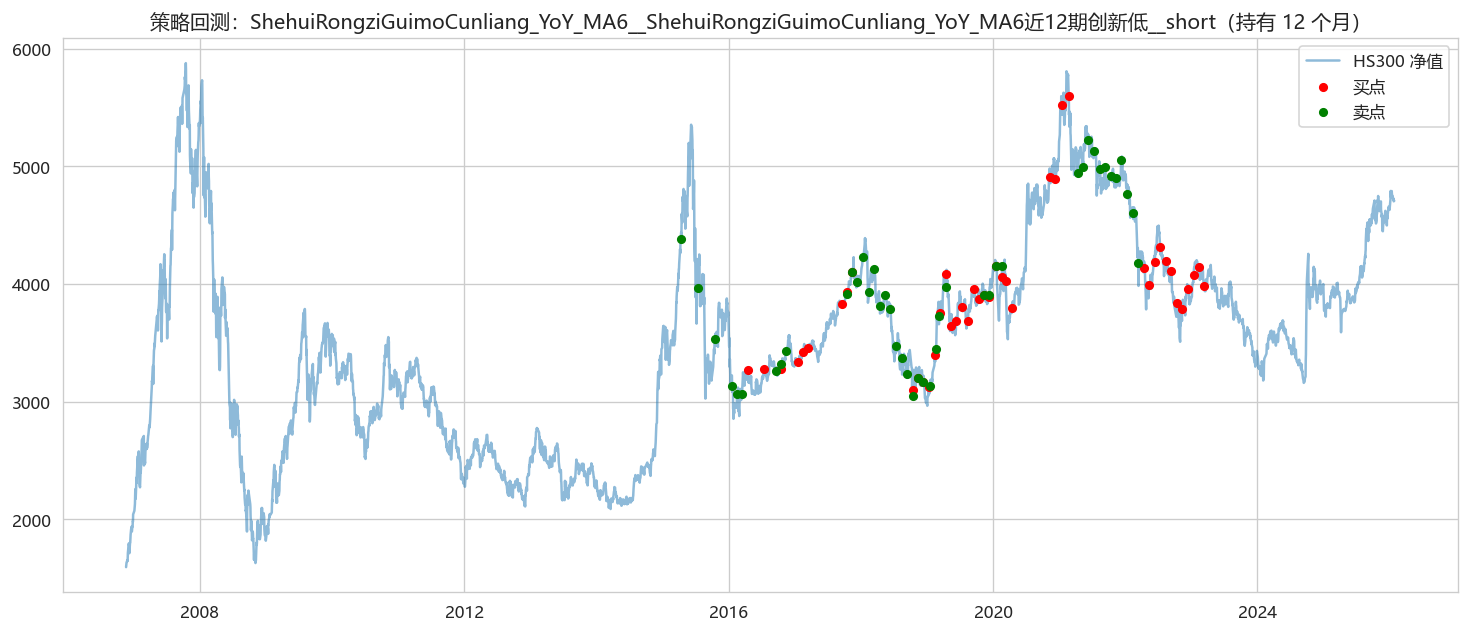

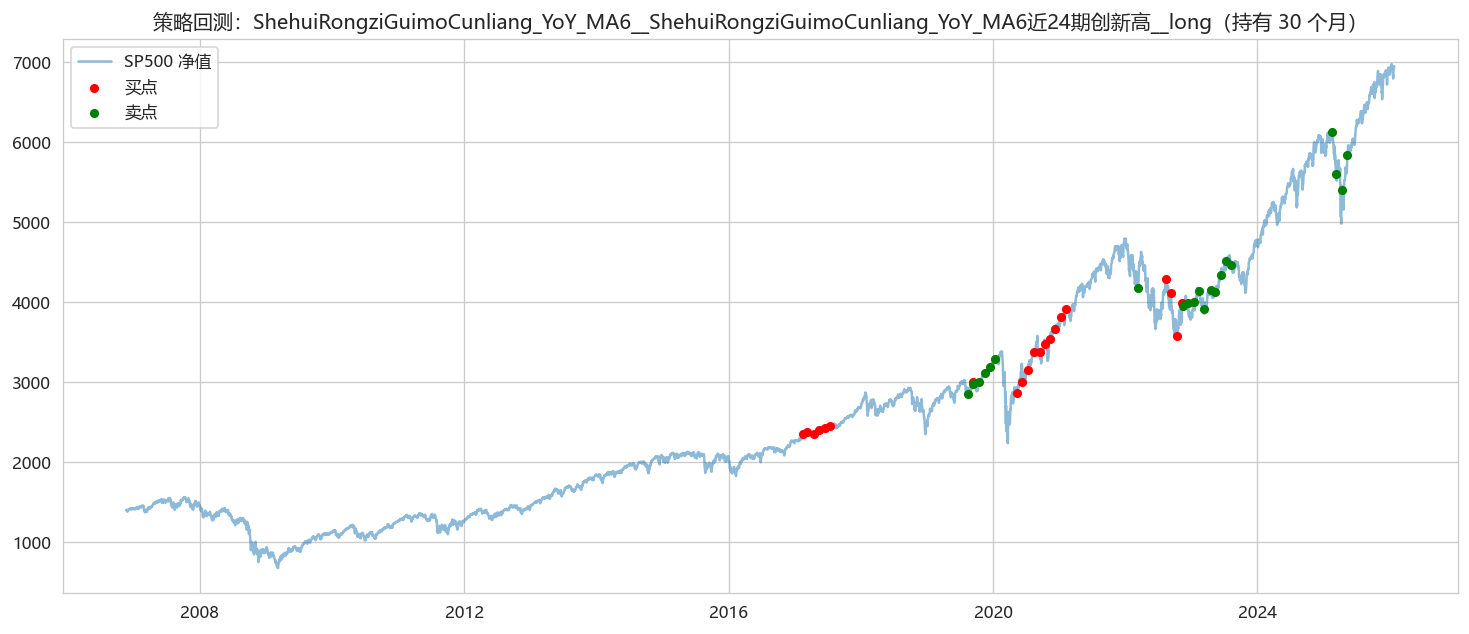

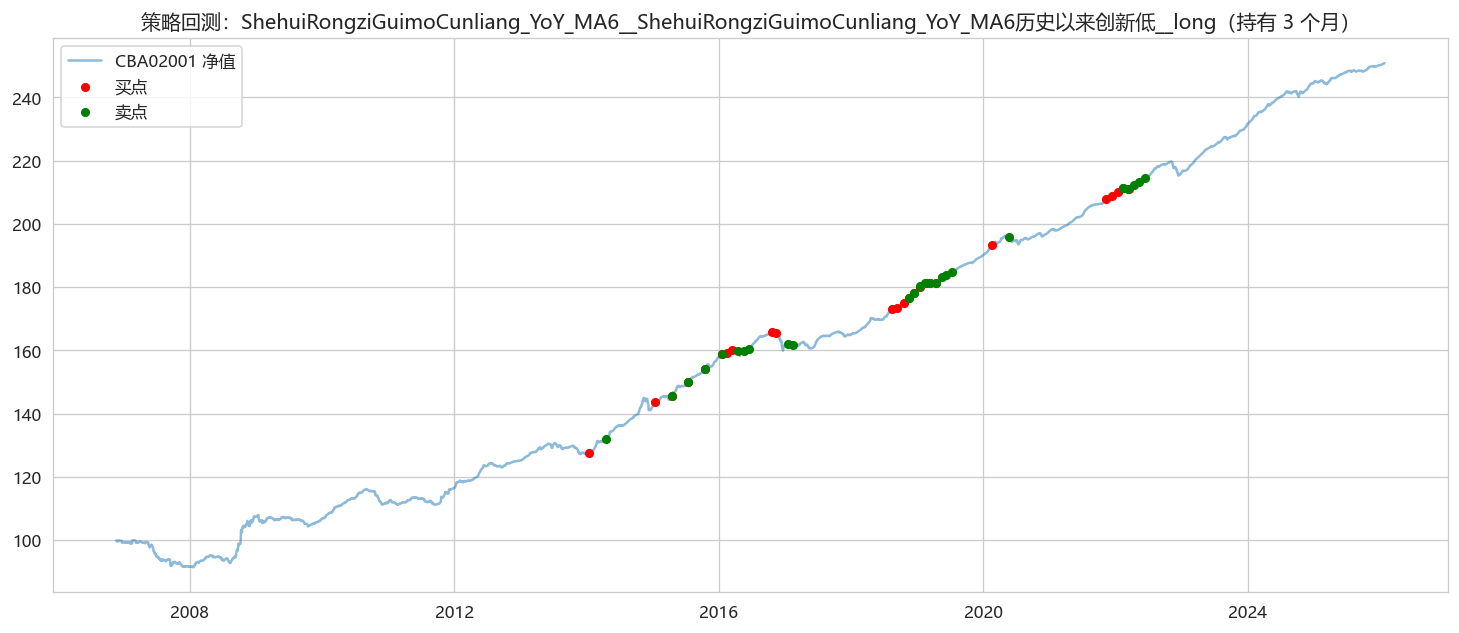

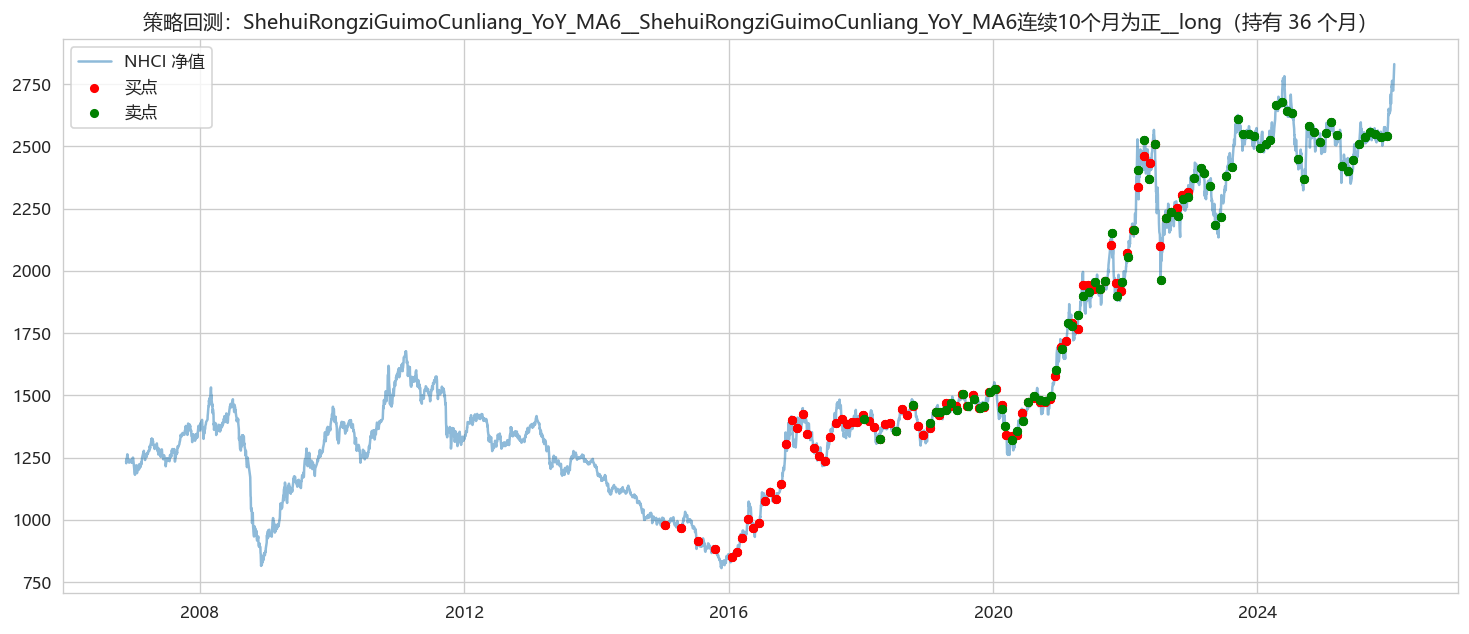

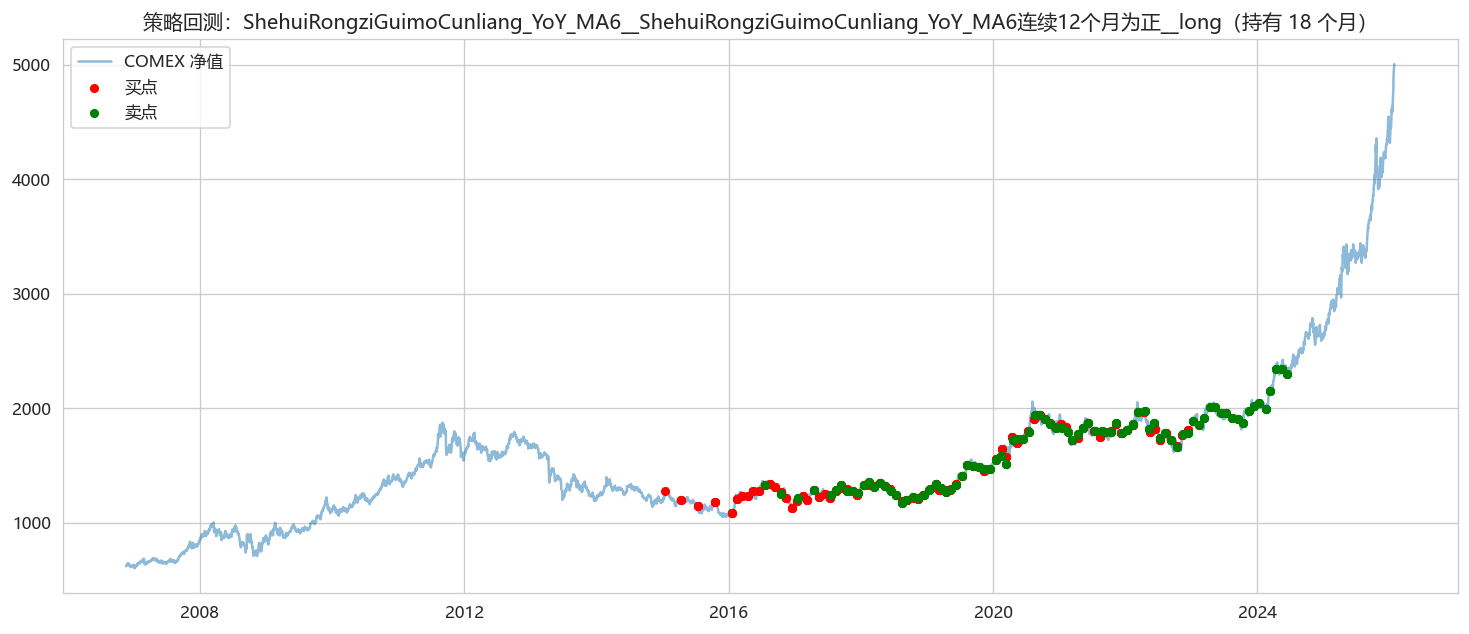

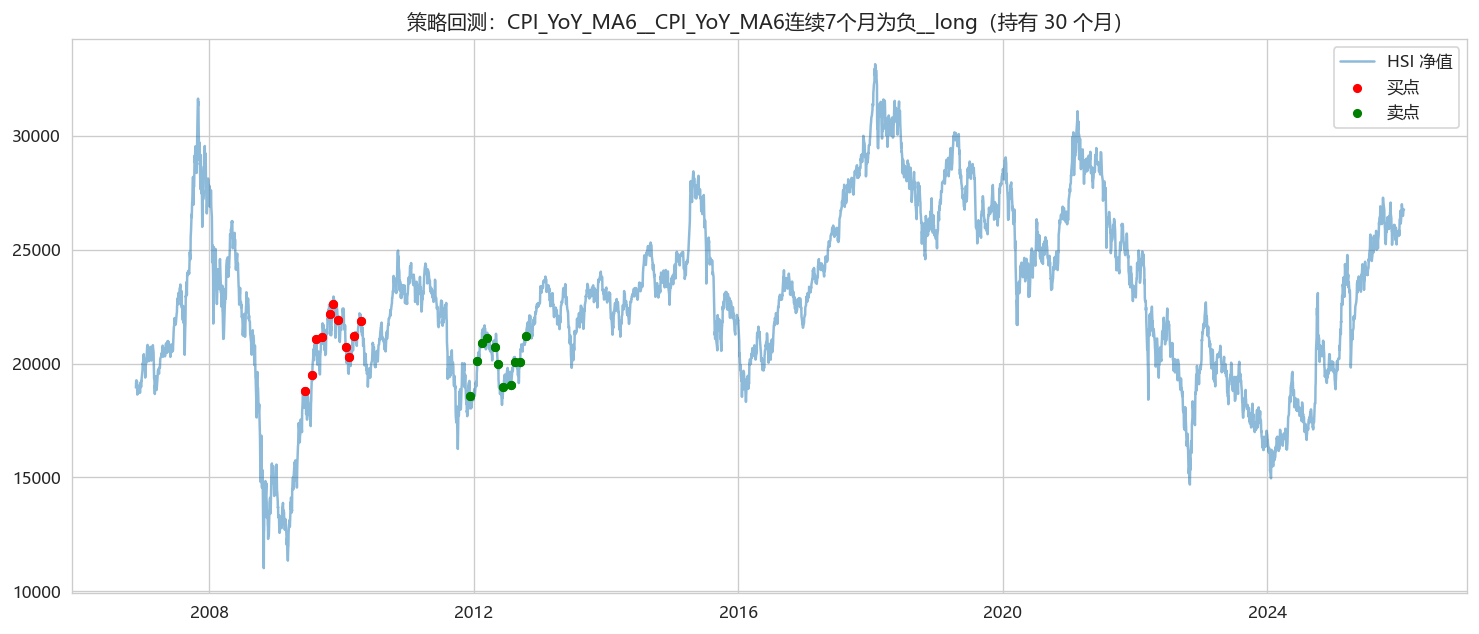

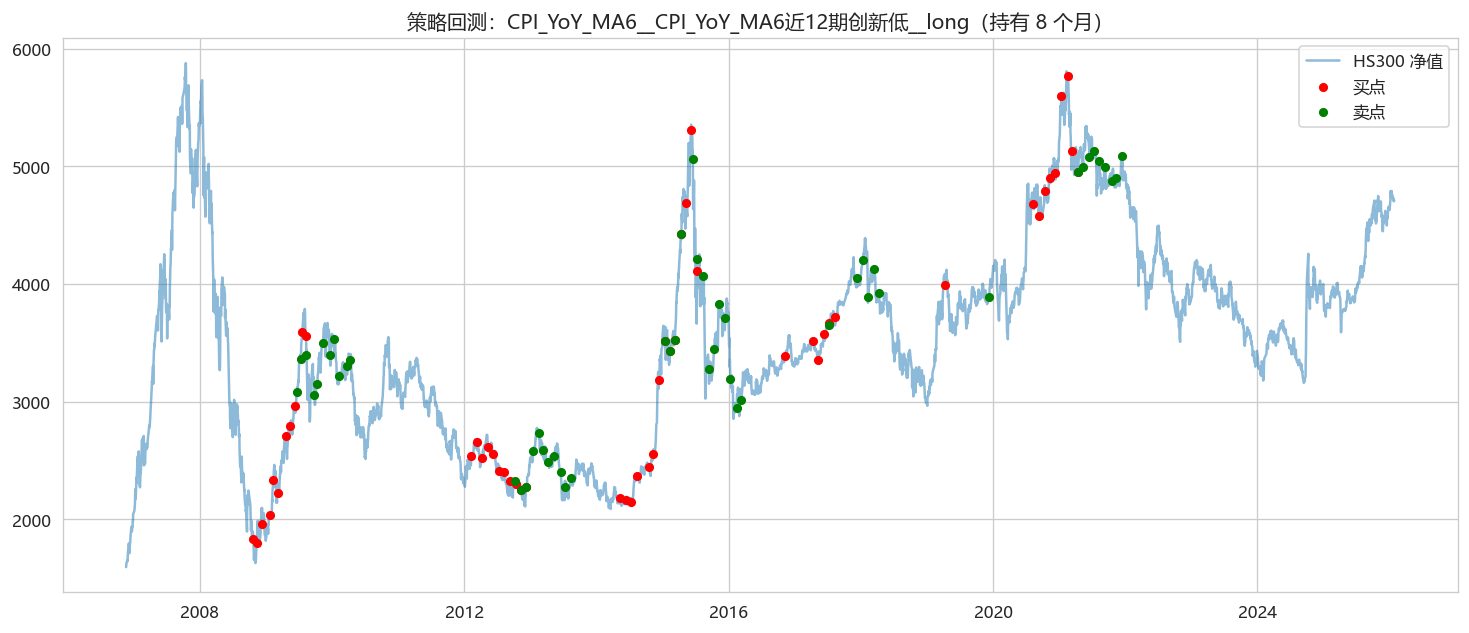

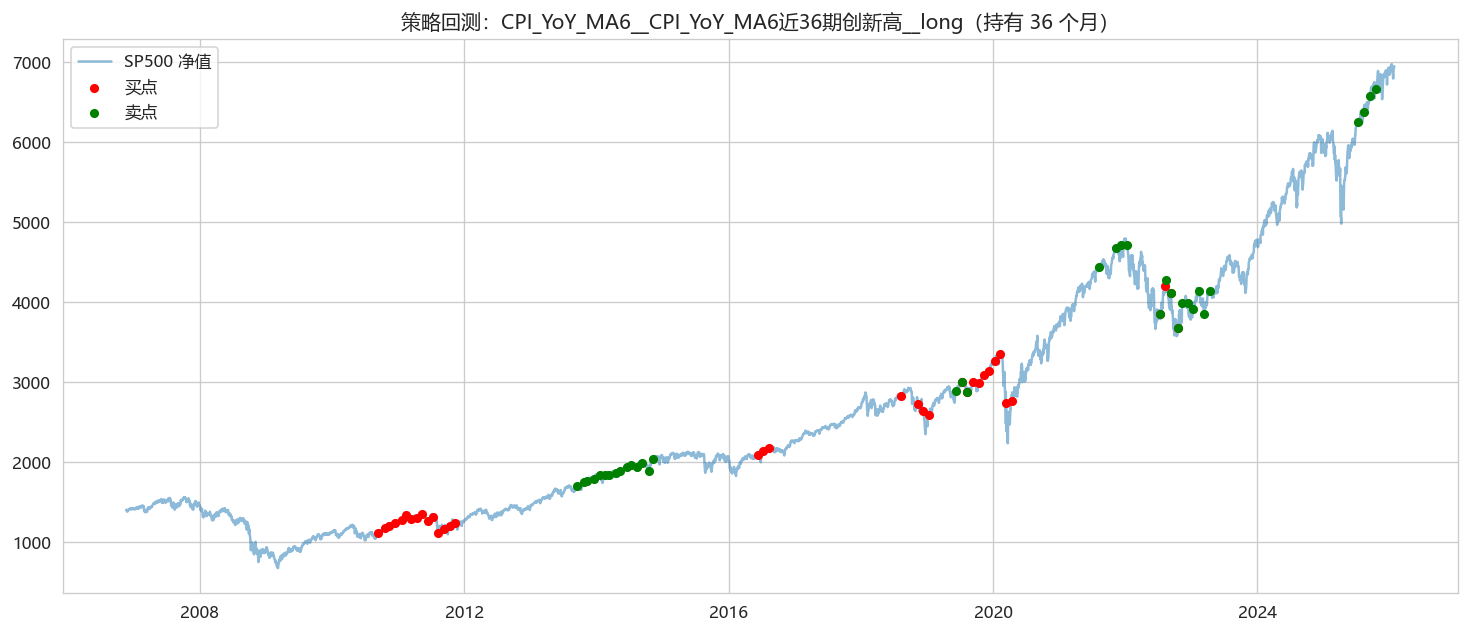

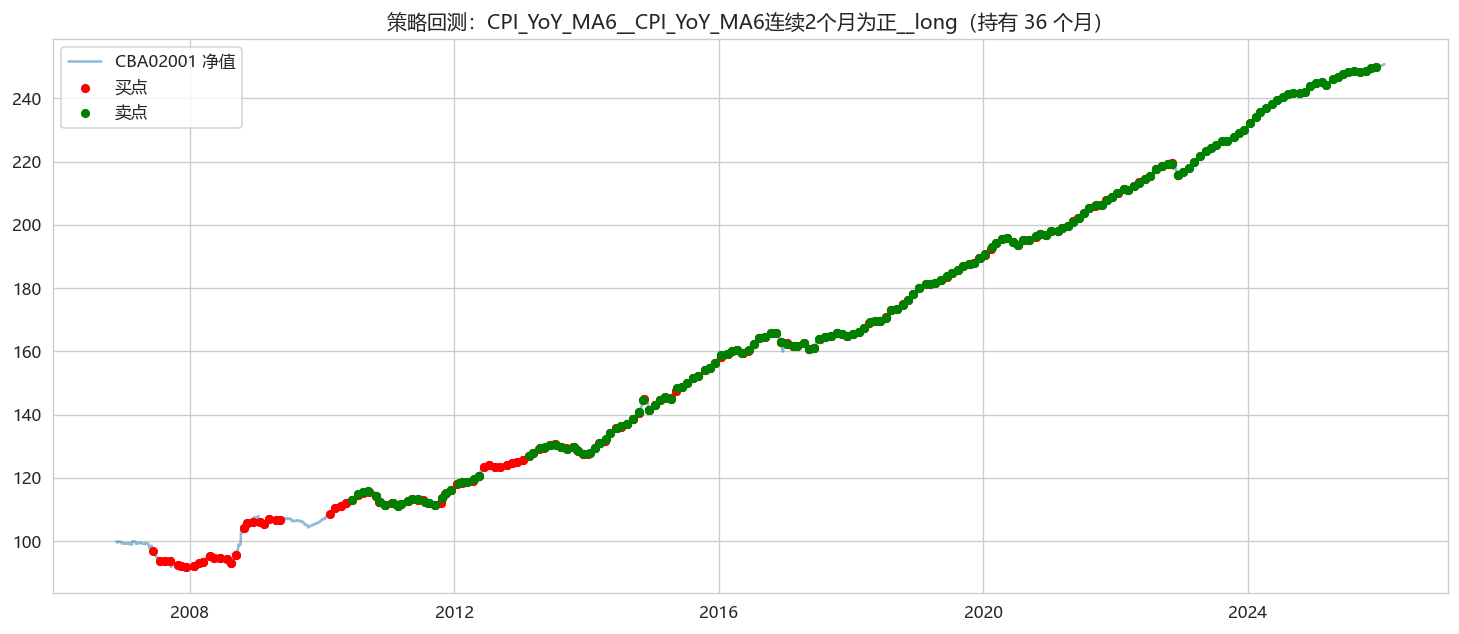

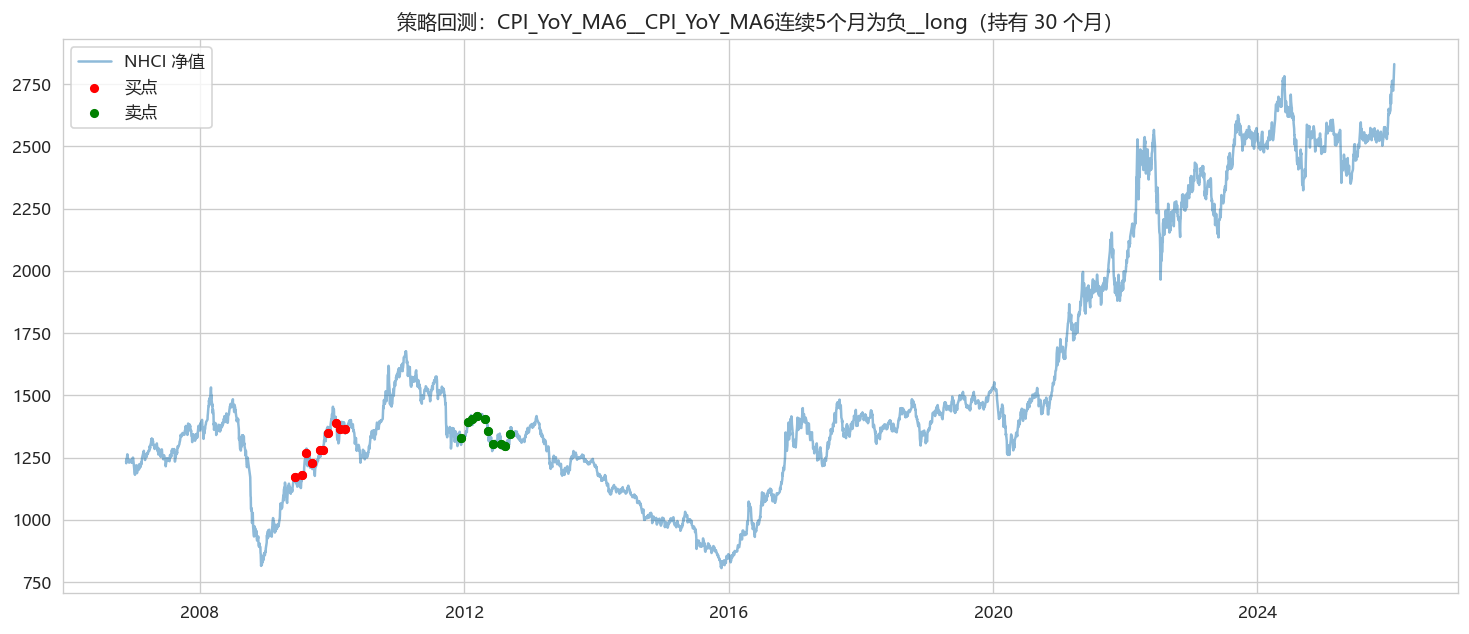

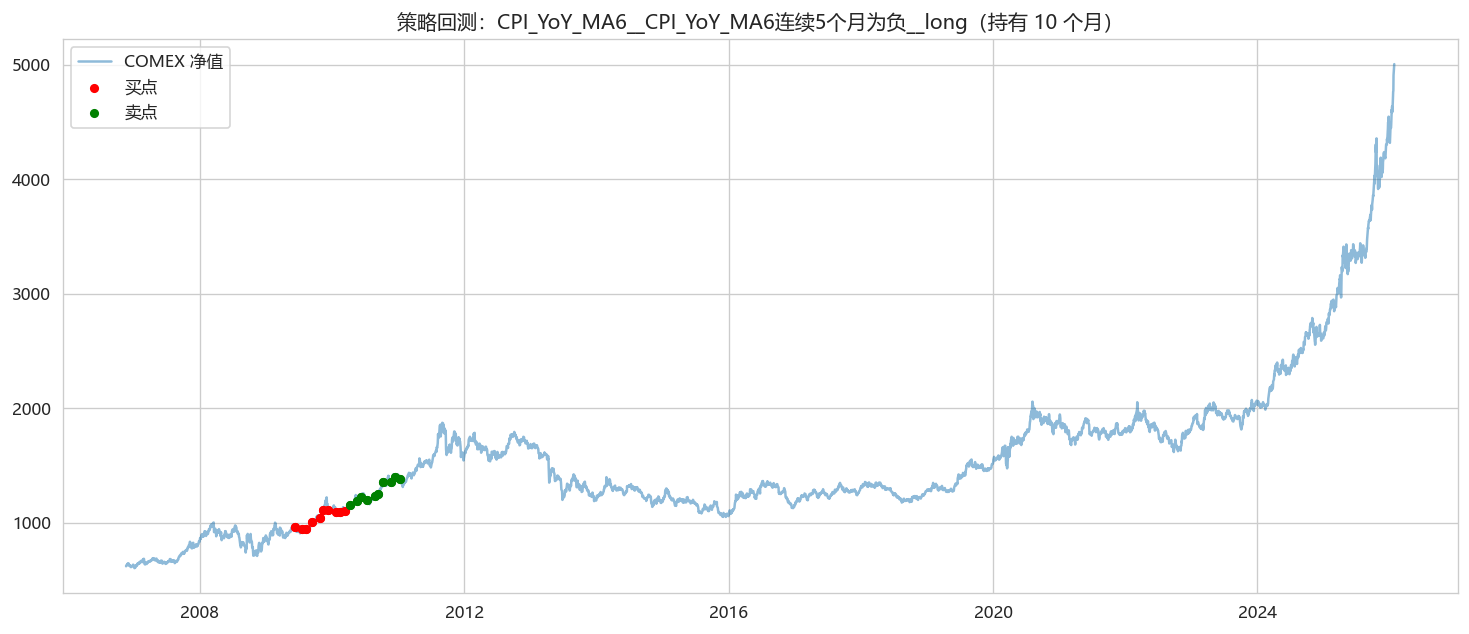

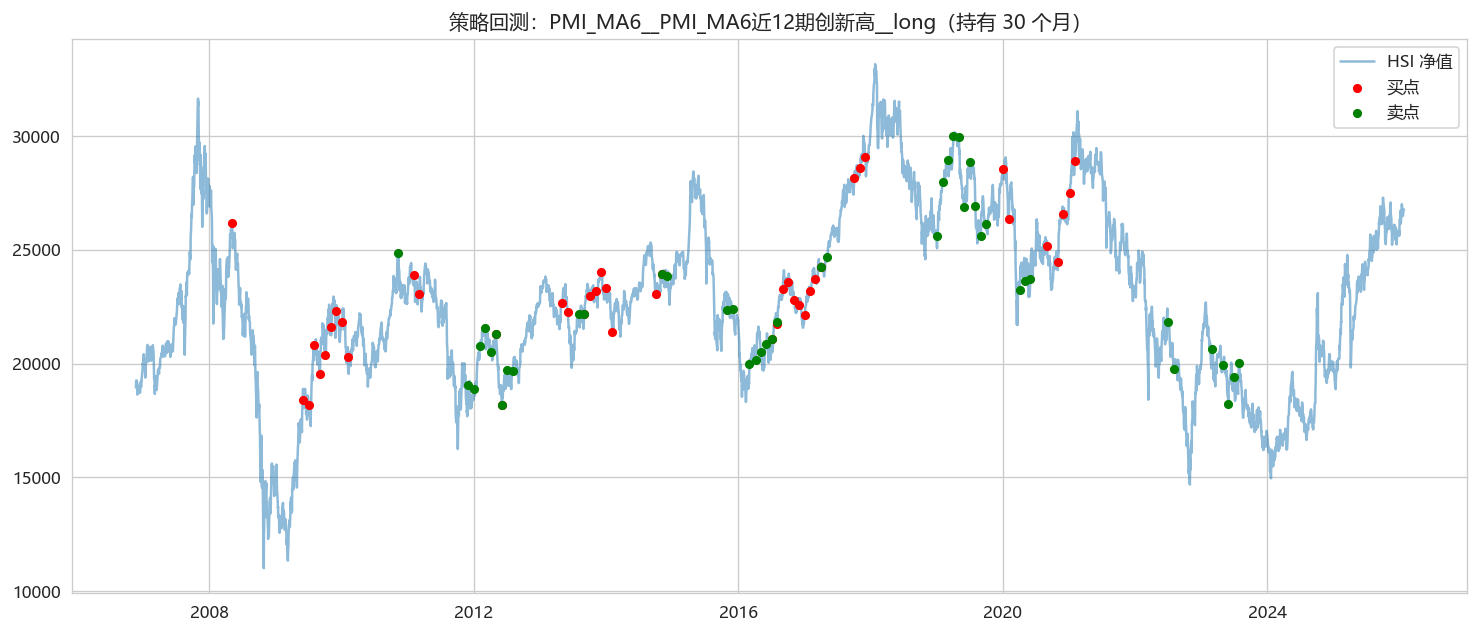

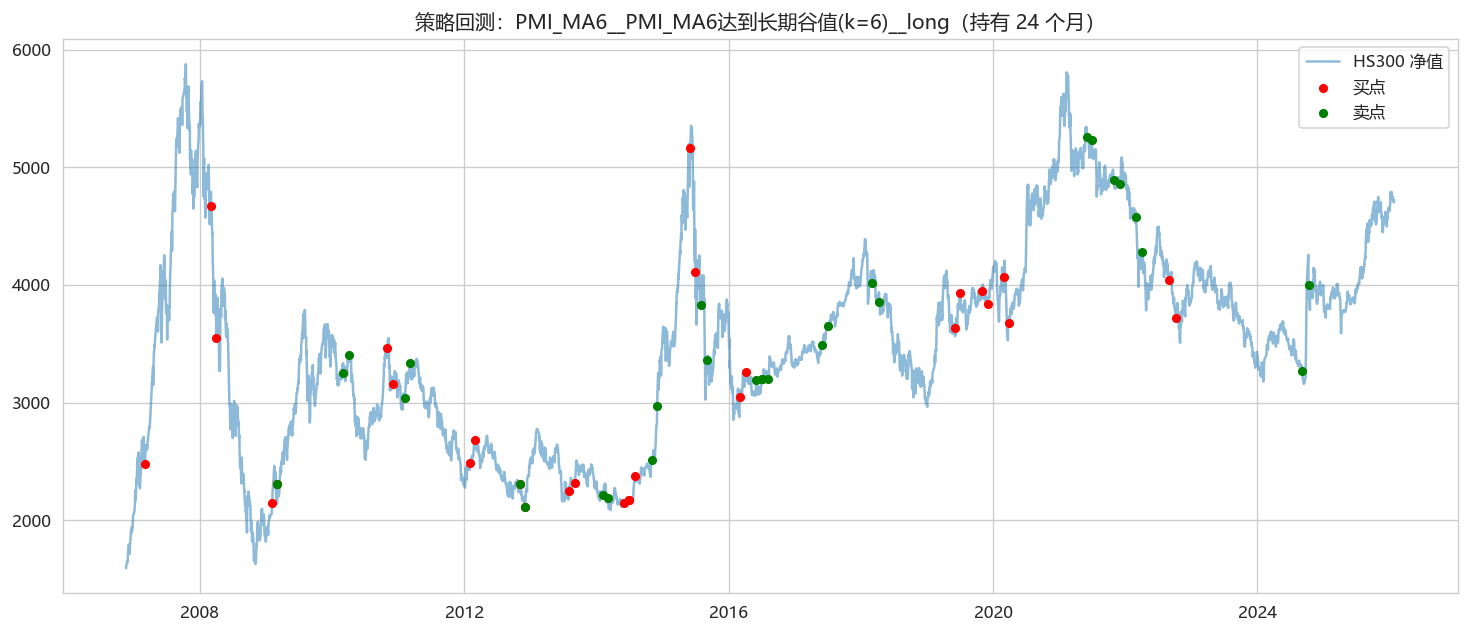

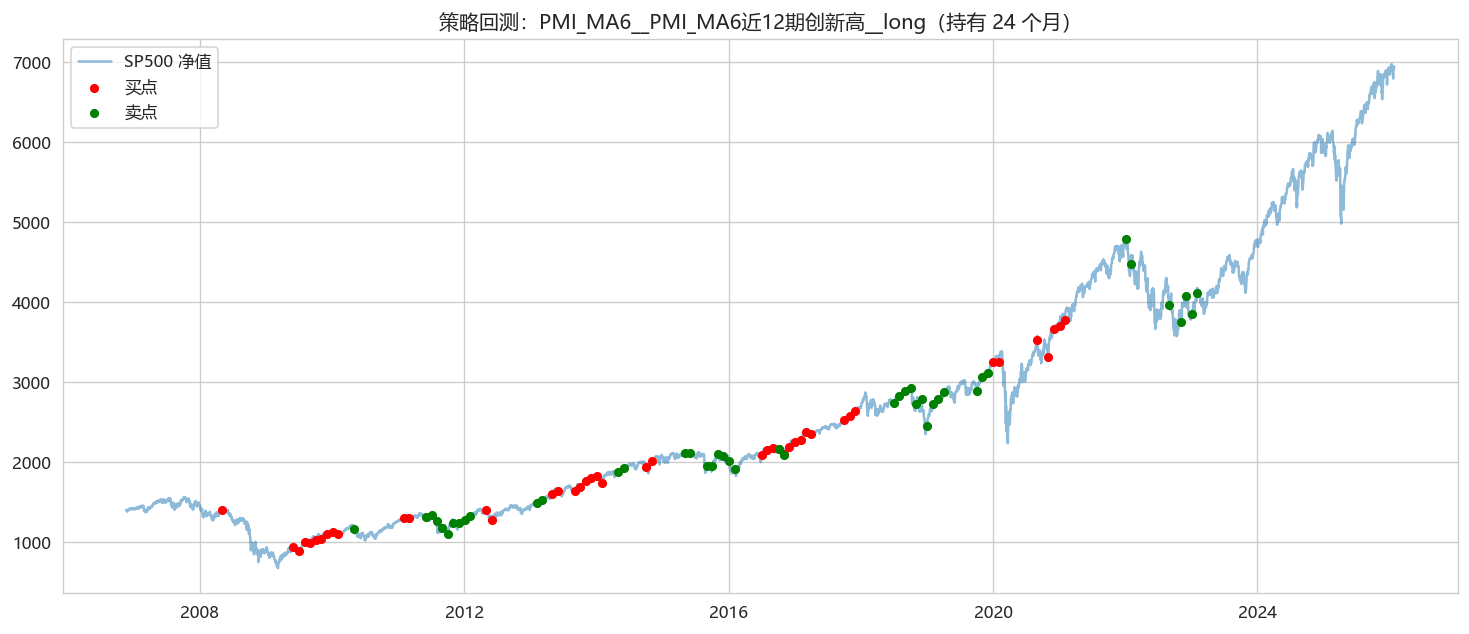

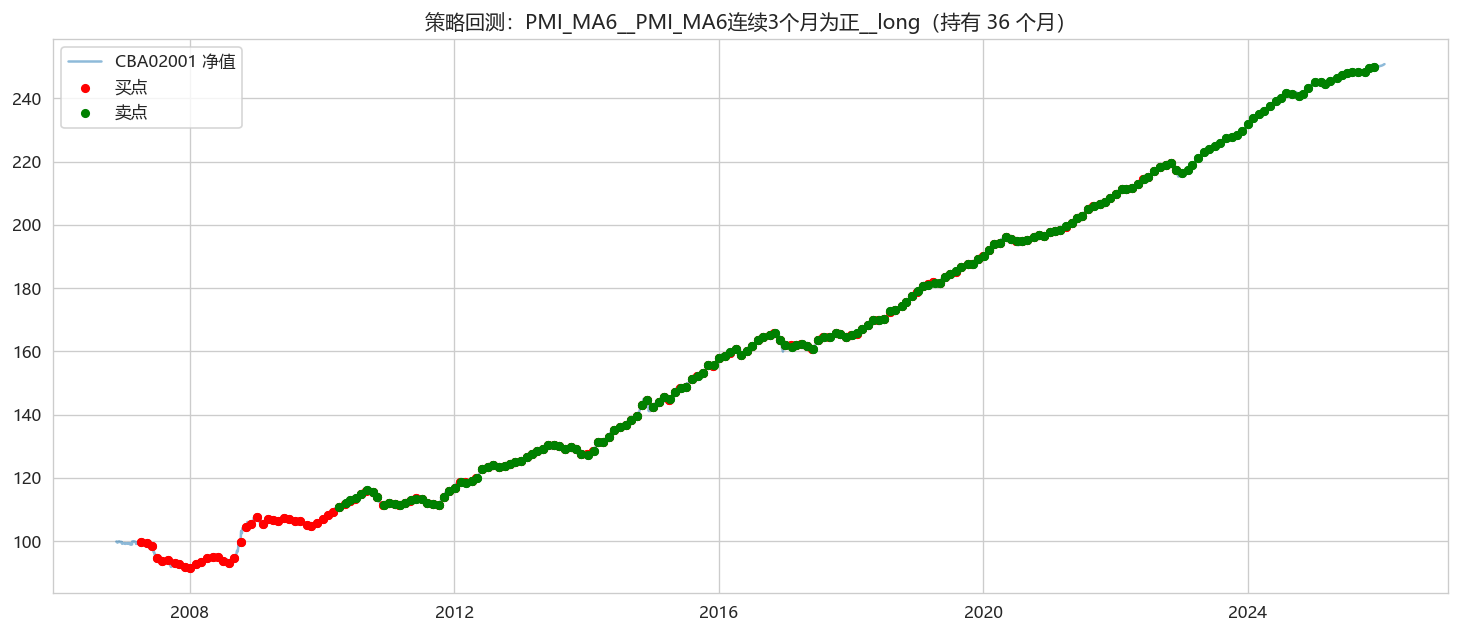

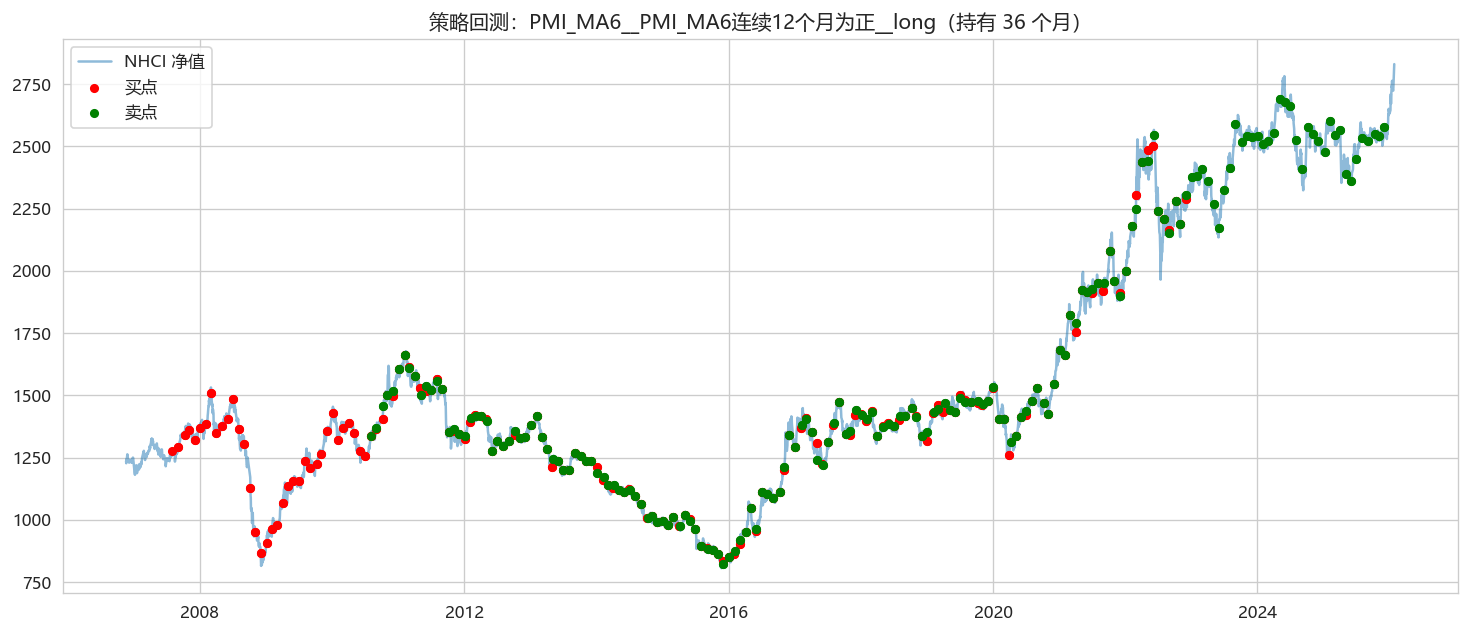

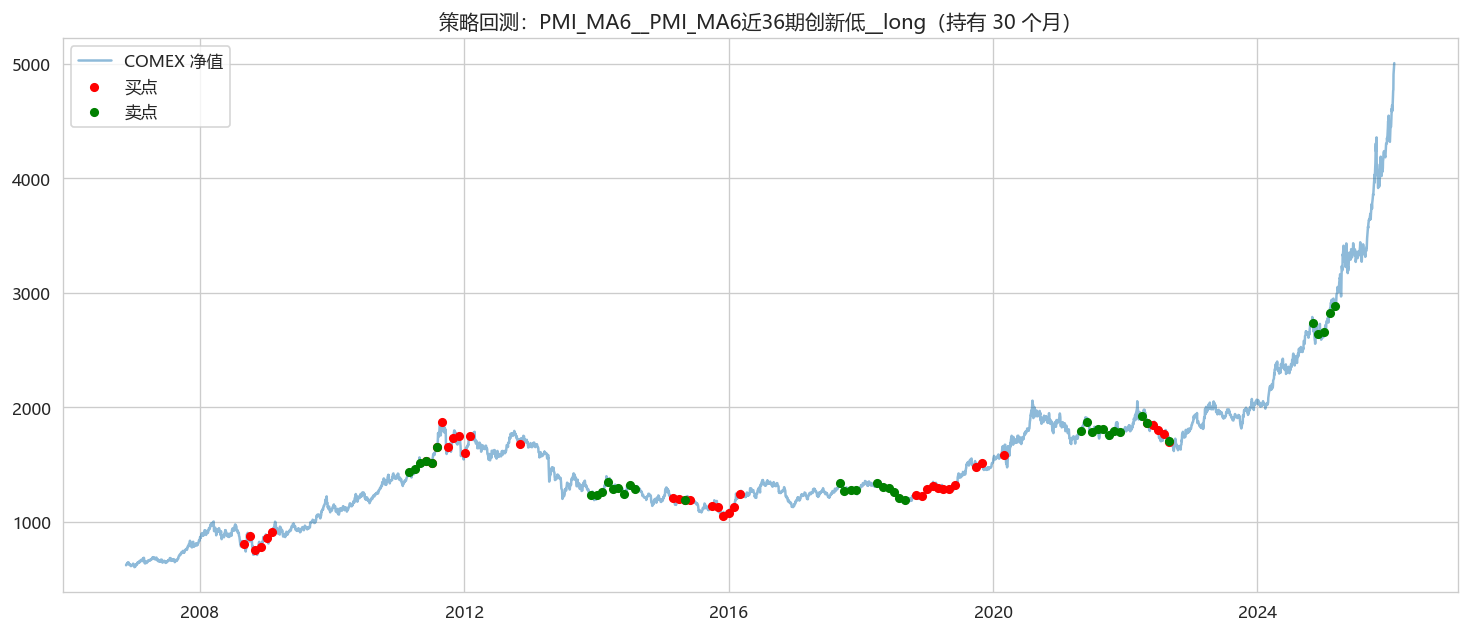


✅ 所有组合执行完毕！OOS trades 已写入：Final_Results_20260223_235650/Trades_Temp.xlsx
   同时导出：Final_Results_20260223_235650/events_all.xlsx, Final_Results_20260223_235650/trades_INS.xlsx, Final_Results_20260223_235650/trades_OOS.xlsx


In [18]:
# ==========================================
# Cell 27 (最终版): 主循环 + 稳健存储（INS 选参 + INS/OOS 交易明细）
# ==========================================
import os

# 配置
INTERVAL_SAVE = 5    # 每跑 5 个组合保存一次

final_events_list = []
final_trades_ins_list = []
final_trades_oos_list = []

combinations = list(itertools.product(macro_cols, asset_cols))
os.makedirs(f"Final_Results_{timestamp}", exist_ok=True)

for i, (target, asset) in enumerate(tqdm(combinations, desc="宏观量化回测进度")):
    try:
        save_dir = Path(f"Results_{timestamp}/{target} - {asset}")
        save_dir.mkdir(parents=True, exist_ok=True)

        best_row, tr_ins, tr_oos = run_single_backtest(target, asset, macro_df_all, asset_df_all, n=12, out_dir=save_dir)

        if best_row is not None and (not best_row.empty):
            final_events_list.append(best_row)
        if tr_ins is not None and (not tr_ins.empty):
            final_trades_ins_list.append(tr_ins)
        if tr_oos is not None and (not tr_oos.empty):
            final_trades_oos_list.append(tr_oos)

        # ✅ 2. 定期保存
        if (i + 1) % INTERVAL_SAVE == 0:
            if final_events_list:
                pd.concat(final_events_list, ignore_index=True).to_csv(
                    events_tmp, index=False, mode='a', header=not os.path.exists(events_tmp)
                )
            if final_trades_ins_list:
                pd.concat(final_trades_ins_list, ignore_index=True).to_csv(
                    trades_ins_tmp, index=False, mode='a', header=not os.path.exists(trades_ins_tmp)
                )
            if final_trades_oos_list:
                pd.concat(final_trades_oos_list, ignore_index=True).to_csv(
                    trades_oos_tmp, index=False, mode='a', header=not os.path.exists(trades_oos_tmp)
                )

            final_events_list = []
            final_trades_ins_list = []
            final_trades_oos_list = []

        plt.close('all')

    except Exception as e:
        print(f"\n❌ 错误：{target} - {asset} 失败：{str(e)}")

        # ✅ 3. 出错时也保存当前累积的数据，防止丢失
        if final_events_list:
            pd.concat(final_events_list, ignore_index=True).to_csv(
                f"Final_Results_{timestamp}/Events_Temp.xlsx",
                index=False, mode='a',
                header=not os.path.exists(f"Final_Results_{timestamp}/Events_Temp.xlsx")
            )
            final_events_list = []
        if final_trades_ins_list:
            pd.concat(final_trades_ins_list, ignore_index=True).to_csv(
                f"Final_Results_{timestamp}/Trades_INS_Temp.xlsx",
                index=False, mode='a',
                header=not os.path.exists(f"Final_Results_{timestamp}/Trades_INS_Temp.xlsx")
            )
            final_trades_ins_list = []
        if final_trades_oos_list:
            pd.concat(final_trades_oos_list, ignore_index=True).to_csv(
                f"Final_Results_{timestamp}/Trades_Temp.xlsx",
                index=False, mode='a',
                header=not os.path.exists(f"Final_Results_{timestamp}/Trades_Temp.xlsx")
            )
            final_trades_oos_list = []
        continue

# 4. 最后保存剩余数据
if final_events_list:
    pd.concat(final_events_list, ignore_index=True).to_csv(
        events_tmp, index=False, mode='a', header=not os.path.exists(events_tmp)
    )
if final_trades_ins_list:
    pd.concat(final_trades_ins_list, ignore_index=True).to_csv(
        trades_ins_tmp, index=False, mode='a', header=not os.path.exists(trades_ins_tmp)
    )
if final_trades_oos_list:
    pd.concat(final_trades_oos_list, ignore_index=True).to_csv(
        trades_oos_tmp, index=False, mode='a', header=not os.path.exists(trades_oos_tmp)
    )

# 5. ✅ 额外导出 Excel（便于人工检查；第二份 notebook 继续读 Trades_Temp.xlsx 即可）
try:
    events_path = f"{final_res_dir}/events_all.xlsx"
    trades_ins_path = f"{final_res_dir}/trades_INS.xlsx"
    trades_oos_path = f"{final_res_dir}/trades_OOS.xlsx"

    if os.path.exists(events_tmp):
        pd.read_csv(events_tmp).to_excel(events_path, index=False)
    if os.path.exists(trades_ins_tmp):
        pd.read_csv(trades_ins_tmp).to_excel(trades_ins_path, index=False)
    if os.path.exists(trades_oos_tmp):
        pd.read_csv(trades_oos_tmp).to_excel(trades_oos_path, index=False)

    print(f"\n✅ 所有组合执行完毕！OOS trades 已写入：{trades_oos_tmp}")
    print(f"   同时导出：{events_path}, {trades_ins_path}, {trades_oos_path}")
except Exception as e:
    print(f"\n⚠️ Excel 导出失败（不影响 CSV）：{str(e)}")
